# V&V maternal outcomes and intervention coverage

## Setup

In [1]:
import pandas as pd, numpy as np, os
from vivarium.artifact import Artifact
import db_queries
from get_draws.api import get_draws
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

In [2]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) 

In [3]:
from vivarium_gates_mncnh.constants.paths import MODEL_RESULTS_DIR

base_results_dir = Path("/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/results/") / MODEL_RESULTS_DIR


In [4]:
locations = [p.stem.title() for p in base_results_dir.iterdir() if p.is_dir()]
locations

['Ethiopia', 'Pakistan', 'Nigeria']

In [5]:
results_dirs = {}
assert set([p.stem for p in base_results_dir.iterdir()]) == set([l.lower() for l in locations])
for location in locations:
    location_dir = base_results_dir / location.lower()
    timestamps = sorted(location_dir.iterdir())
    last_timestamp = timestamps[-1]
    if len(timestamps) > 1:
        print(f'Multiple timestamps: {timestamps}, using {last_timestamp}')
    results_dirs[location] = location_dir / last_timestamp / 'results'

results_dirs

{'Ethiopia': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/results/model39.2/ethiopia/2026_08_21_11_56_04/results'),
 'Pakistan': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/results/model39.2/pakistan/2026_08_21_11_57_09/results'),
 'Nigeria': PosixPath('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/results/model39.2/nigeria/2026_08_21_11_57_09/results')}

In [6]:
location_ids = db_queries.get_ids('location')
location_ids = location_ids.loc[location_ids.location_name.str.lower().isin([x.lower() for x in results_dirs.keys()])]
location_ids

,location_id,location_name,location_type,location_description
139,165,Pakistan,admin0,admin0
150,179,Ethiopia,admin0,admin0
183,214,Nigeria,admin0,admin0


In [7]:
def load_yaml_file(path):
    with open(path) as stream:
        return yaml.safe_load(stream)

In [8]:
artifact_paths = {
    location: load_yaml_file(result_dir.parent / 'model_specification.yaml')['configuration']['input_data']['artifact_path']
    for location, result_dir
    in results_dirs.items()
}
artifact_paths

{'Ethiopia': '/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.1/ethiopia.hdf',
 'Pakistan': '/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.1/pakistan.hdf',
 'Nigeria': '/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model39.1/nigeria.hdf'}

In [9]:
def read_results(result_file_name, baseline_only=True):
    all_locations_results = []
    for location, result_dir in results_dirs.items():
        if baseline_only:
           filters = [('scenario', '==', 'baseline')]
           location_results = pd.read_parquet(result_dir / f'{result_file_name}', filters=filters).drop(columns=['measure','entity','sub_entity','entity_type'])
        else:
            location_results = pd.read_parquet(result_dir / f'{result_file_name}').drop(columns=['measure','entity','sub_entity','entity_type'])
        location_results['location'] = location
        #if 'scenario' not in location_results.columns:
        #    location_results['scenario'] = 'baseline'
        #if baseline_only:
        #    location_results = location_results.loc[location_results.scenario == 'baseline']

        # Aggregate over random seeds (if necessary)
        # TODO: Could use vivarium_helpers marginalize method here
        if 'random_seed' in location_results.columns:
            location_results = location_results.groupby([
                c for c in location_results.columns if c != 'random_seed' and c != 'value'
            ]).sum().reset_index().drop(columns='random_seed')

        all_locations_results.append(location_results)
    return pd.concat(all_locations_results, ignore_index=True)

In [10]:
causes = [
    'maternal_sepsis_and_other_maternal_infections',
    'maternal_hemorrhage',
    'maternal_obstructed_labor_and_uterine_rupture',
    'postpartum_depression',
]

# Mapping for causes whose result files have been split
hemorrhage_sub_causes = ['antepartum_hemorrhage', 'postpartum_hemorrhage']

In [11]:
def combine_count_results_by_cause(measure, results_file_suffix=None, baseline_only=True, supercause_only=False):
    if results_file_suffix is None:
        results_file_suffix = measure

    all_causes_results = []

    for cause in causes:
        # Hemorrhage results are split into antepartum and postpartum files
        if cause == 'maternal_hemorrhage':
            sub_cause_results = []
            for sub_cause in hemorrhage_sub_causes:
                sub_result = read_results(f'{sub_cause}_{results_file_suffix}', baseline_only=baseline_only)
                if baseline_only:
                    sub_result = sub_result.drop(columns=['scenario'], errors='ignore')
                sub_result['cause'] = sub_cause
                sub_result['measure'] = measure
                sub_cause_results.append(sub_result)
            cause_results = pd.concat(sub_cause_results, ignore_index=True)
            # Sum antepartum + postpartum counts together
            group_cols = [c for c in cause_results.columns if c != 'value']
            cause_results = cause_results.groupby(group_cols, observed=True).sum().reset_index()
            if baseline_only:
                cause_results = cause_results.drop(columns=['scenario'], errors='ignore')
            cause_results['cause'] = cause
            cause_results['measure'] = measure
            all_causes_results.append(cause_results)
            if not supercause_only:
                all_causes_results.append(pd.concat(sub_cause_results, ignore_index=True))
        else:
            cause_results = read_results(f'{cause}_{results_file_suffix}', baseline_only=baseline_only)
            if baseline_only:
                cause_results = cause_results.drop(columns=['scenario'], errors='ignore')
            cause_results['cause'] = cause
            cause_results['measure'] = measure
            all_causes_results.append(cause_results)

    return pd.concat(all_causes_results, ignore_index=True)

## Verify burden

In [12]:
incidence = combine_count_results_by_cause('incidence', 'counts', supercause_only=False)

incidence

,age_group,azithromycin_availability,delivery_facility_type,misoprostol_availability,pregnancy_outcome,input_draw,location,value,cause,measure
0,10_to_14,False,home,False,stillbirth,22,Ethiopia,12.0,maternal_sepsis_and_other_maternal_infections,incidence
1,10_to_14,False,home,False,stillbirth,60,Ethiopia,21.0,maternal_sepsis_and_other_maternal_infections,incidence
2,10_to_14,False,home,False,stillbirth,71,Ethiopia,9.0,maternal_sepsis_and_other_maternal_infections,incidence
3,10_to_14,False,home,False,stillbirth,79,Ethiopia,17.0,maternal_sepsis_and_other_maternal_infections,incidence
4,10_to_14,False,home,False,stillbirth,115,Ethiopia,12.0,maternal_sepsis_and_other_maternal_infections,incidence
...,...,...,...,...,...,...,...,...,...,...
241915,95_plus,True,none,True,full_term,118,Nigeria,0.0,postpartum_depression,incidence
241916,95_plus,True,none,True,full_term,146,Nigeria,0.0,postpartum_depression,incidence
241917,95_plus,True,none,True,full_term,167,Nigeria,0.0,postpartum_depression,incidence
241918,95_plus,True,none,True,full_term,197,Nigeria,0.0,postpartum_depression,incidence


In [13]:
ylds = combine_count_results_by_cause('ylds', supercause_only=False)
ylds

,age_group,azithromycin_availability,delivery_facility_type,misoprostol_availability,pregnancy_outcome,input_draw,location,value,cause,measure
0,10_to_14,False,home,False,stillbirth,22,Ethiopia,0.090730,maternal_sepsis_and_other_maternal_infections,ylds
1,10_to_14,False,home,False,stillbirth,60,Ethiopia,0.099429,maternal_sepsis_and_other_maternal_infections,ylds
2,10_to_14,False,home,False,stillbirth,71,Ethiopia,0.047802,maternal_sepsis_and_other_maternal_infections,ylds
3,10_to_14,False,home,False,stillbirth,79,Ethiopia,0.050088,maternal_sepsis_and_other_maternal_infections,ylds
4,10_to_14,False,home,False,stillbirth,115,Ethiopia,0.051897,maternal_sepsis_and_other_maternal_infections,ylds
...,...,...,...,...,...,...,...,...,...,...
241915,95_plus,True,none,True,full_term,118,Nigeria,0.000000,postpartum_depression,ylds
241916,95_plus,True,none,True,full_term,146,Nigeria,0.000000,postpartum_depression,ylds
241917,95_plus,True,none,True,full_term,167,Nigeria,0.000000,postpartum_depression,ylds
241918,95_plus,True,none,True,full_term,197,Nigeria,0.000000,postpartum_depression,ylds


In [14]:
deaths = (read_results('maternal_disorders_burden_observer_disorder_deaths', baseline_only=True).drop(columns=['scenario'])
          .rename(columns={'maternal_disorders_burden_observer_cause_of_death':'cause'}))

# Add antepartum and postpartum hemorrhage deaths into maternal_hemorrhage
tmp = deaths.copy()
tmp = tmp[tmp.cause.str.contains('hemorrhage')]

tmp['cause'] = tmp['cause'].replace({
    'antepartum_hemorrhage': 'maternal_hemorrhage',
    'postpartum_hemorrhage': 'maternal_hemorrhage',
})
group_cols = [c for c in tmp.columns if c != 'value']
tmp = tmp.groupby(group_cols, observed=True).sum().reset_index()

deaths = pd.concat([deaths, tmp])
deaths['measure'] = 'mortality'
deaths

,age_group,azithromycin_availability,delivery_facility_type,cause,misoprostol_availability,pregnancy_outcome,input_draw,location,value,measure
0,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,22,Ethiopia,0.0,mortality
1,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,60,Ethiopia,0.0,mortality
2,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,71,Ethiopia,0.0,mortality
3,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,79,Ethiopia,0.0,mortality
4,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,115,Ethiopia,0.0,mortality
...,...,...,...,...,...,...,...,...,...,...
34555,95_plus,True,none,maternal_hemorrhage,True,full_term,197,Nigeria,0.0,mortality
34556,95_plus,True,none,maternal_hemorrhage,True,full_term,197,Pakistan,0.0,mortality
34557,95_plus,True,none,maternal_hemorrhage,True,full_term,244,Ethiopia,0.0,mortality
34558,95_plus,True,none,maternal_hemorrhage,True,full_term,244,Nigeria,0.0,mortality


In [15]:
deaths.cause.unique()

array(['maternal_obstructed_labor_and_uterine_rupture',
       'antepartum_hemorrhage', 'postpartum_hemorrhage',
       'maternal_sepsis_and_other_maternal_infections',
       'abortion_miscarriage_ectopic_pregnancy',
       'residual_maternal_disorders', 'maternal_hemorrhage'], dtype=object)

In [16]:
pregnancies = read_results('anc_other', baseline_only=True).drop(columns=['scenario'])
pregnancies

,acs_availability,acs_eligibility,age_group,anc_coverage,azithromycin_availability,believed_preterm,delivery_facility_type,misoprostol_availability,pregnancy_outcome,preterm_birth,ultrasound_type,input_draw,location,value
0,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,22,Ethiopia,0.0
1,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,60,Ethiopia,0.0
2,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,71,Ethiopia,0.0
3,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,79,Ethiopia,0.0
4,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,115,Ethiopia,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6635515,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,118,Nigeria,0.0
6635516,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,146,Nigeria,0.0
6635517,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,167,Nigeria,0.0
6635518,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,197,Nigeria,0.0


In [17]:
population_stratification_cols = [x for x in pregnancies.columns if x in deaths.columns and x != 'value']
postpartum_population = (
    pregnancies.groupby(population_stratification_cols).value.sum()
    - deaths.groupby(population_stratification_cols).value.sum()
).reset_index()
postpartum_population

,age_group,azithromycin_availability,delivery_facility_type,misoprostol_availability,pregnancy_outcome,input_draw,location,value
0,10_to_14,False,home,False,stillbirth,22,Ethiopia,52.0
1,10_to_14,False,home,False,stillbirth,22,Nigeria,128.0
2,10_to_14,False,home,False,stillbirth,22,Pakistan,31.0
3,10_to_14,False,home,False,stillbirth,60,Ethiopia,100.0
4,10_to_14,False,home,False,stillbirth,60,Nigeria,305.0
...,...,...,...,...,...,...,...,...
34555,95_plus,True,none,True,full_term,197,Nigeria,0.0
34556,95_plus,True,none,True,full_term,197,Pakistan,0.0
34557,95_plus,True,none,True,full_term,244,Ethiopia,0.0
34558,95_plus,True,none,True,full_term,244,Nigeria,0.0


In [18]:
count_results = pd.concat([incidence, deaths, ylds], ignore_index=True)
count_results.cause.unique()

array(['maternal_sepsis_and_other_maternal_infections',
       'maternal_hemorrhage', 'antepartum_hemorrhage',
       'postpartum_hemorrhage',
       'maternal_obstructed_labor_and_uterine_rupture',
       'postpartum_depression', 'abortion_miscarriage_ectopic_pregnancy',
       'residual_maternal_disorders'], dtype=object)

In [19]:
groupby_cols = ['location','input_draw','age_group']
# Postpartum causes use the postpartum population as a denominator
# All other causes use births
postpartum_causes = ['postpartum_depression']

grouped_counts = count_results.groupby(groupby_cols + ['cause', 'measure'])['value'].sum()

assert grouped_counts.notnull().all()

rate_results = pd.concat([
    grouped_counts[~grouped_counts.index.get_level_values('cause').isin(postpartum_causes)]
        / pregnancies.groupby(groupby_cols)['value'].sum(),
    grouped_counts[grouped_counts.index.get_level_values('cause').isin(postpartum_causes)]
        / postpartum_population.groupby(groupby_cols)['value'].sum(),
]).reset_index()
# Drop where denominator was zero
rate_results = rate_results.dropna(subset='value')
rate_results[rate_results.cause.str.contains("hemorrhage")]

,location,input_draw,age_group,cause,measure,value
3,Ethiopia,22,10_to_14,antepartum_hemorrhage,incidence,0.083314
4,Ethiopia,22,10_to_14,antepartum_hemorrhage,mortality,0.000000
5,Ethiopia,22,10_to_14,antepartum_hemorrhage,ylds,0.000284
6,Ethiopia,22,10_to_14,maternal_hemorrhage,incidence,0.136672
7,Ethiopia,22,10_to_14,maternal_hemorrhage,mortality,0.000000
...,...,...,...,...,...,...
11137,Pakistan,244,50_to_54,maternal_hemorrhage,mortality,0.001820
11138,Pakistan,244,50_to_54,maternal_hemorrhage,ylds,0.000278
11145,Pakistan,244,50_to_54,postpartum_hemorrhage,incidence,0.024272
11146,Pakistan,244,50_to_54,postpartum_hemorrhage,mortality,0.000000


In [20]:
draws = list(deaths.input_draw.unique())
draws

[22, 60, 71, 79, 115, 118, 146, 167, 197, 244]

In [21]:
def read_artifact(key, filter_terms=['sex == Female' , 'age_start > 5', 'age_end < 60']):
    all_locations_data = []
    for location in locations:
        art = Artifact(artifact_paths[location], filter_terms=filter_terms)
        location_data = art.load(key)
        if not isinstance(location_data, pd.DataFrame):
            location_data = pd.DataFrame({'value': location_data, 'location': location}, index=[0]).set_index('location')
        else:
            location_data['location'] = location
            location_data = location_data.reset_index().set_index(['location'] + [c for c in location_data.index.names if c is not None])
        all_locations_data.append(location_data)

    all_locations_data = pd.concat(all_locations_data)
    if 'draw' in all_locations_data.columns[0]:
        all_locations_data = all_locations_data[[f'draw_{draw}' for draw in draws]]
    else:
        for draw in draws:
            all_locations_data[f'draw_{draw}'] = all_locations_data['value']
        all_locations_data = all_locations_data.drop(columns='value')
    return all_locations_data

In [22]:
asfr = read_artifact('covariate.age_specific_fertility_rate.estimate')
sbr = read_artifact('covariate.stillbirth_24_weeks_to_live_birth_ratio.estimate')
still = asfr * sbr
ectopic = read_artifact('cause.ectopic_pregnancy.raw_incidence_rate')
miscarriage = read_artifact('cause.maternal_abortion_and_miscarriage.raw_incidence_rate')

pregnancy_incidence = (asfr
                       + still
                       + ectopic
                       + miscarriage)

# TODO: check to see if "pregnancy_incidence" is a key in the artifact that I can use directly

asfr['outcome'] = 'live_birth'
still['outcome'] = 'stillbirth'
# FIXME: update these to "abortion/miscarriage/ectopic" rather than "partial term" which we have moved away from in docs
ectopic['outcome'] = 'partial_term'
miscarriage['outcome'] = 'partial_term'
artifact_birth_outcomes = pd.concat([
    asfr,
    still.reorder_levels(asfr.index.names),
    ectopic.reorder_levels(asfr.index.names),
    miscarriage.reorder_levels(asfr.index.names),
]).set_index('outcome', append=True)
artifact_birth_outcomes = (artifact_birth_outcomes / pregnancy_incidence).groupby(artifact_birth_outcomes.index.names).sum()

artifact_birth_outcomes

draw_22  \
location sex    age_start age_end year_start year_end outcome                  
Ethiopia Female 10.0      15.0    2023       2024     live_birth    0.352333   
                                                      partial_term  0.638147   
                                                      stillbirth    0.009520   
                15.0      20.0    2023       2024     live_birth    0.439290   
                                                      partial_term  0.548840   
...                                                                      ...   
Pakistan Female 45.0      50.0    2023       2024     partial_term  0.387485   
                                                      stillbirth    0.023314   
                50.0      55.0    2023       2024     live_birth    0.529497   
                                                      partial_term  0.449551   
                                                      stillbirth    0.020952   

                                                                     draw_60  \
location sex    age_start age_end year_start year_end outcome                  
Ethiopia Female 10.0      15.0    2023       2024     live_birth    0.483888   
                                                      partial_term  0.502343   
                                                      stillbirth    0.013768   
                15.0      20.0    2023       2024     live_birth    0.520200   
                                                      partial_term  0.464999   
...                                                                      ...   
Pakistan Female 45.0      50.0    2023       2024     partial_term  0.198012   
                                                      stillbirth    0.032167   
                50.0      55.0    2023       2024     live_birth    0.608004   
                                                      partial_term  0.366590   
                                                      stillbirth    0.025406   

                                                                     draw_71  \
location sex    age_start age_end year_start year_end outcome                  
Ethiopia Female 10.0      15.0    2023       2024     live_birth    0.351738   
                                                      partial_term  0.635668   
                                                      stillbirth    0.012594   
                15.0      20.0    2023       2024     live_birth    0.468258   
                                                      partial_term  0.514976   
...                                                                      ...   
Pakistan Female 45.0      50.0    2023       2024     partial_term  0.301912   
                                                      stillbirth    0.035227   
                50.0      55.0    2023       2024     live_birth    0.507084   
                                                      partial_term  0.465968   
                                                      stillbirth    0.026949   

                                                                     draw_79  \
location sex    age_start age_end year_start year_end outcome                  
Ethiopia Female 10.0      15.0    2023       2024     live_birth    0.581578   
                                                      partial_term  0.396024   
                                                      stillbirth    0.022398   
                15.0      20.0    2023       2024     live_birth    0.457699   
                                                      partial_term  0.524674   
...                                                                      ...   
Pakistan Female 45.0      50.0    2023       2024     partial_term  0.246542   
                                                      stillbirth    0.040851   
                50.0      55.0    2023       2024     live_birth    0.570720   
                                                      partial_term

In [23]:
postpartum_depression_severity_split = Artifact(artifact_paths['Ethiopia']).load('cause.postpartum_depression.case_severity')

for location in locations:
    assert postpartum_depression_severity_split == Artifact(artifact_paths[location]).load('cause.postpartum_depression.case_severity')

postpartum_depression_severity_split

{'asymptomatic': 0.14, 'mild': 0.59, 'moderate': 0.17, 'severe': 0.1}

In [24]:
postpartum_depression_severity_split = pd.DataFrame({
    'postpartum_depression_case_type': postpartum_depression_severity_split.keys(),
    **{
        f'draw_{draw}': postpartum_depression_severity_split.values()
        for draw in draws
    }
}).set_index('postpartum_depression_case_type')
postpartum_depression_severity_split

,draw_22,draw_60,draw_71,draw_79,draw_115,draw_118,draw_146,draw_167,draw_197,draw_244
postpartum_depression_case_type,,,,,,,,,,
asymptomatic,0.14,0.14,0.14,0.14,0.14,0.14,0.14,0.14,0.14,0.14
mild,0.59,0.59,0.59,0.59,0.59,0.59,0.59,0.59,0.59,0.59
moderate,0.17,0.17,0.17,0.17,0.17,0.17,0.17,0.17,0.17,0.17
severe,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10,0.10


In [25]:
postpartum_depression_duration = read_artifact('cause.postpartum_depression.case_duration')
postpartum_depression_duration

draw_22  draw_60  \
location sex    age_start age_end year_start year_end                      
Ethiopia Female 10.0      15.0    2023       2024      0.653662  0.69536   
                15.0      20.0    2023       2024      0.653662  0.69536   
                20.0      25.0    2023       2024      0.653662  0.69536   
                25.0      30.0    2023       2024      0.653662  0.69536   
                30.0      35.0    2023       2024      0.653662  0.69536   
                35.0      40.0    2023       2024      0.653662  0.69536   
                40.0      45.0    2023       2024      0.653662  0.69536   
                45.0      50.0    2023       2024      0.653662  0.69536   
                50.0      55.0    2023       2024      0.653662  0.69536   
Pakistan Female 10.0      15.0    2023       2024      0.653662  0.69536   
                15.0      20.0    2023       2024      0.653662  0.69536   
                20.0      25.0    2023       2024      0.653662  0.69536   
                25.0      30.0    2023       2024      0.653662  0.69536   
                30.0      35.0    2023       2024      0.653662  0.69536   
                35.0      40.0    2023       2024      0.653662  0.69536   
                40.0      45.0    2023       2024      0.653662  0.69536   
                45.0      50.0    2023       2024      0.653662  0.69536   
                50.0      55.0    2023       2024      0.653662  0.69536   
Nigeria  Female 10.0      15.0    2023       2024      0.653662  0.69536   
                15.0      20.0    2023       2024      0.653662  0.69536   
                20.0      25.0    2023       2024      0.653662  0.69536   
                25.0      30.0    2023       2024      0.653662  0.69536   
                30.0      35.0    2023       2024      0.653662  0.69536   
                35.0      40.0    2023       2024      0.653662  0.69536   
                40.0      45.0    2023       2024      0.653662  0.69536   
                45.0      50.0    2023       2024      0.653662  0.69536   
                50.0      55.0    2023       2024      0.653662  0.69536   

                                                        draw_71  draw_79  \
location sex    age_start age_end year_start year_end                      
Ethiopia Female 10.0      15.0    2023       2024      0.670808  0.63045   
                15.0      20.0    2023       2024      0.670808  0.63045   
                20.0      25.0    2023       2024      0.670808  0.63045   
                25.0      30.0    2023       2024      0.670808  0.63045   
                30.0      35.0    2023       2024      0.670808  0.63045   
                35.0      40.0    2023       2024      0.670808  0.63045   
                40.0      45.0    2023       2024      0.670808  0.63045   
                45.0      50.0    2023       2024      0.670808  0.63045   
                50.0      55.0    2023       2024      0.670808  0.63045   
Pakistan Female 10.0      15.0    2023       2024      0.670808  0.63045   
                15.0      20.0    2023       2024      0.670808  0.63045   
                20.0      25.0    2023       2024      0.670808  0.63045   
                25.0      30.0    2023       2024      0.670808  0.63045   
                30.0      35.0    2023       2024      0.670808  0.63045   
                35.0      40.0    2023       2024      0.670808  0.63045   
                40.0      45.0    2023       2024      0.670808  0.63045   
                45.0      50.0    2023       2024      0.670808  0.63045   
                50.0      55.0    2023       2024      0.670808  0.63045   
Nigeria  Female 10.0      15.0    2023       2024      0.670808  0.63045   
                15.0      20.0    2023       2024      0.670808  0.63045   
                20.0      25.0    2023       2024      0.670808  0.63045   
                25.0      30.0    2023       2024      0.670808  0.63045   
                30.0      3

In [26]:
postpartum_depression_disability_weights = read_artifact('cause.postpartum_depression.disability_weight')
postpartum_depression_disability_weights

draw_22  \
location sex    age_start age_end year_start year_end postpartum_depression_case_type             
Ethiopia Female 10.0      15.0    2023       2024     asymptomatic                     0.000000   
                15.0      20.0    2023       2024     asymptomatic                     0.000000   
                20.0      25.0    2023       2024     asymptomatic                     0.000000   
                25.0      30.0    2023       2024     asymptomatic                     0.000000   
                30.0      35.0    2023       2024     asymptomatic                     0.000000   
...                                                                                         ...   
Nigeria  Female 30.0      35.0    2023       2024     severe                           0.737733   
                35.0      40.0    2023       2024     severe                           0.737733   
                40.0      45.0    2023       2024     severe                           0.737733   
                45.0      50.0    2023       2024     severe                           0.737733   
                50.0      55.0    2023       2024     severe                           0.737733   

                                                                                        draw_60  \
location sex    age_start age_end year_start year_end postpartum_depression_case_type             
Ethiopia Female 10.0      15.0    2023       2024     asymptomatic                     0.000000   
                15.0      20.0    2023       2024     asymptomatic                     0.000000   
                20.0      25.0    2023       2024     asymptomatic                     0.000000   
                25.0      30.0    2023       2024     asymptomatic                     0.000000   
                30.0      35.0    2023       2024     asymptomatic                     0.000000   
...                                                                                         ...   
Nigeria  Female 30.0      35.0    2023       2024     severe                           0.545422   
                35.0      40.0    2023       2024     severe                           0.545422   
                40.0      45.0    2023       2024     severe                           0.545422   
                45.0      50.0    2023       2024     severe                           0.545422   
                50.0      55.0    2023       2024     severe                           0.545422   

                                                                                        draw_71  \
location sex    age_start age_end year_start year_end postpartum_depression_case_type             
Ethiopia Female 10.0      15.0    2023       2024     asymptomatic                     0.000000   
                15.0      20.0    2023       2024     asymptomatic                     0.000000   
                20.0      25.0    2023       2024     asymptomatic                     0.000000   
                25.0      30.0    2023       2024     asymptomatic                     0.000000   
                30.0      35.0    2023       2024     asymptomatic                     0.000000   
...                                                                                         ...   
Nigeria  Female 30.0      35.0    2023       2024     severe                           0.674509   
                35.0      40.0    2023       2024     severe                           0.674509   
                40.0      45.0    2023       2024     severe                           0.674509   
                45.0      50.0    2023       2024     severe                           0.674509   
                50.0      55.0    2023       2024     severe                           0.674509   

                                                                                        draw_79  \
location sex    age_start age_end year_start year_end postpartum_depression_case_type             
Ethiopia Female 10.0      

In [27]:
postpartum_depression_incidence_risk = read_artifact('cause.postpartum_depression.incidence_risk')
postpartum_depression_incidence_risk

draw_22   draw_60  \
location sex    age_start age_end year_start year_end                      
Ethiopia Female 10.0      15.0    2023       2024      0.11702  0.146247   
                15.0      20.0    2023       2024      0.11702  0.146247   
                20.0      25.0    2023       2024      0.11702  0.146247   
                25.0      30.0    2023       2024      0.11702  0.146247   
                30.0      35.0    2023       2024      0.11702  0.146247   
                35.0      40.0    2023       2024      0.11702  0.146247   
                40.0      45.0    2023       2024      0.11702  0.146247   
                45.0      50.0    2023       2024      0.11702  0.146247   
                50.0      55.0    2023       2024      0.11702  0.146247   
Pakistan Female 10.0      15.0    2023       2024      0.11702  0.146247   
                15.0      20.0    2023       2024      0.11702  0.146247   
                20.0      25.0    2023       2024      0.11702  0.146247   
                25.0      30.0    2023       2024      0.11702  0.146247   
                30.0      35.0    2023       2024      0.11702  0.146247   
                35.0      40.0    2023       2024      0.11702  0.146247   
                40.0      45.0    2023       2024      0.11702  0.146247   
                45.0      50.0    2023       2024      0.11702  0.146247   
                50.0      55.0    2023       2024      0.11702  0.146247   
Nigeria  Female 10.0      15.0    2023       2024      0.11702  0.146247   
                15.0      20.0    2023       2024      0.11702  0.146247   
                20.0      25.0    2023       2024      0.11702  0.146247   
                25.0      30.0    2023       2024      0.11702  0.146247   
                30.0      35.0    2023       2024      0.11702  0.146247   
                35.0      40.0    2023       2024      0.11702  0.146247   
                40.0      45.0    2023       2024      0.11702  0.146247   
                45.0      50.0    2023       2024      0.11702  0.146247   
                50.0      55.0    2023       2024      0.11702  0.146247   

                                                        draw_71  draw_79  \
location sex    age_start age_end year_start year_end                      
Ethiopia Female 10.0      15.0    2023       2024      0.088141  0.11719   
                15.0      20.0    2023       2024      0.088141  0.11719   
                20.0      25.0    2023       2024      0.088141  0.11719   
                25.0      30.0    2023       2024      0.088141  0.11719   
                30.0      35.0    2023       2024      0.088141  0.11719   
                35.0      40.0    2023       2024      0.088141  0.11719   
                40.0      45.0    2023       2024      0.088141  0.11719   
                45.0      50.0    2023       2024      0.088141  0.11719   
                50.0      55.0    2023       2024      0.088141  0.11719   
Pakistan Female 10.0      15.0    2023       2024      0.088141  0.11719   
                15.0      20.0    2023       2024      0.088141  0.11719   
                20.0      25.0    2023       2024      0.088141  0.11719   
                25.0      30.0    2023       2024      0.088141  0.11719   
                30.0      35.0    2023       2024      0.088141  0.11719   
                35.0      40.0    2023       2024      0.088141  0.11719   
                40.0      45.0    2023       2024      0.088141  0.11719   
                45.0      50.0    2023       2024      0.088141  0.11719   
                50.0      55.0    2023       2024      0.088141  0.11719   
Nigeria  Female 10.0      15.0    2023       2024      0.088141  0.11719   
                15.0      20.0    2023       2024      0.088141  0.11719   
                20.0      25.0    2023       2024      0.088141  0.11719   
                25.0      30.0    2023       2024      0.088141  0.11719   
                30.0      

In [28]:
postpartum_depression_ylds_per_case = (
    postpartum_depression_severity_split * postpartum_depression_disability_weights * postpartum_depression_duration
).groupby(postpartum_depression_duration.index.names).sum()
postpartum_depression_ylds_per_case

draw_22   draw_60  \
location sex    age_start age_end year_start year_end                       
Ethiopia Female 10.0      15.0    2023       2024      0.141829  0.156319   
                15.0      20.0    2023       2024      0.141829  0.156319   
                20.0      25.0    2023       2024      0.141829  0.156319   
                25.0      30.0    2023       2024      0.141829  0.156319   
                30.0      35.0    2023       2024      0.141829  0.156319   
                35.0      40.0    2023       2024      0.141829  0.156319   
                40.0      45.0    2023       2024      0.141829  0.156319   
                45.0      50.0    2023       2024      0.141829  0.156319   
                50.0      55.0    2023       2024      0.141829  0.156319   
Nigeria  Female 10.0      15.0    2023       2024      0.141829  0.156319   
                15.0      20.0    2023       2024      0.141829  0.156319   
                20.0      25.0    2023       2024      0.141829  0.156319   
                25.0      30.0    2023       2024      0.141829  0.156319   
                30.0      35.0    2023       2024      0.141829  0.156319   
                35.0      40.0    2023       2024      0.141829  0.156319   
                40.0      45.0    2023       2024      0.141829  0.156319   
                45.0      50.0    2023       2024      0.141829  0.156319   
                50.0      55.0    2023       2024      0.141829  0.156319   
Pakistan Female 10.0      15.0    2023       2024      0.141829  0.156319   
                15.0      20.0    2023       2024      0.141829  0.156319   
                20.0      25.0    2023       2024      0.141829  0.156319   
                25.0      30.0    2023       2024      0.141829  0.156319   
                30.0      35.0    2023       2024      0.141829  0.156319   
                35.0      40.0    2023       2024      0.141829  0.156319   
                40.0      45.0    2023       2024      0.141829  0.156319   
                45.0      50.0    2023       2024      0.141829  0.156319   
                50.0      55.0    2023       2024      0.141829  0.156319   

                                                        draw_71   draw_79  \
location sex    age_start age_end year_start year_end                       
Ethiopia Female 10.0      15.0    2023       2024      0.162143  0.161599   
                15.0      20.0    2023       2024      0.162143  0.161599   
                20.0      25.0    2023       2024      0.162143  0.161599   
                25.0      30.0    2023       2024      0.162143  0.161599   
                30.0      35.0    2023       2024      0.162143  0.161599   
                35.0      40.0    2023       2024      0.162143  0.161599   
                40.0      45.0    2023       2024      0.162143  0.161599   
                45.0      50.0    2023       2024      0.162143  0.161599   
                50.0      55.0    2023       2024      0.162143  0.161599   
Nigeria  Female 10.0      15.0    2023       2024      0.162143  0.161599   
                15.0      20.0    2023       2024      0.162143  0.161599   
                20.0      25.0    2023       2024      0.162143  0.161599   
                25.0      30.0    2023       2024      0.162143  0.161599   
                30.0      35.0    2023       2024      0.162143  0.161599   
                35.0      40.0    2023       2024      0.162143  0.161599   
                40.0      45.0    2023       2024      0.162143  0.161599   
                45.0      50.0    2023       2024      0.162143  0.161599   
                50.0      55.0    2023       2024      0.162143  0.161599   
Pakistan Female 10.0      15.0    2023       2024      0.162143  0.161599   
                15.0      20.0    2023       2024      0.162143  0.161599   
                20.0      25.0    2023       2024      0.162143  0.161599   
                25.0      30.0    2023       2024  

In [29]:
postpartum_depression_yld_rate = (
    postpartum_depression_ylds_per_case * postpartum_depression_incidence_risk
)
postpartum_depression_yld_rate['measure'] = 'ylds'
postpartum_depression_yld_rate['cause'] = 'postpartum_depression'
postpartum_depression_yld_rate = postpartum_depression_yld_rate.set_index(['cause', 'measure'], append=True)
postpartum_depression_yld_rate

draw_22  \
location sex    age_start age_end year_start year_end cause                 measure             
Ethiopia Female 10.0      15.0    2023       2024     postpartum_depression ylds     0.016597   
                15.0      20.0    2023       2024     postpartum_depression ylds     0.016597   
                20.0      25.0    2023       2024     postpartum_depression ylds     0.016597   
                25.0      30.0    2023       2024     postpartum_depression ylds     0.016597   
                30.0      35.0    2023       2024     postpartum_depression ylds     0.016597   
                35.0      40.0    2023       2024     postpartum_depression ylds     0.016597   
                40.0      45.0    2023       2024     postpartum_depression ylds     0.016597   
                45.0      50.0    2023       2024     postpartum_depression ylds     0.016597   
                50.0      55.0    2023       2024     postpartum_depression ylds     0.016597   
Nigeria  Female 10.0      15.0    2023       2024     postpartum_depression ylds     0.016597   
                15.0      20.0    2023       2024     postpartum_depression ylds     0.016597   
                20.0      25.0    2023       2024     postpartum_depression ylds     0.016597   
                25.0      30.0    2023       2024     postpartum_depression ylds     0.016597   
                30.0      35.0    2023       2024     postpartum_depression ylds     0.016597   
                35.0      40.0    2023       2024     postpartum_depression ylds     0.016597   
                40.0      45.0    2023       2024     postpartum_depression ylds     0.016597   
                45.0      50.0    2023       2024     postpartum_depression ylds     0.016597   
                50.0      55.0    2023       2024     postpartum_depression ylds     0.016597   
Pakistan Female 10.0      15.0    2023       2024     postpartum_depression ylds     0.016597   
                15.0      20.0    2023       2024     postpartum_depression ylds     0.016597   
                20.0      25.0    2023       2024     postpartum_depression ylds     0.016597   
                25.0      30.0    2023       2024     postpartum_depression ylds     0.016597   
                30.0      35.0    2023       2024     postpartum_depression ylds     0.016597   
                35.0      40.0    2023       2024     postpartum_depression ylds     0.016597   
                40.0      45.0    2023       2024     postpartum_depression ylds     0.016597   
                45.0      50.0    2023       2024     postpartum_depression ylds     0.016597   
                50.0      55.0    2023       2024     postpartum_depression ylds     0.016597   

                                                                                      draw_60  \
location sex    age_start age_end year_start year_end cause                 measure             
Ethiopia Female 10.0      15.0    2023       2024     postpartum_depression ylds     0.022861   
                15.0      20.0    2023       2024     postpartum_depression ylds     0.022861   
                20.0      25.0    2023       2024     postpartum_depression ylds     0.022861   
                25.0      30.0    2023       2024     postpartum_depression ylds     0.022861   
                30.0      35.0    2023       2024     postpartum_depression ylds     0.022861   
                35.0      40.0    2023       2024     postpartum_depression ylds     0.022861   
                40.0      45.0    2023       2024     postpartum_depression ylds     0.022861   
                45.0      50.0    2023       2024     postpartum_depression ylds     0.022861   
                50.0      55.0    2023       2024     postpartum_depression ylds     0.022861   
Nigeria  Female 10.0      15.0    2023       2024     postpartum_depression ylds     0.022861   
                15.0      20.0    2023       2024     postpartum_depression ylds     0.022861   
           

In [30]:
postpartum_depression_incidence_risk['measure'] = 'incidence'
postpartum_depression_incidence_risk['cause'] = 'postpartum_depression'
postpartum_depression_incidence_risk = postpartum_depression_incidence_risk.set_index(['cause', 'measure'], append=True)

In [31]:
pakistan_ol_ylds_from_file = (
    pd.read_csv('/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/data/pakistan_obstructed_labor_yld_rate.csv')
        .set_index(['age_group_id'])
        .filter(like='draw')
)
pakistan_ol_ylds_from_file

,draw_0,draw_1,draw_10,draw_100,draw_101,draw_102,draw_103,draw_104,draw_105,draw_106,...,draw_90,draw_91,draw_92,draw_93,draw_94,draw_95,draw_96,draw_97,draw_98,draw_99
age_group_id,,,,,,,,,,,,,,,,,,,,,
7,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000002,0.000001,0.000001,0.000003,...,0.000002,0.000001,0.000003,0.000002,0.000001,0.000001,0.000001,0.000002,0.000002,0.000001
8,0.000131,0.000106,0.000103,0.000129,0.000095,0.000061,0.000114,0.000113,0.000116,0.000119,...,0.000140,0.000154,0.000173,0.000138,0.000064,0.000124,0.000193,0.000124,0.000174,0.000103
9,0.000974,0.000640,0.000595,0.000811,0.000638,0.000484,0.000944,0.000667,0.000519,0.000831,...,0.000775,0.000947,0.000814,0.000794,0.000441,0.000752,0.000919,0.000740,0.000966,0.000596
10,0.002898,0.001833,0.001472,0.002019,0.001683,0.001789,0.002306,0.001940,0.001390,0.002564,...,0.001941,0.002283,0.001976,0.001622,0.001847,0.002060,0.001968,0.002551,0.001905,0.001807
11,0.004868,0.003209,0.002786,0.003204,0.002833,0.003609,0.003786,0.003050,0.002320,0.004294,...,0.003285,0.003904,0.003750,0.002417,0.004148,0.003265,0.003269,0.005662,0.003114,0.003200
12,0.004441,0.003149,0.002691,0.003168,0.002660,0.003420,0.003931,0.002818,0.002291,0.004113,...,0.003158,0.003654,0.003640,0.002549,0.004188,0.002915,0.003152,0.005420,0.003006,0.003109
13,0.002986,0.002329,0.002037,0.002590,0.001877,0.002147,0.003159,0.002085,0.001730,0.002954,...,0.002197,0.002417,0.002328,0.002311,0.002968,0.001848,0.002195,0.003399,0.002136,0.002417
14,0.001943,0.001600,0.001466,0.001883,0.001257,0.001428,0.002346,0.001490,0.001203,0.001979,...,0.001508,0.001520,0.001496,0.001768,0.001915,0.001222,0.001452,0.002057,0.001399,0.001773
15,0.001258,0.001091,0.001019,0.001271,0.000813,0.001000,0.001605,0.001034,0.000836,0.001350,...,0.001079,0.001035,0.001012,0.001162,0.001271,0.000892,0.000963,0.001274,0.000893,0.001267


In [32]:
age_groups = (
    db_queries.get_age_metadata(release_id=16)
        .set_index('age_group_id')
        [['age_group_years_start', 'age_group_years_end']]
        .rename(columns=lambda c: c.replace('age_group_years_', 'age_'))
)

In [33]:
raw_artifact_pakistan_obstructed_labor_yld_rates = (
    Artifact(artifact_paths['Pakistan']).load('cause.maternal_obstructed_labor_and_uterine_rupture.yld_rate').droplevel(['sex', 'year_start', 'year_end'])
)
raw_artifact_pakistan_obstructed_labor_yld_rates

,,draw_0,draw_1,draw_10,draw_100,draw_101,draw_102,draw_103,draw_104,draw_105,draw_106,...,draw_90,draw_91,draw_92,draw_93,draw_94,draw_95,draw_96,draw_97,draw_98,draw_99
age_start,age_end,,,,,,,,,,,,,,,,,,,,,
0.000000,0.019178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.019178,0.076712,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.076712,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.500000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
10.000000,15.000000,0.000001,0.000001,0.000001,0.000001,0.000001,0.000001,0.000002,0.000001,0.000001,0.000003,...,0.000002,0.000001,0.000003,0.000002,0.000001,0.000001,0.000001,0.000002,0.000002,0.000001
15.000000,20.000000,0.000131,0.000106,0.000103,0.000129,0.000095,0.000061,0.000114,0.000113,0.000116,0.000119,...,0.000140,0.000154,0.000173,0.000138,0.000064,0.000124,0.000193,0.000124,0.000174,0.000103


In [34]:
assert (
    pakistan_ol_ylds_from_file
        .join(age_groups, how='left')
        .set_index(['age_start', 'age_end'])
        .reindex(raw_artifact_pakistan_obstructed_labor_yld_rates.index, fill_value=0)
).equals(raw_artifact_pakistan_obstructed_labor_yld_rates), "OL YLD rates in artifact match those in flat file for Pakistan"

In [35]:
artifact_rates = []


for cause in causes:
    if cause in postpartum_causes:
        # Handled separately above
        continue

    if cause == "maternal_hemorrhage":
        # for maternal hemorrhage:
        # overall yld_rate = yld_rate_moderate + yld_rate_severe
        # we used to use the overall yld_rate from the artifact, but that was wrong bc it includes anemia ylds
        mod_rate = read_artifact(f'cause.{cause}.yld_rate_moderate').assign(  
                    cause=cause,
                    measure='ylds',
                ).reset_index()
        mod_rate = mod_rate.set_index([x for x in mod_rate.columns if 'draw' not in x])
        sev_rate = read_artifact(f'cause.{cause}.yld_rate_severe').assign(  
            cause=cause,
            measure='ylds',
        ).reset_index()
        sev_rate = sev_rate.set_index([x for x in sev_rate.columns if 'draw' not in x])
        ovr_rate = (mod_rate + sev_rate).reset_index().set_index(["location", "sex", "age_start", "age_end", "year_start", "year_end"])

    cause_artifact_rates = pd.concat([
        read_artifact(f'cause.{cause}.cause_specific_mortality_rate').assign(
            cause=cause,
            measure='mortality',
        ),
        read_artifact(f'cause.{cause}.incidence_rate').assign(
            cause=cause,
            measure='incidence',
        ),
        ovr_rate if cause == "maternal_hemorrhage" else
        read_artifact(f'cause.{cause}.yld_rate').assign(
            cause=cause,
            measure='ylds',
        ),
    ])
    artifact_rates.append(cause_artifact_rates)

artifact_rates = pd.concat(artifact_rates).set_index(['cause', 'measure'], append=True)
artifact_rates = artifact_rates / pregnancy_incidence
# add in the PPD data
artifact_rates = pd.concat([
    artifact_rates,
    postpartum_depression_incidence_risk,
    postpartum_depression_yld_rate,
])

artifact_rates

draw_22  \
location sex    age_start age_end year_start year_end cause                                         measure               
Ethiopia Female 10.0      15.0    2023       2024     maternal_sepsis_and_other_maternal_infections mortality  0.000086   
                                                                                                    incidence  0.055747   
                                                                                                    ylds       0.000421   
                                                      maternal_hemorrhage                           mortality  0.000121   
                                                                                                    incidence  0.141879   
...                                                                                                                 ...   
Pakistan Female 30.0      35.0    2023       2024     postpartum_depression                         ylds       0.016597   
                35.0      40.0    2023       2024     postpartum_depression                         ylds       0.016597   
                40.0      45.0    2023       2024     postpartum_depression                         ylds       0.016597   
                45.0      50.0    2023       2024     postpartum_depression                         ylds       0.016597   
                50.0      55.0    2023       2024     postpartum_depression                         ylds       0.016597   

                                                                                                                draw_60  \
location sex    age_start age_end year_start year_end cause                                         measure               
Ethiopia Female 10.0      15.0    2023       2024     maternal_sepsis_and_other_maternal_infections mortality  0.000063   
                                                                                                    incidence  0.092843   
                                                                                                    ylds       0.000440   
                                                      maternal_hemorrhage                           mortality  0.000145   
                                                                                                    incidence  0.099704   
...                                                                                                                 ...   
Pakistan Female 30.0      35.0    2023       2024     postpartum_depression                         ylds       0.022861   
                35.0      40.0    2023       2024     postpartum_depression                         ylds       0.022861   
                40.0      45.0    2023       2024     postpartum_depression                         ylds       0.022861   
                45.0      50.0    2023       2024     postpartum_depression                         ylds       0.022861   
                50.0      55.0    2023       2024     postpartum_depression                         ylds       0.022861   

                                                                                                                draw_71  \
location sex    age_start age_end year_start year_end cause                                         measure               
Ethiopia Female 10.0      15.0    2023       2024     maternal_sepsis_and_other_maternal_infections mortality  0.000124   
                                                                                                    incidence  0.086997   
                                                                                                    ylds       0.000462   
                                                      maternal_hemorrhage                           mortality  0.000307   
                                                                                                    incidence  0.150454   
...                                                

In [36]:
def describe_rowwise(df, percentiles=(0.025, 0.975)):
    # The pandas .describe() method describes columns
    # We can transpose before and after to describe rows instead
    return df.transpose().describe(percentiles=percentiles).transpose()

In [37]:
rate_results['age_start'] = rate_results.age_group.str.split('_to_').str[0].astype(float)
rate_results['age_end'] = rate_results.age_group.str.split('_to_').str[1].astype(float) + 1
rate_results


,location,input_draw,age_group,cause,measure,value,age_start,age_end
0,Ethiopia,22,10_to_14,abortion_miscarriage_ectopic_pregnancy,incidence,0.000000,10.0,15.0
1,Ethiopia,22,10_to_14,abortion_miscarriage_ectopic_pregnancy,mortality,0.000305,10.0,15.0
2,Ethiopia,22,10_to_14,abortion_miscarriage_ectopic_pregnancy,ylds,0.000000,10.0,15.0
3,Ethiopia,22,10_to_14,antepartum_hemorrhage,incidence,0.083314,10.0,15.0
4,Ethiopia,22,10_to_14,antepartum_hemorrhage,mortality,0.000000,10.0,15.0
...,...,...,...,...,...,...,...,...
12928,Pakistan,244,45_to_49,postpartum_depression,mortality,0.000000,45.0,50.0
12929,Pakistan,244,45_to_49,postpartum_depression,ylds,0.011875,45.0,50.0
12930,Pakistan,244,50_to_54,postpartum_depression,incidence,0.095966,50.0,55.0
12931,Pakistan,244,50_to_54,postpartum_depression,mortality,0.000000,50.0,55.0


In [38]:
artifact_rates_prepped = artifact_rates.stack().reset_index().rename(columns={0: 'value', 'level_8':'input_draw'})
artifact_rates_prepped['input_draw'] = artifact_rates_prepped.input_draw.str.replace('draw_', '').astype(int)
assert artifact_rates_prepped.year_start.nunique() == artifact_rates_prepped.year_end.nunique() == 1
assert artifact_rates_prepped.sex.nunique() == 1
artifact_rates_prepped = artifact_rates_prepped.drop(columns=['year_start', 'year_end', 'sex'])
artifact_rates_prepped['age_group'] = (
    artifact_rates_prepped.age_start.astype(int).astype(str) + '_to_' + (artifact_rates_prepped.age_end.astype(int) - 1).astype(str)
)
artifact_rates_prepped

,location,age_start,age_end,cause,measure,input_draw,value,age_group
0,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,22,0.000086,10_to_14
1,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,60,0.000063,10_to_14
2,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,71,0.000124,10_to_14
3,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,79,0.000035,10_to_14
4,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,115,0.000082,10_to_14
...,...,...,...,...,...,...,...,...
2965,Pakistan,50.0,55.0,postpartum_depression,ylds,118,0.014466,50_to_54
2966,Pakistan,50.0,55.0,postpartum_depression,ylds,146,0.022857,50_to_54
2967,Pakistan,50.0,55.0,postpartum_depression,ylds,167,0.021174,50_to_54
2968,Pakistan,50.0,55.0,postpartum_depression,ylds,197,0.021977,50_to_54


In [39]:
# add antepartum and postpartum causes using split from artifact
pp_fraction = read_artifact("cause.maternal_hemorrhage.postpartum_fraction")
pp_fraction = pp_fraction.reset_index().drop(columns=["year_start", "year_end", "sex"])
pp_fraction.columns = pp_fraction.columns.str.replace('draw_', '')
pp_fraction['age_group'] = (
    pp_fraction.age_start.astype(int).astype(str) + '_to_' + (pp_fraction.age_end.astype(int) - 1).astype(str)
)
pp_fraction["cause"] = "maternal_hemorrhage"
pp_fraction_prepped = pd.DataFrame()
for measure in artifact_rates_prepped.measure.unique():
    tmp = pp_fraction.copy()
    tmp["measure"] = measure
    pp_fraction_prepped = pd.concat([pp_fraction_prepped, tmp])
pp_fraction_prepped = pp_fraction_prepped.set_index(['location', 'age_start', 'age_end', 'age_group', 'cause', 'measure'])
pp_fraction_prepped.columns.name = "input_draw"
pp_fraction_prepped.columns = pp_fraction_prepped.columns.astype('float64')
pp_fraction_prepped = pp_fraction_prepped.stack().to_frame(name='value')
pp_fraction_prepped

value
location age_start age_end age_group cause               measure   input_draw          
Ethiopia 10.0      15.0    10_to_14  maternal_hemorrhage mortality 22.0        0.378630
                                                                   60.0        0.335856
                                                                   71.0        0.423964
                                                                   79.0        0.340655
                                                                   115.0       0.390835
...                                                                                 ...
Nigeria  50.0      55.0    50_to_54  maternal_hemorrhage ylds      118.0       0.567109
                                                                   146.0       0.581649
                                                                   167.0       0.621871
                                                                   197.0       0.559436
                                                                   244.0       0.353929

[810 rows x 1 columns]

In [40]:
mh = artifact_rates_prepped[artifact_rates_prepped.cause == "maternal_hemorrhage"].set_index(pp_fraction_prepped.index.names)
pp = (mh * pp_fraction_prepped).reset_index()
pp["cause"] = "postpartum_hemorrhage"
ap = (mh * (1 - pp_fraction_prepped)).reset_index()
ap["cause"] = "antepartum_hemorrhage"

artifact_rates_prepped = pd.concat([artifact_rates_prepped, pp, ap])
artifact_rates_prepped

,location,age_start,age_end,cause,measure,input_draw,value,age_group
0,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,22,0.000086,10_to_14
1,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,60,0.000063,10_to_14
2,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,71,0.000124,10_to_14
3,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,79,0.000035,10_to_14
4,Ethiopia,10.0,15.0,maternal_sepsis_and_other_maternal_infections,mortality,115,0.000082,10_to_14
...,...,...,...,...,...,...,...,...
805,Pakistan,50.0,55.0,antepartum_hemorrhage,ylds,118,0.000116,50_to_54
806,Pakistan,50.0,55.0,antepartum_hemorrhage,ylds,146,0.000113,50_to_54
807,Pakistan,50.0,55.0,antepartum_hemorrhage,ylds,167,0.000143,50_to_54
808,Pakistan,50.0,55.0,antepartum_hemorrhage,ylds,197,0.000099,50_to_54


In [41]:
location = 'Ethiopia'
measure = 'mortality'
cause = 'maternal_sepsis_and_other_maternal_infections'

import matplotlib

def plot_quantitative_comparison(simulation_data, artifact_data, filters={}, scalar=1):
    all_columns = set(simulation_data.columns) | set([c for c in simulation_data.index.names if c is not None])
    assert all_columns == set(artifact_data.columns) | set([c for c in artifact_data.index.names if c is not None])
    data_for_plot = artifact_data.merge(simulation_data, on=[c for c in all_columns if c != 'value'], how='outer', suffixes=('_artifact', '_simulation'))

    for filter_col, filter_value in filters.items():
        data_for_plot = data_for_plot[
            (data_for_plot[filter_col] == filter_value)
        ]

    # Exclude edge age groups which are very noisy
    data_for_plot = data_for_plot[
        (data_for_plot.age_start >= 15) &
        (data_for_plot.age_end <= 45)
    ]

    age_groups = data_for_plot.age_group.unique()
    colors = matplotlib.colormaps.get_cmap('tab20')
    color_map = {age: colors(i) for i, age in enumerate(age_groups)}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))#, gridspec_kw={'height_ratios': [2, 1]})

    for ax, relative in [(ax1, False), (ax2, True)]:
        for age in age_groups:
            data_for_plot_age = data_for_plot[data_for_plot.age_group == age]
            if relative:
                y_value = data_for_plot_age.value_simulation / data_for_plot_age.value_artifact
            else:
                y_value = data_for_plot_age.value_artifact
            ax.scatter(data_for_plot_age.value_simulation * scalar, y_value * scalar, color=color_map[age], label=age)
            mean_x = data_for_plot_age.value_simulation.mean() * scalar
            mean_y = y_value.mean() * scalar
            ax.scatter(mean_x, mean_y, color=color_map[age], marker='o', s=200, edgecolors='black', zorder=10)

        if scalar != 1:
            scalar_suffix = f' per {scalar:,} pregnancies'
        else:
            scalar_suffix = ''
        if not relative:
            # Plot line x=y
            max_value = max(data_for_plot.value_simulation.max() * scalar, data_for_plot.value_artifact.max() * scalar)
            min_value = min(data_for_plot.value_simulation.min() * scalar, data_for_plot.value_artifact.min() * scalar)
            ax.plot([min_value, max_value], [min_value, max_value], 'k--')
            ax.set_xlabel(f'Simulation{scalar_suffix}')
            ax.set_ylabel(f'Artifact{scalar_suffix}')
            ax.set_title('Simulation vs Artifact')
        else:
            # Plot heuristic bounds
            ax.axhline(1, color='k', linestyle='--')
            ax.axhline(1.1, color='k', linestyle='dotted')
            ax.axhline(0.9, color='k', linestyle='dotted')
            ax.set_xlabel(f'Simulation{scalar_suffix}')
            ax.set_ylabel('Simulation / Artifact value')
            ax.set_title('Relative error')

        ax.legend(title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.grid(True)

    filter_desc = ', '.join([f'{filter_col}={filter_value.replace("_", " ")}' for filter_col, filter_value in filters.items()])
    fig.suptitle(f"{filter_desc}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [42]:
measures = ['incidence', 'mortality', 'ylds']

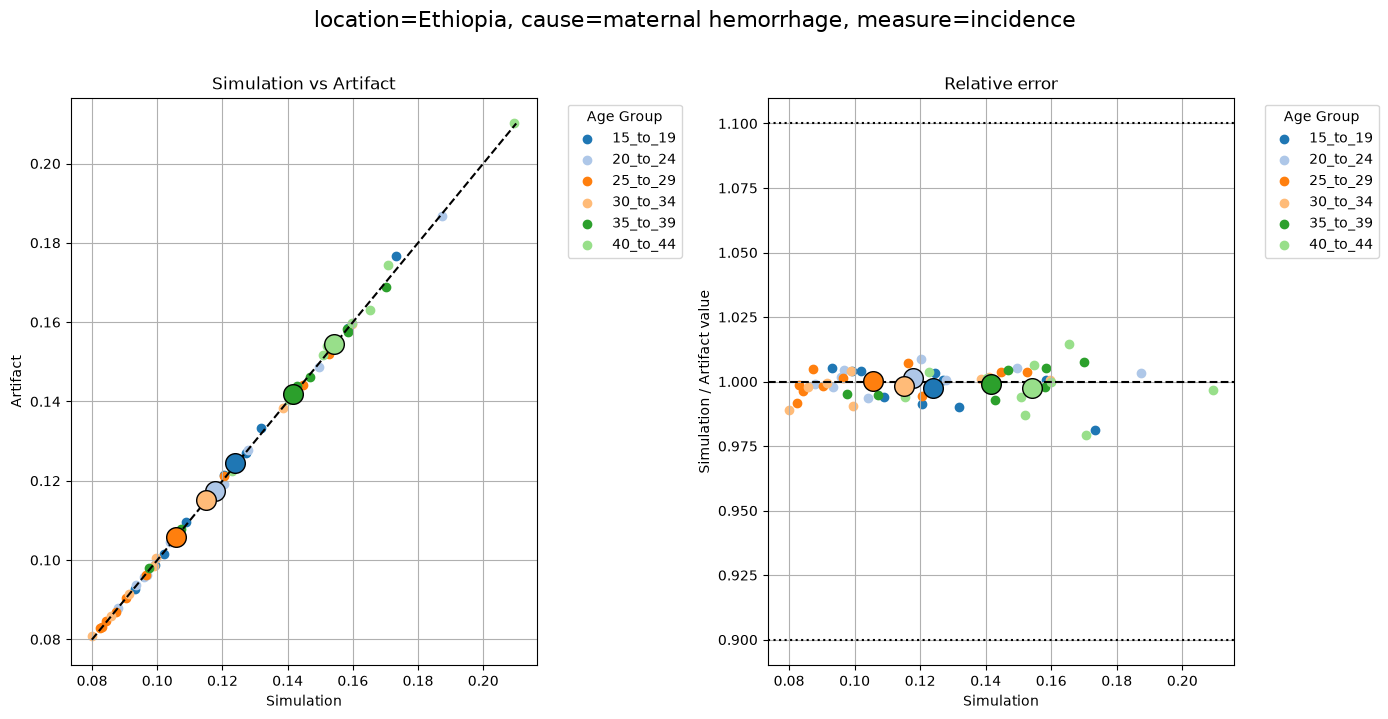

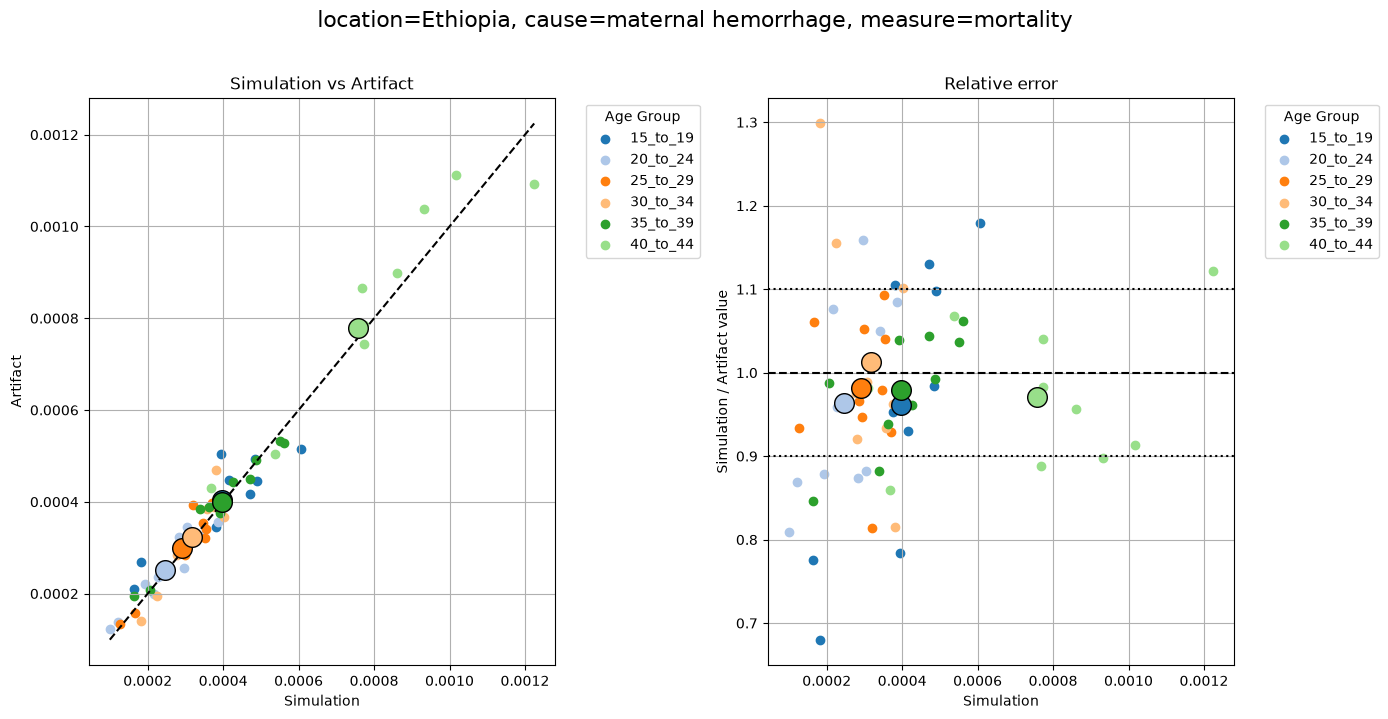

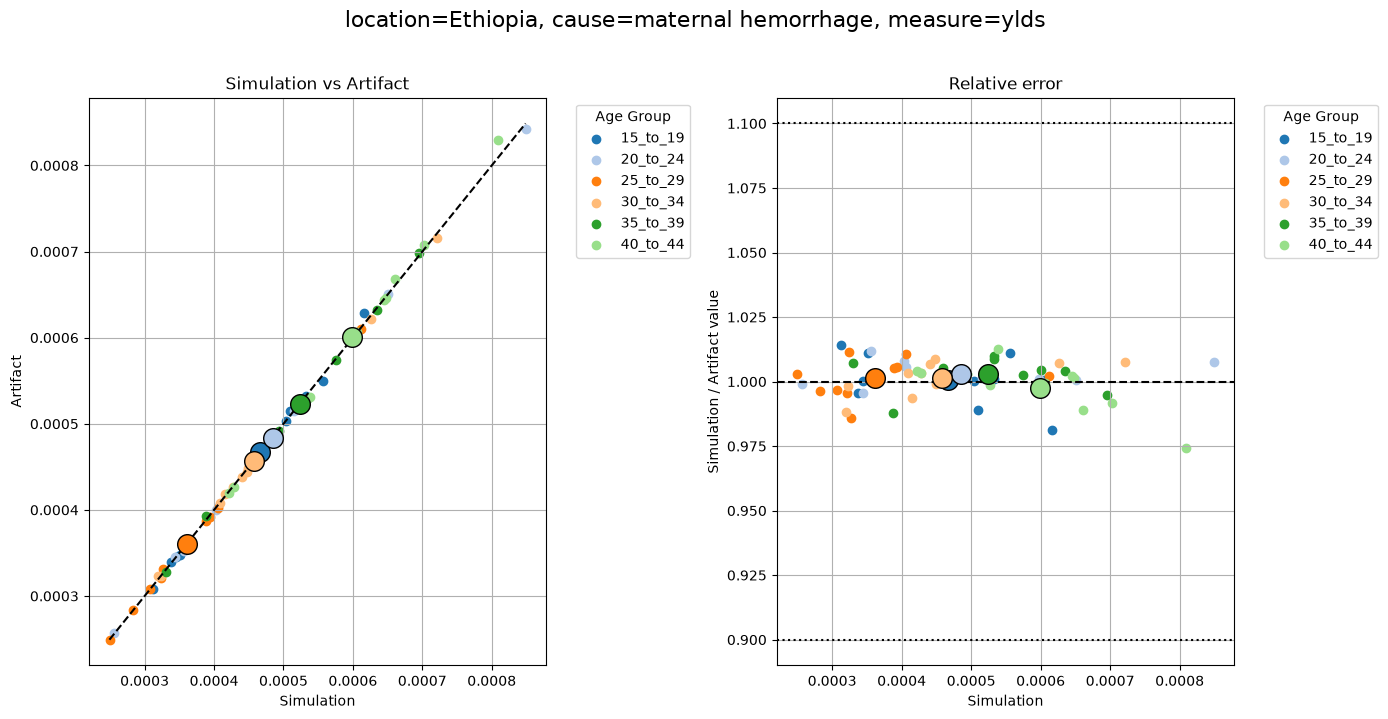

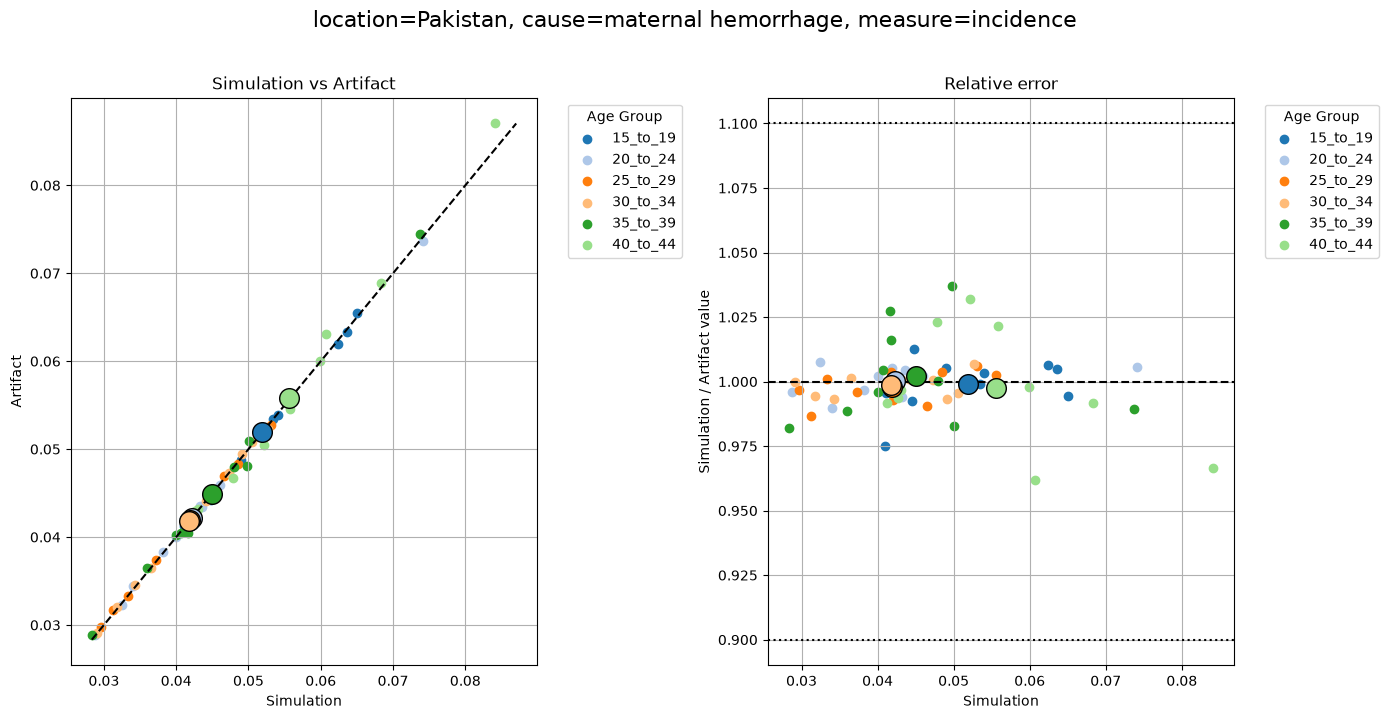

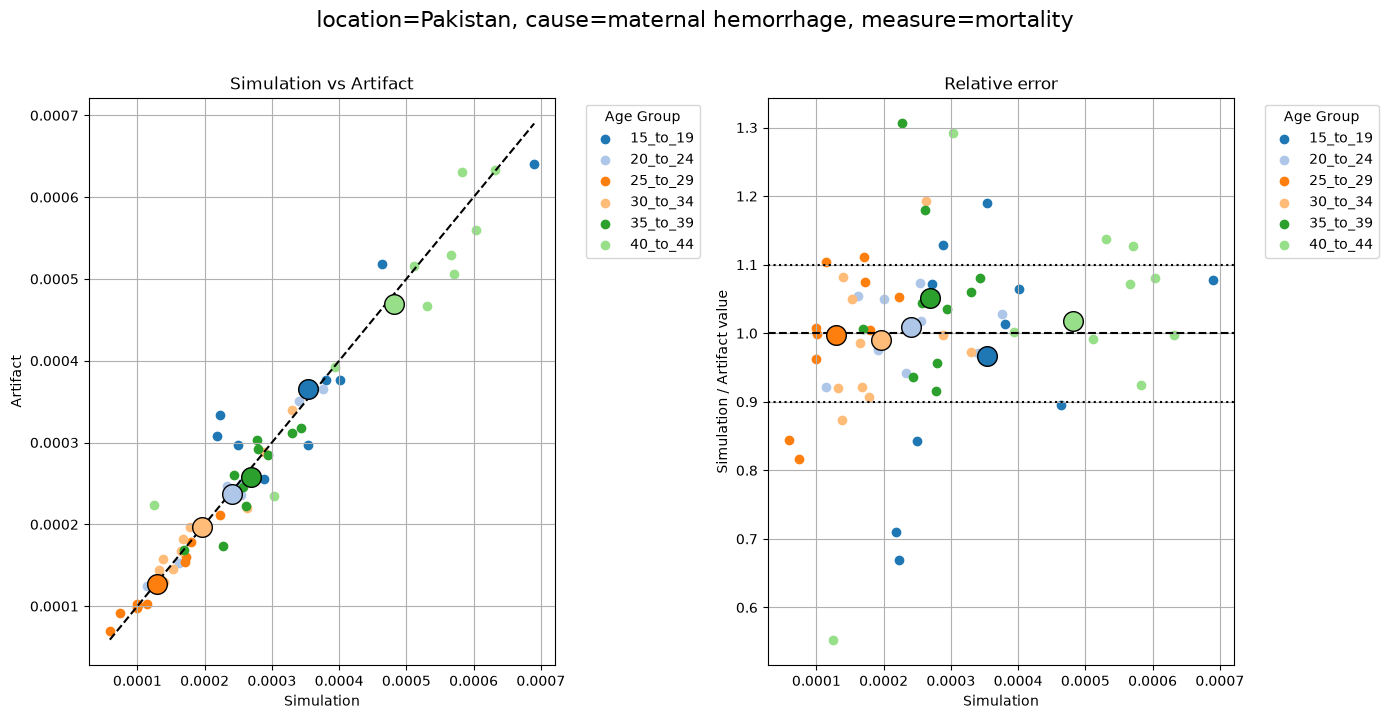

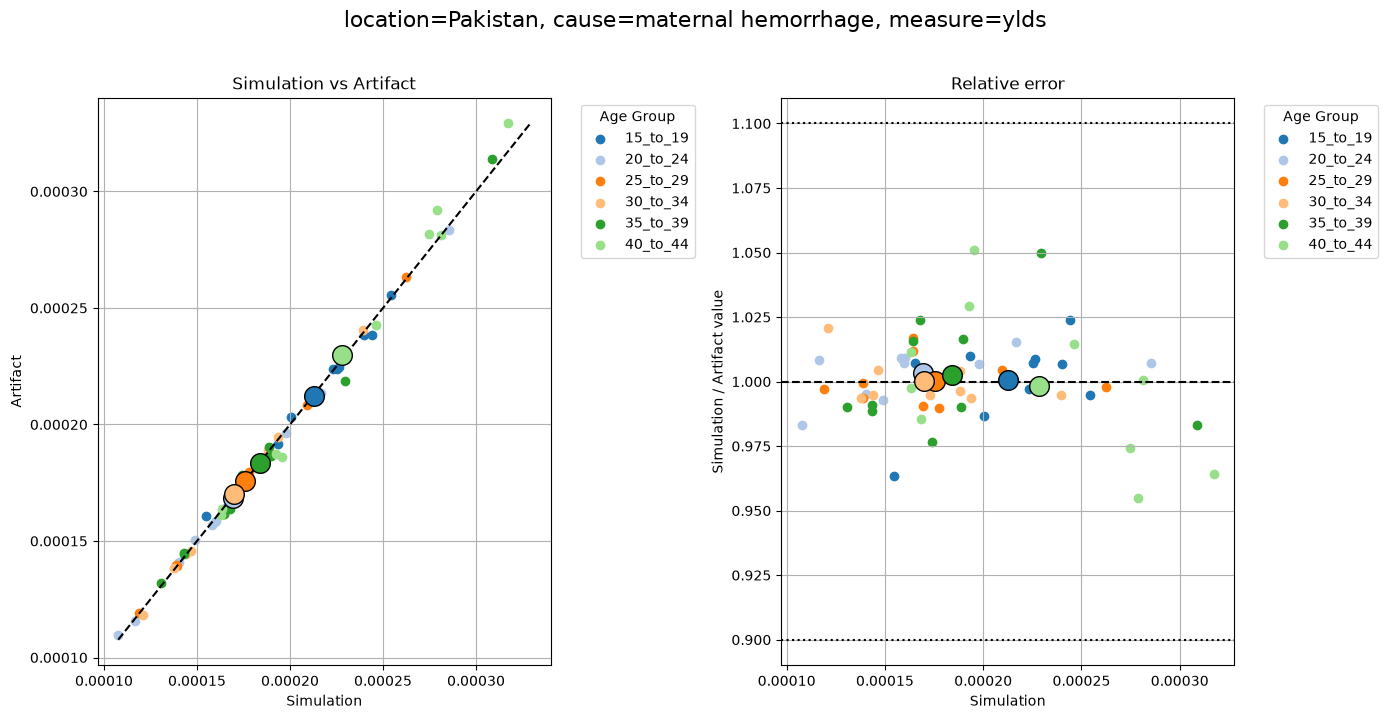

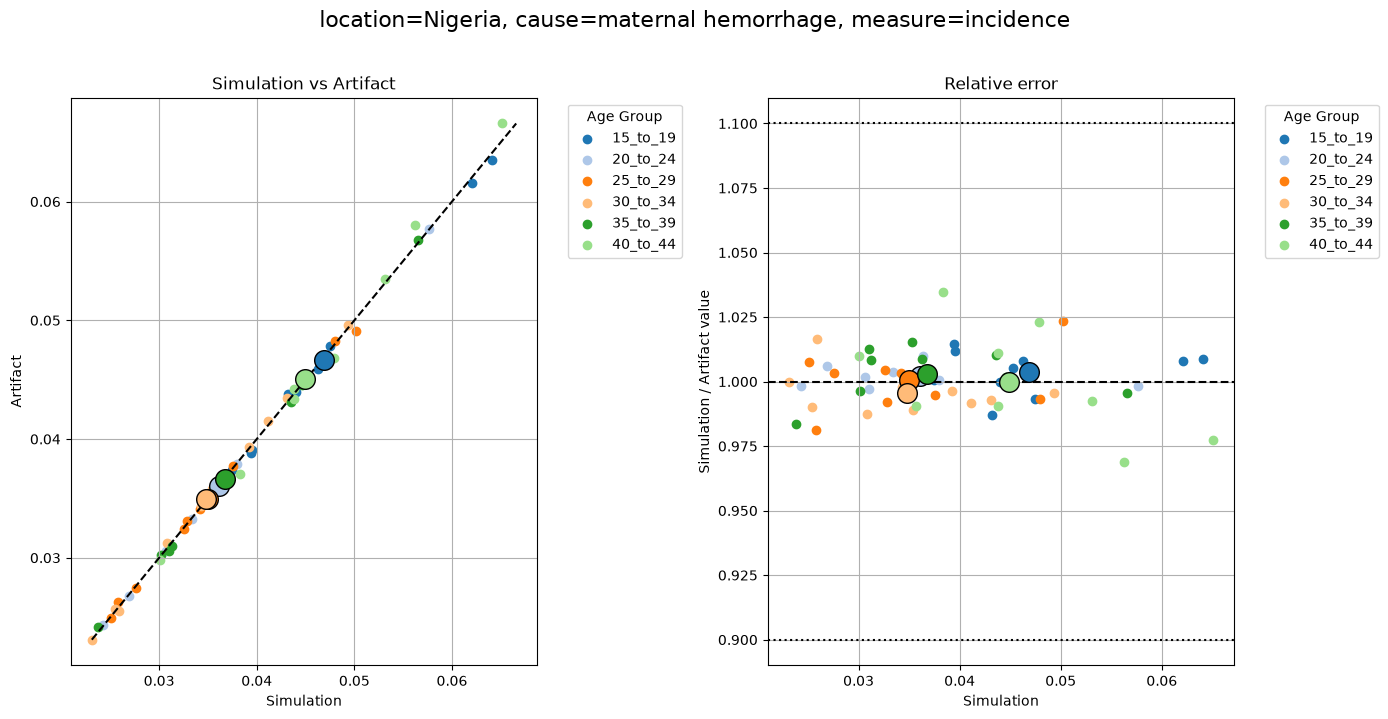

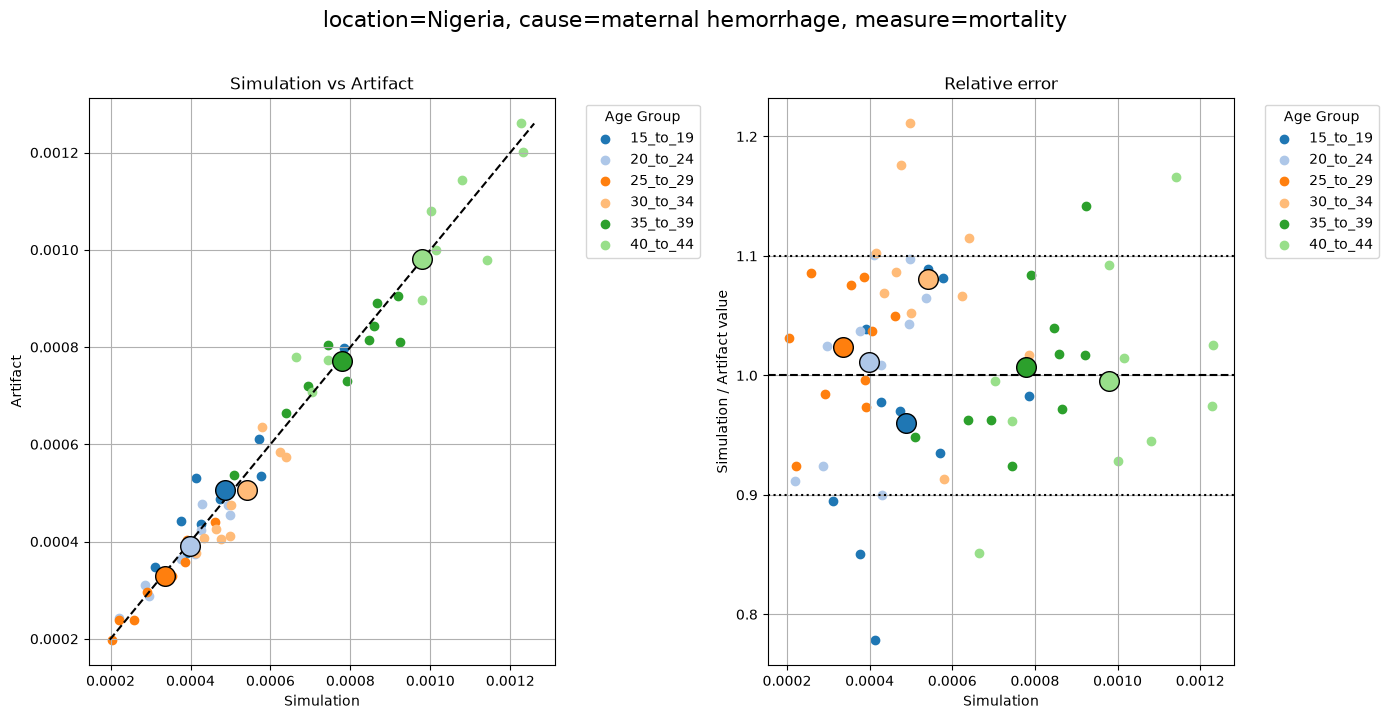

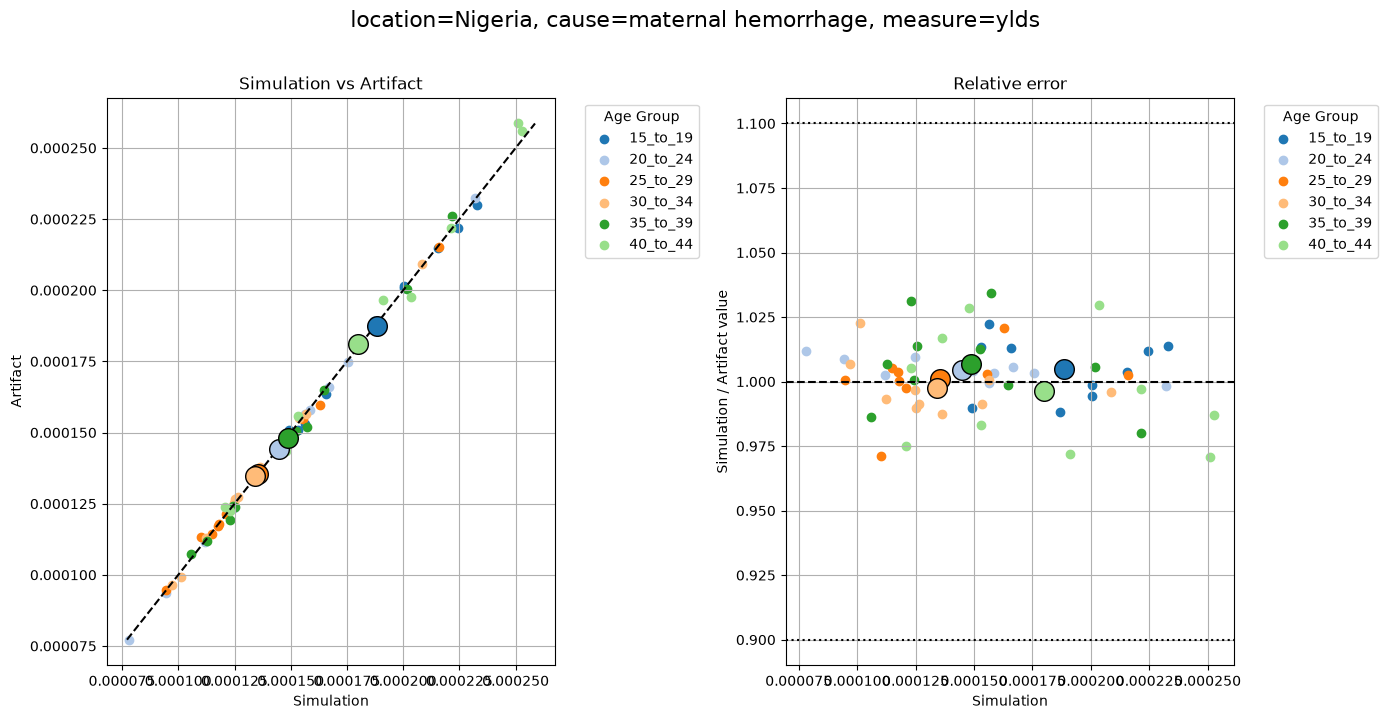

In [43]:
for location in locations:
    for measure in measures:    
        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'maternal_hemorrhage',
            'measure': measure,
        })

# Incidence is overestimated, which has been the case since model 13
# https://github.com/ihmeuw/vivarium_research_mncnh_portfolio/blob/718ba6c8d45c024b8594d1b980e8d7afdfb58f9a/verification_and_validation/model_13.0_maternal_checks.ipynb
# It seems like we might overestimate more in draws with higher incidence (and less in draws with lower incidence)
# TODO: Note about uncertainty here and for all disorders incl sepsis assuming we decide it passes V&V

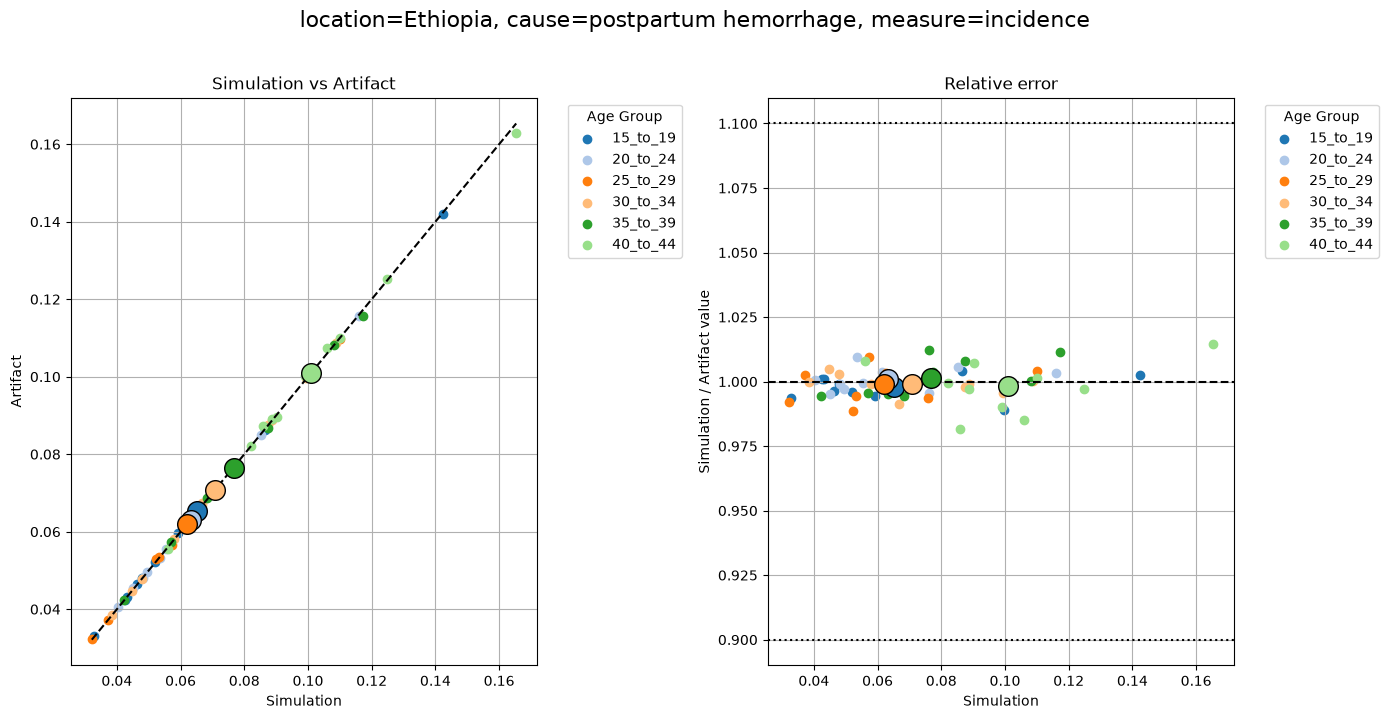

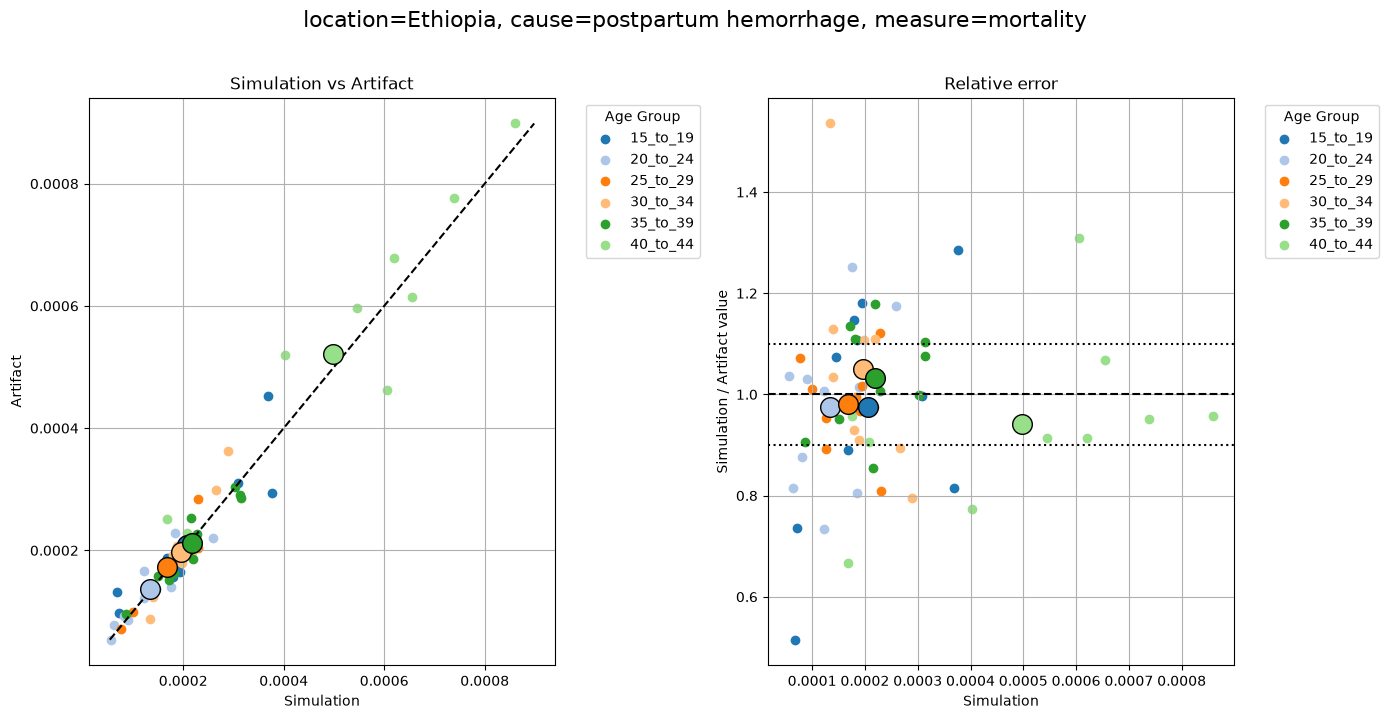

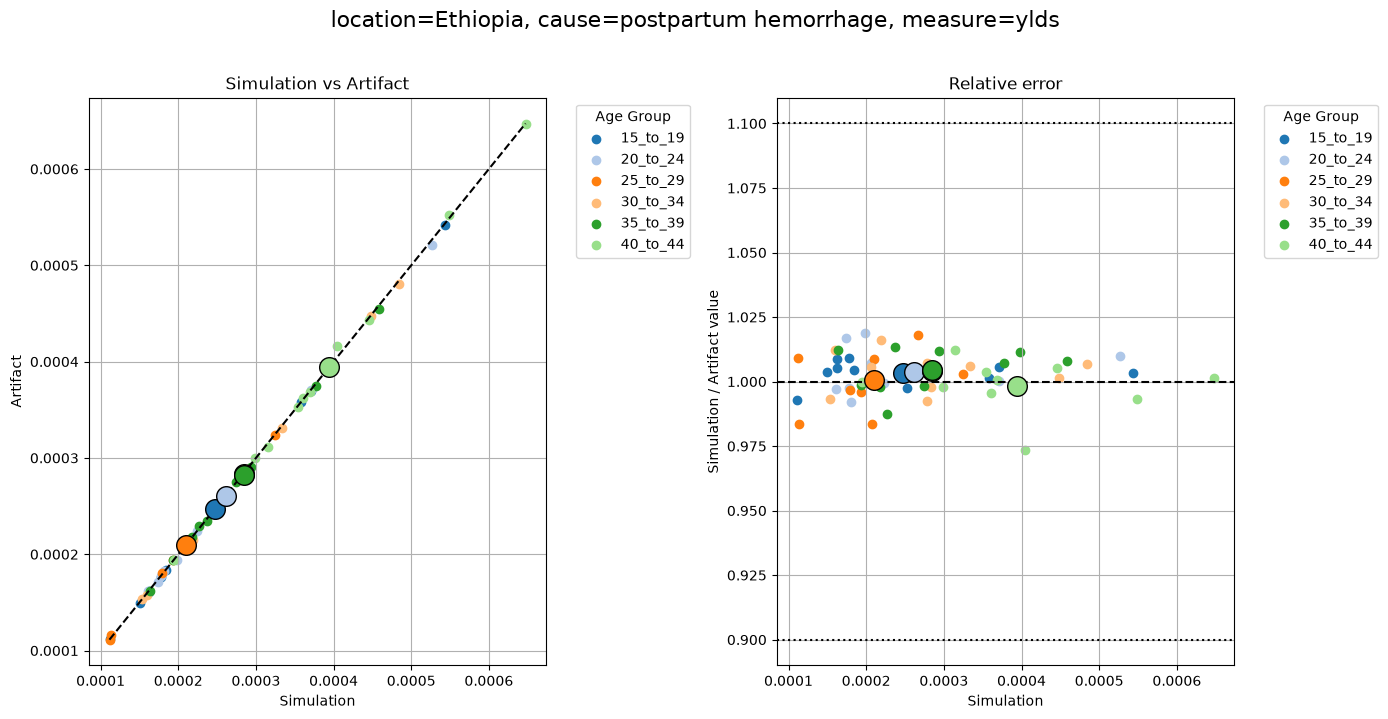

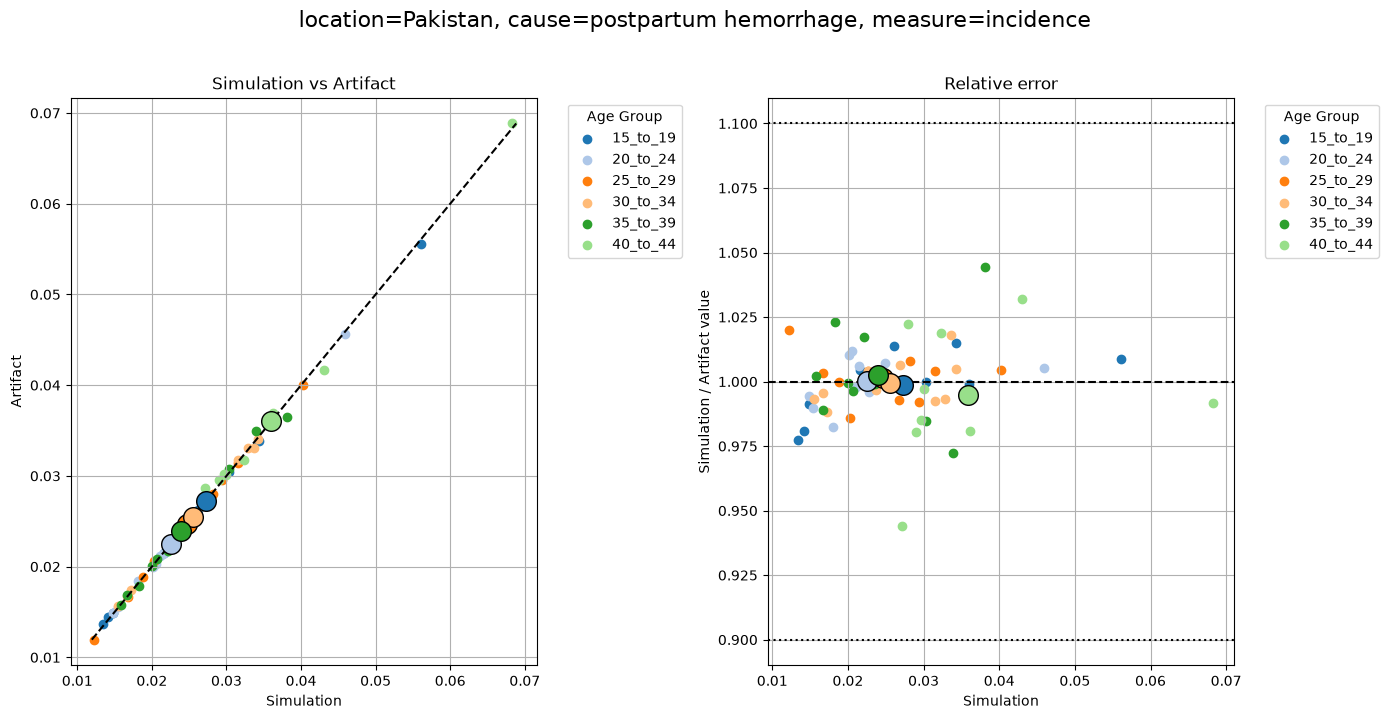

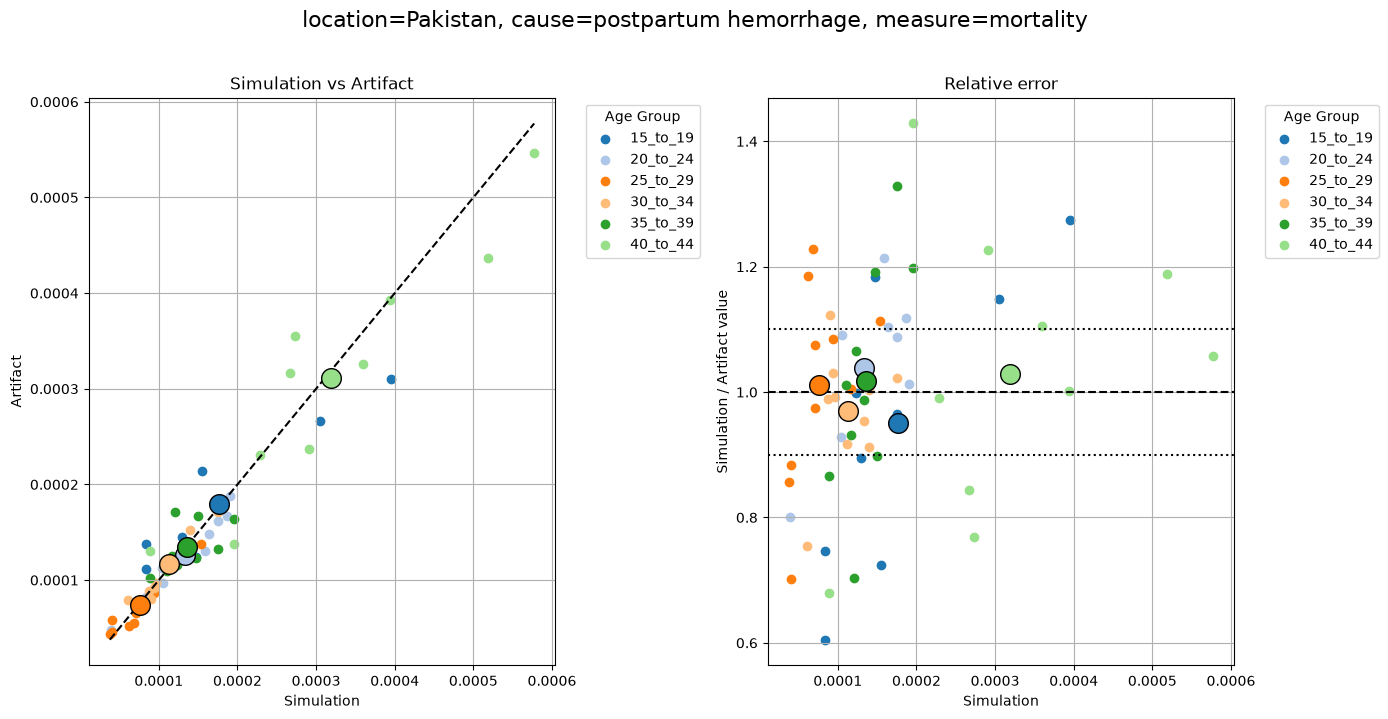

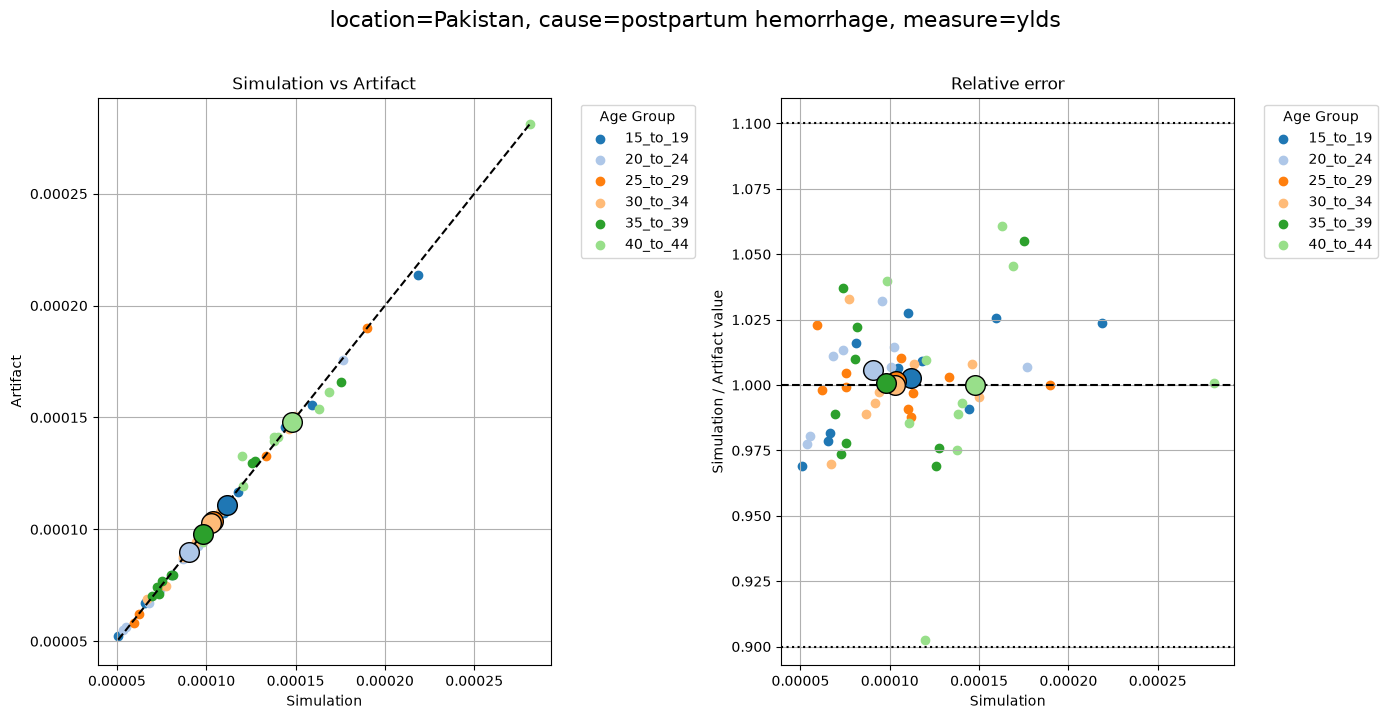

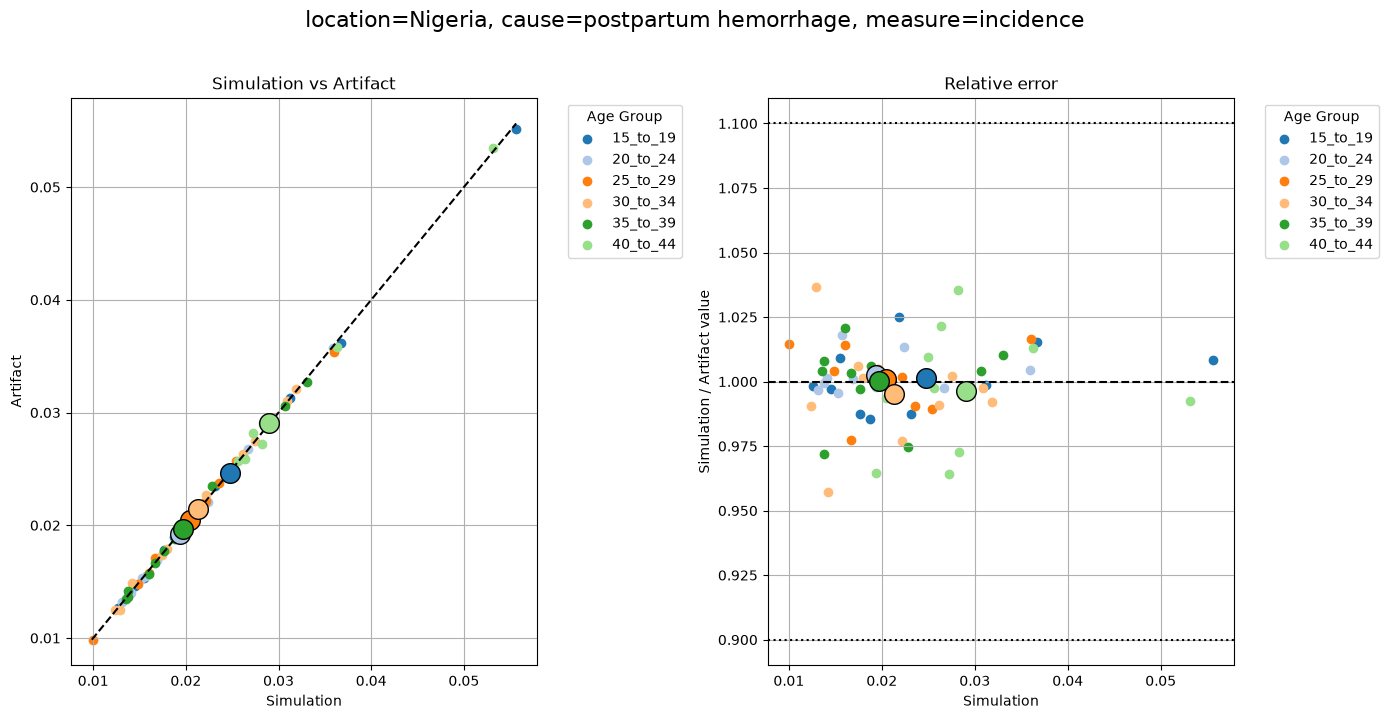

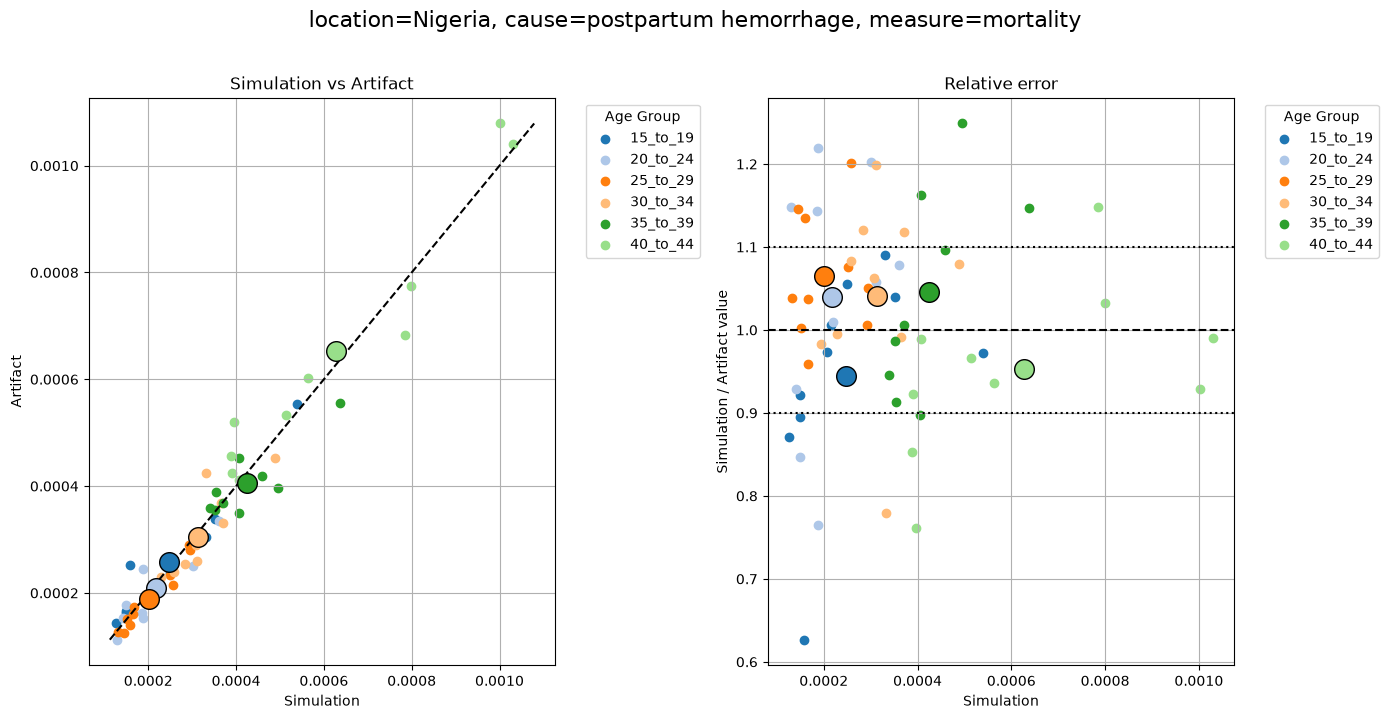

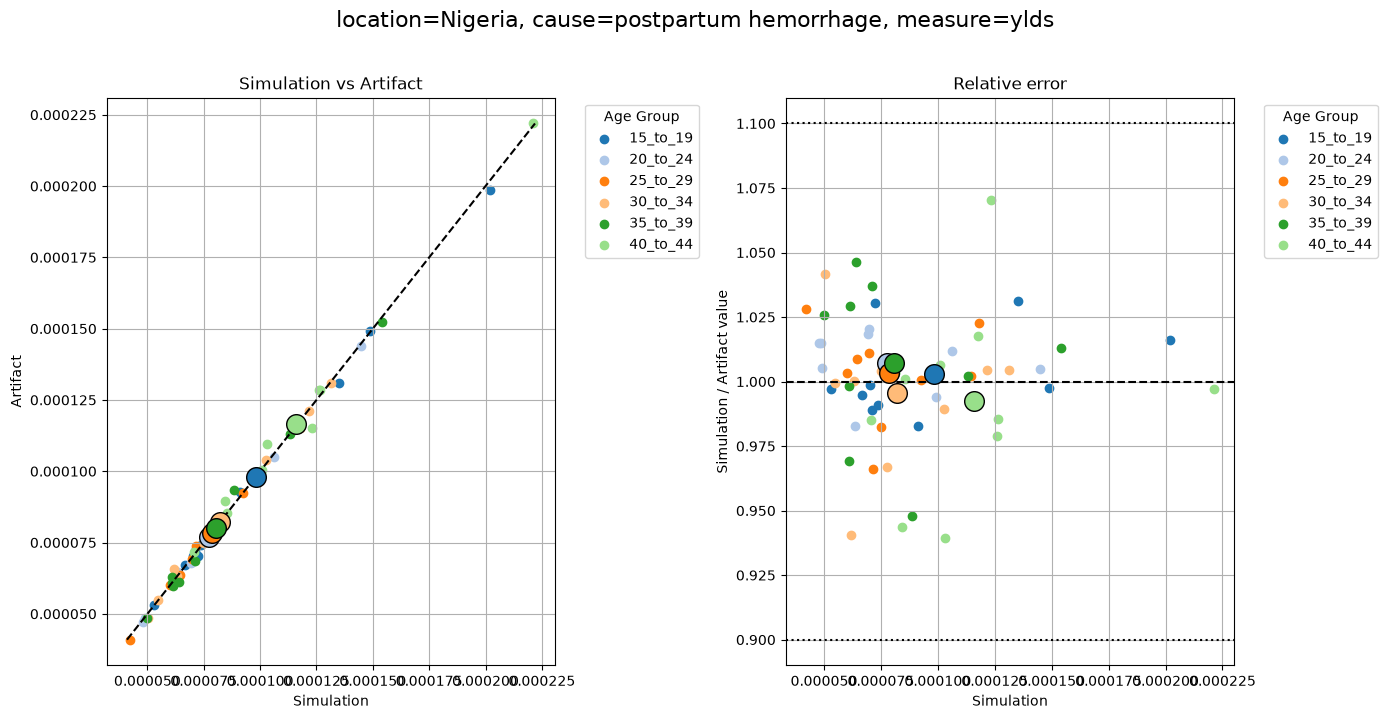

In [44]:
for location in locations:
    for measure in measures:    
        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'postpartum_hemorrhage',
            'measure': measure,
        })

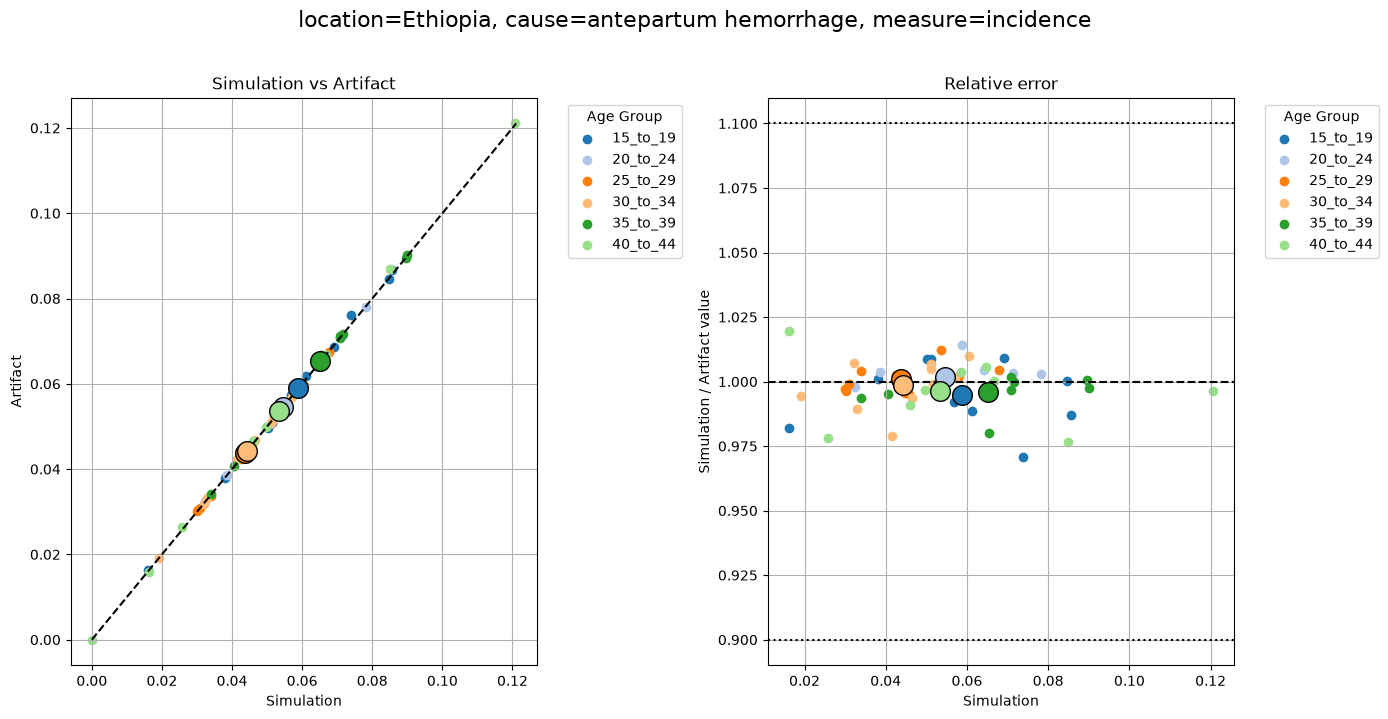

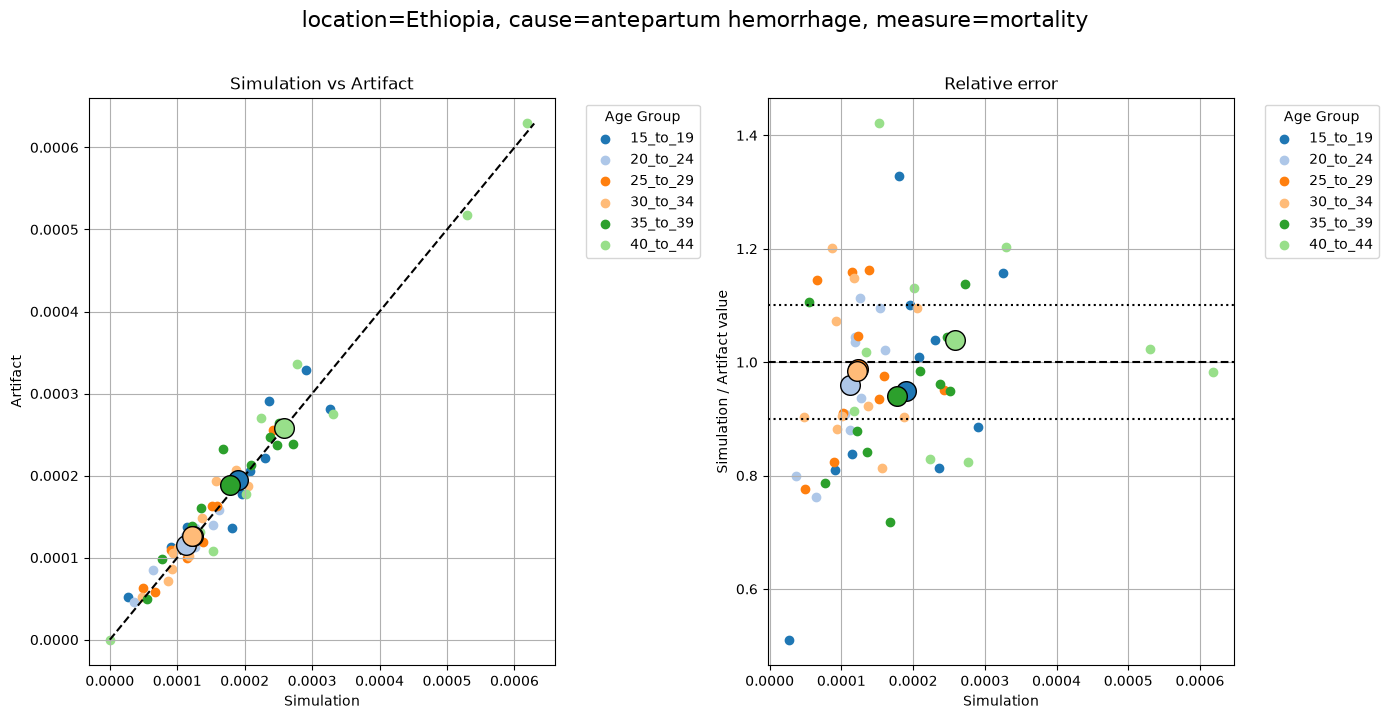

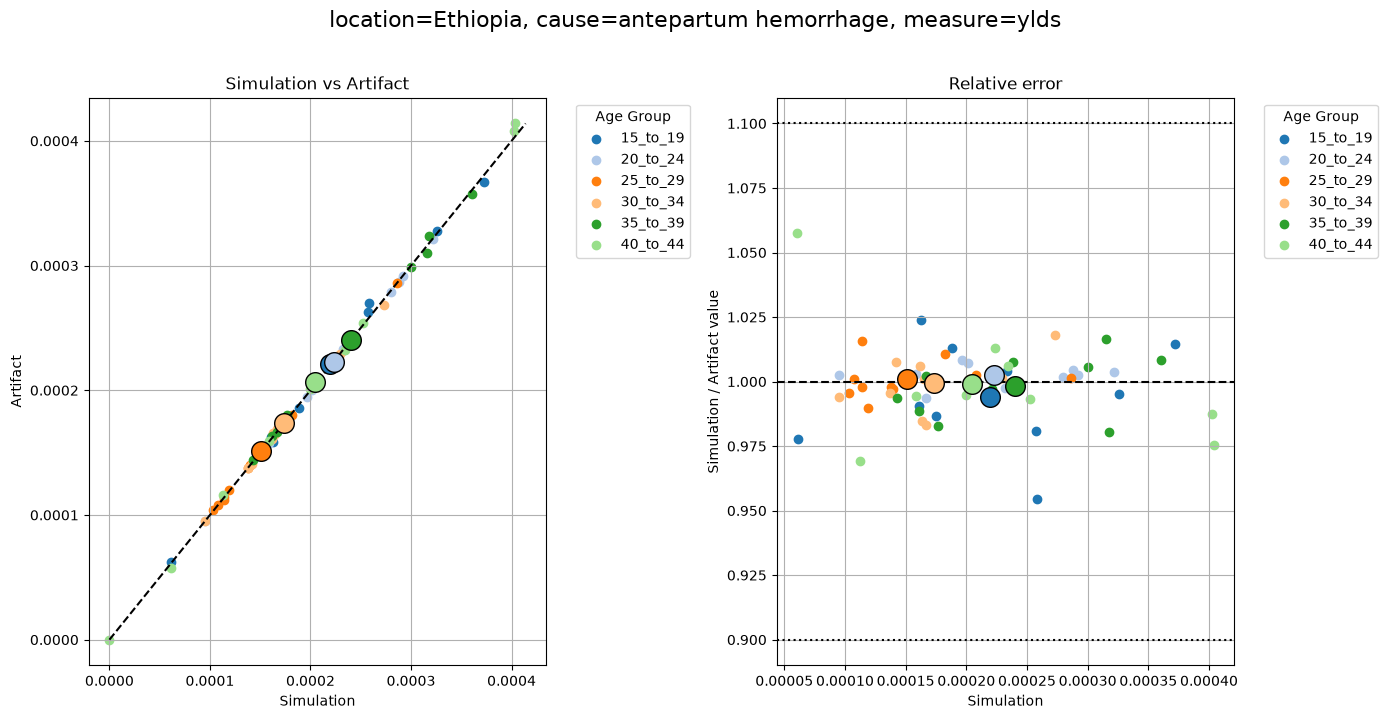

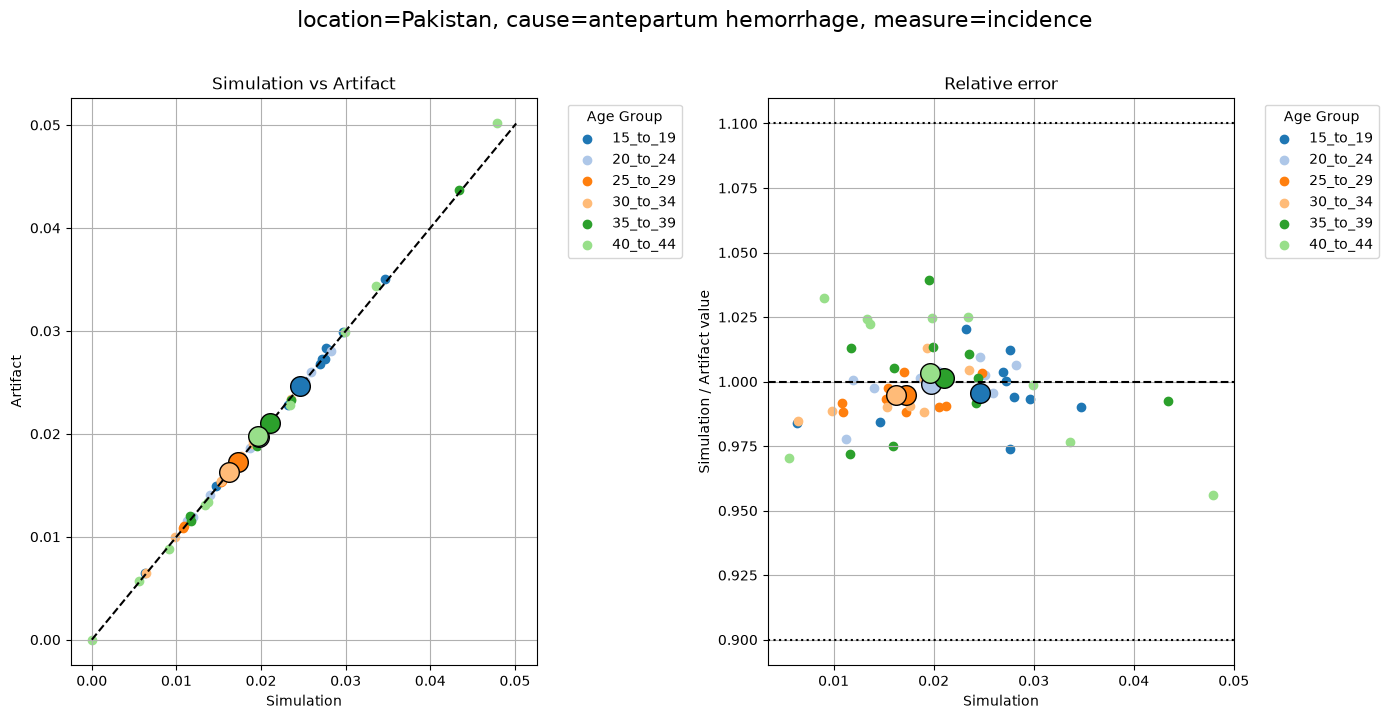

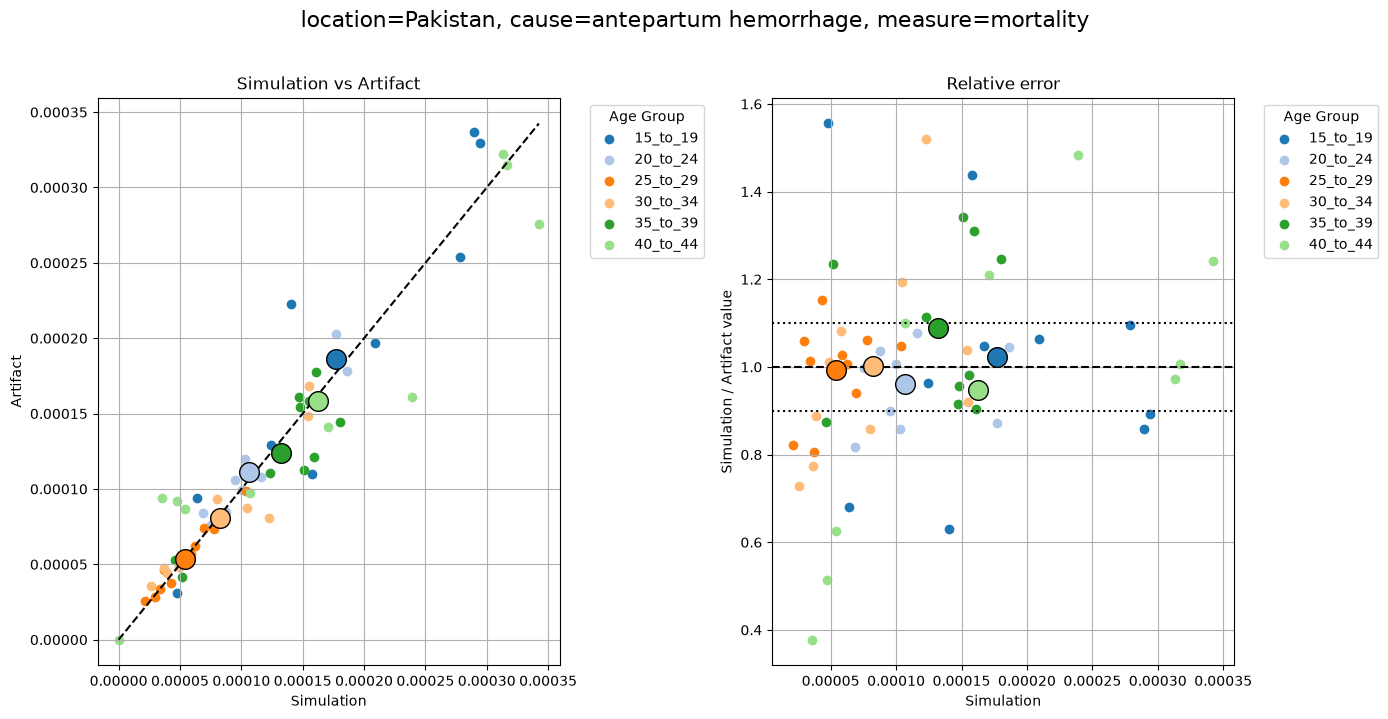

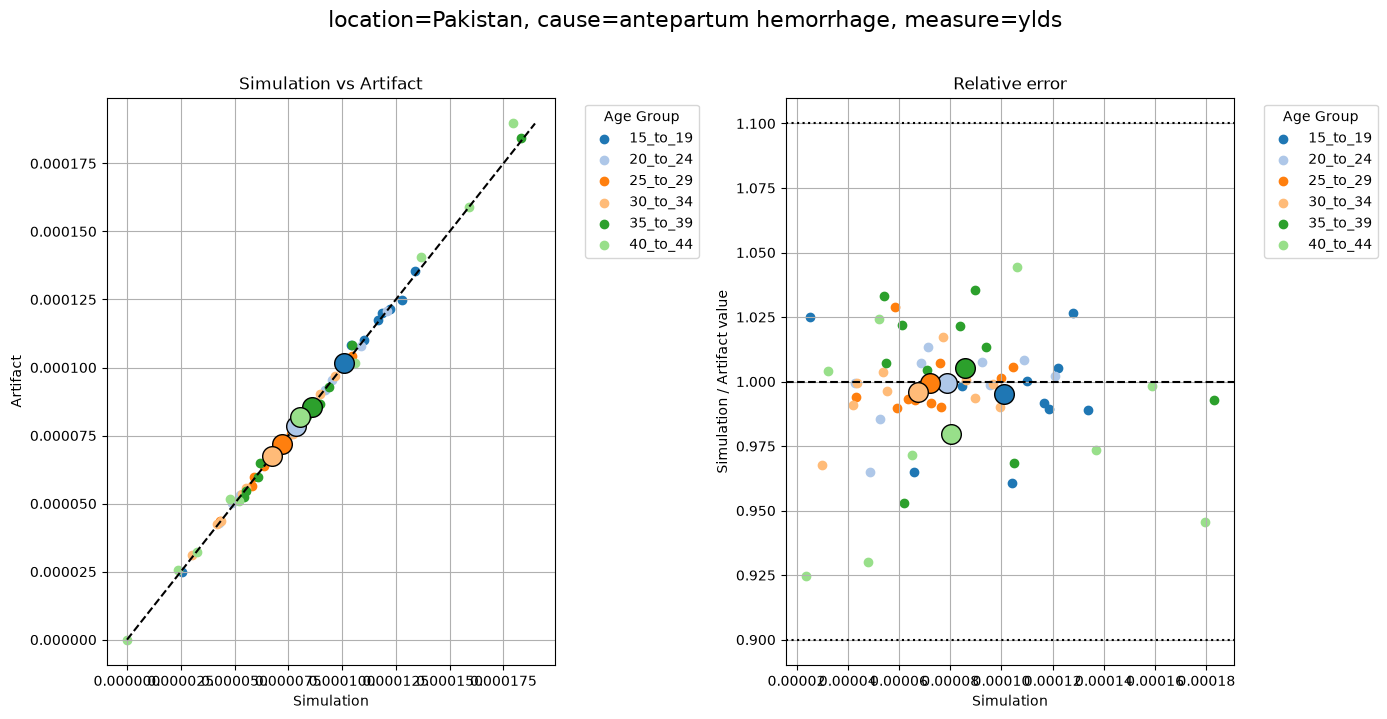

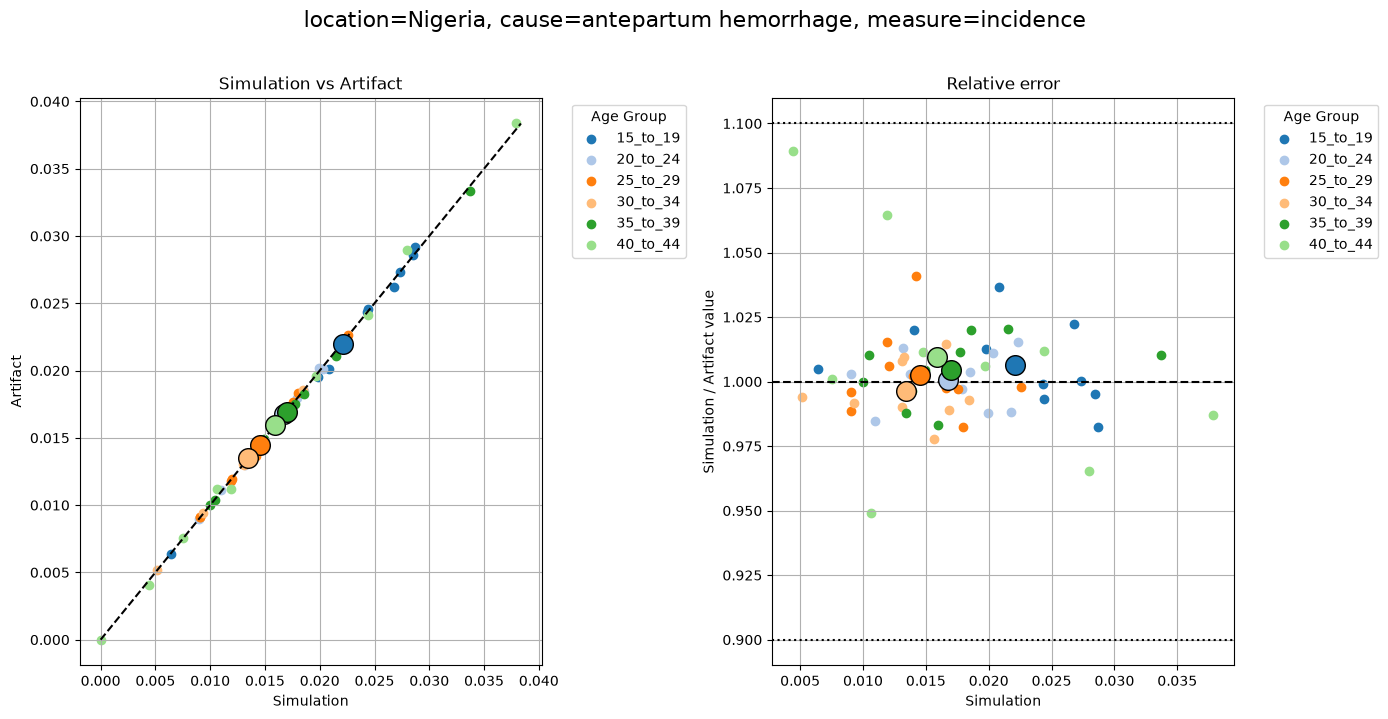

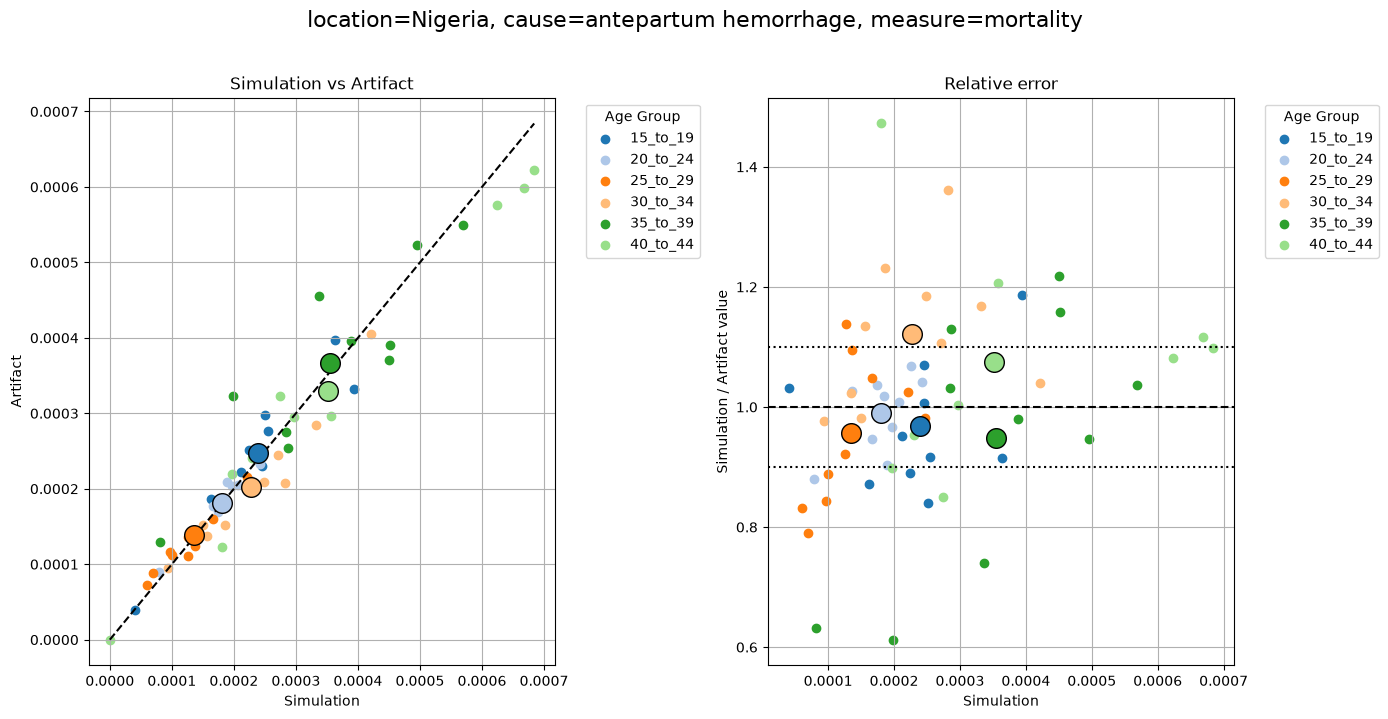

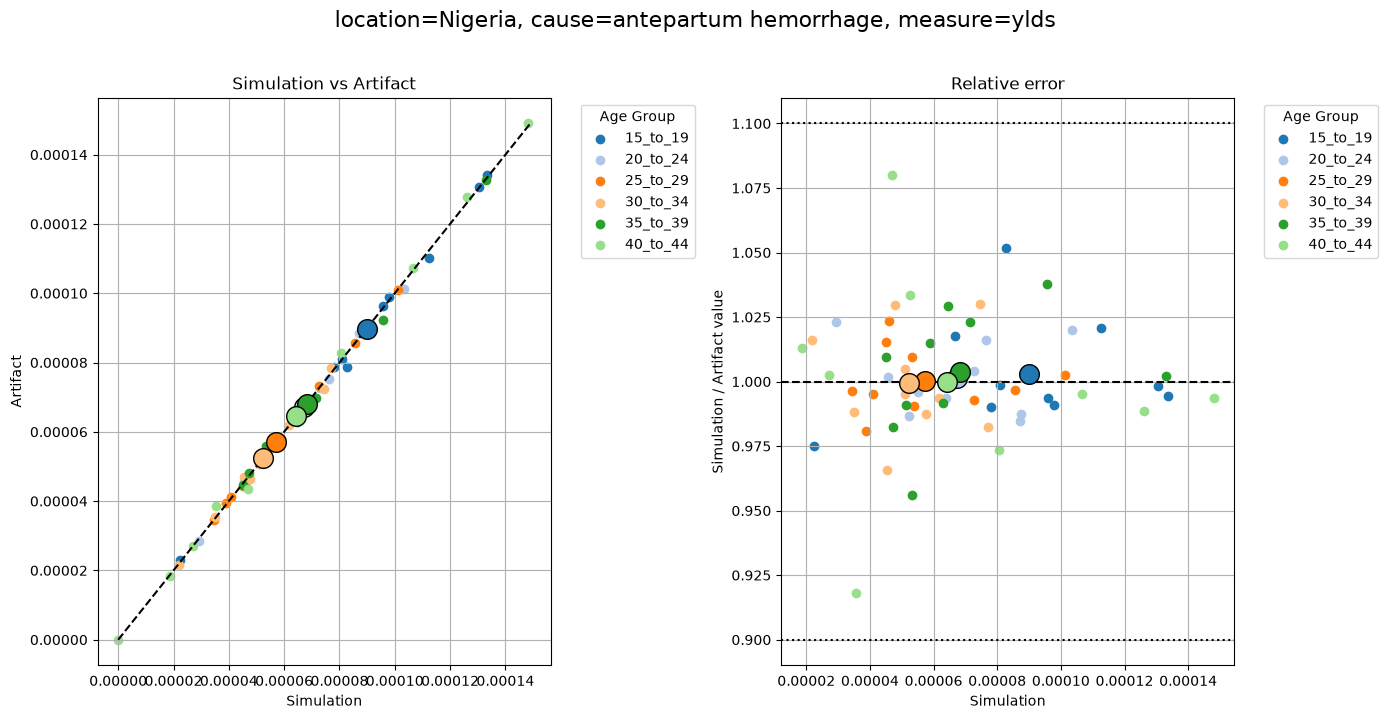

In [45]:
for location in locations:
    for measure in measures:    
        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'antepartum_hemorrhage',
            'measure': measure,
        })

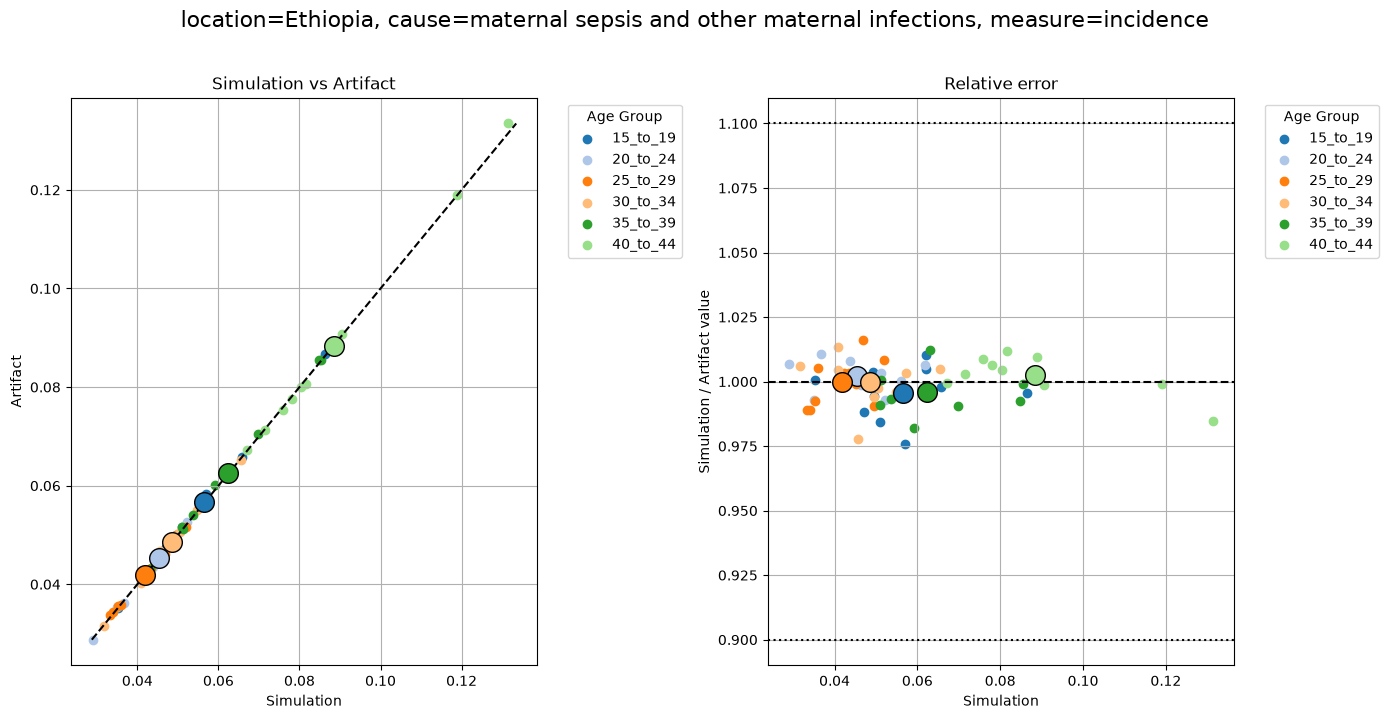

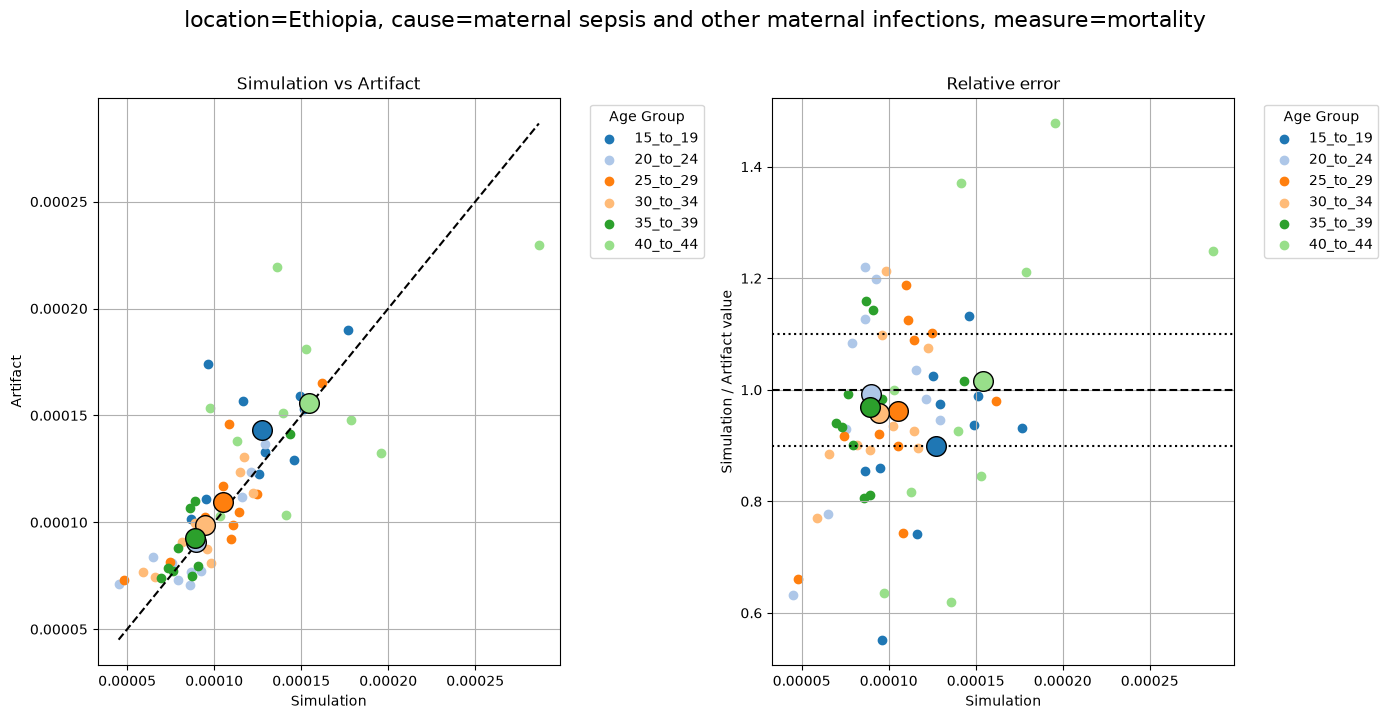

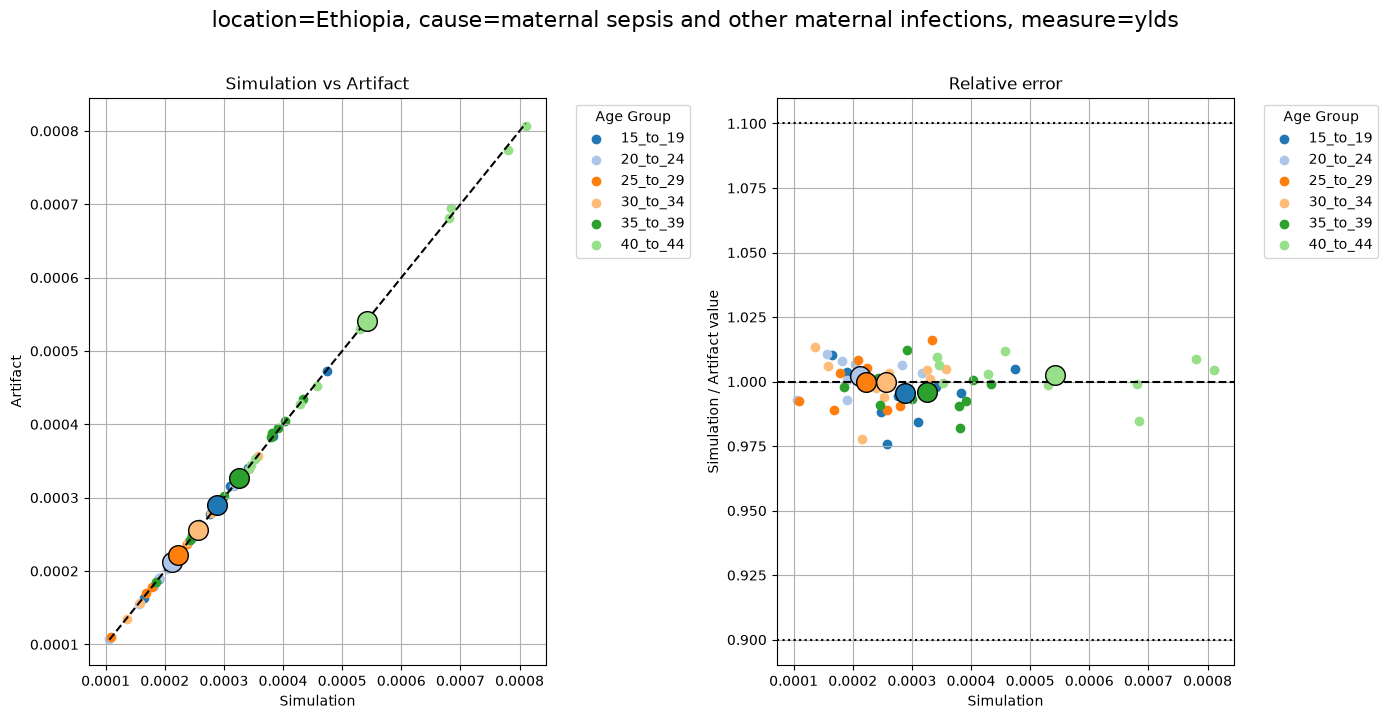

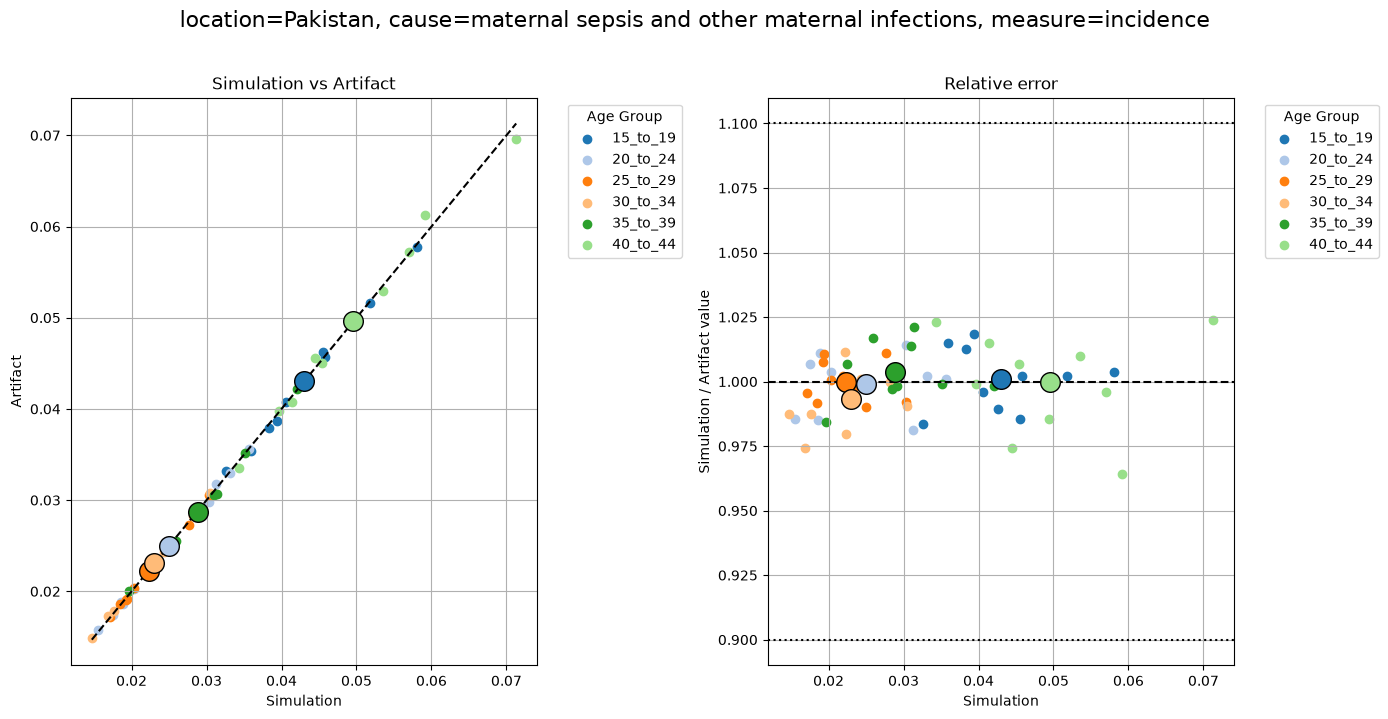

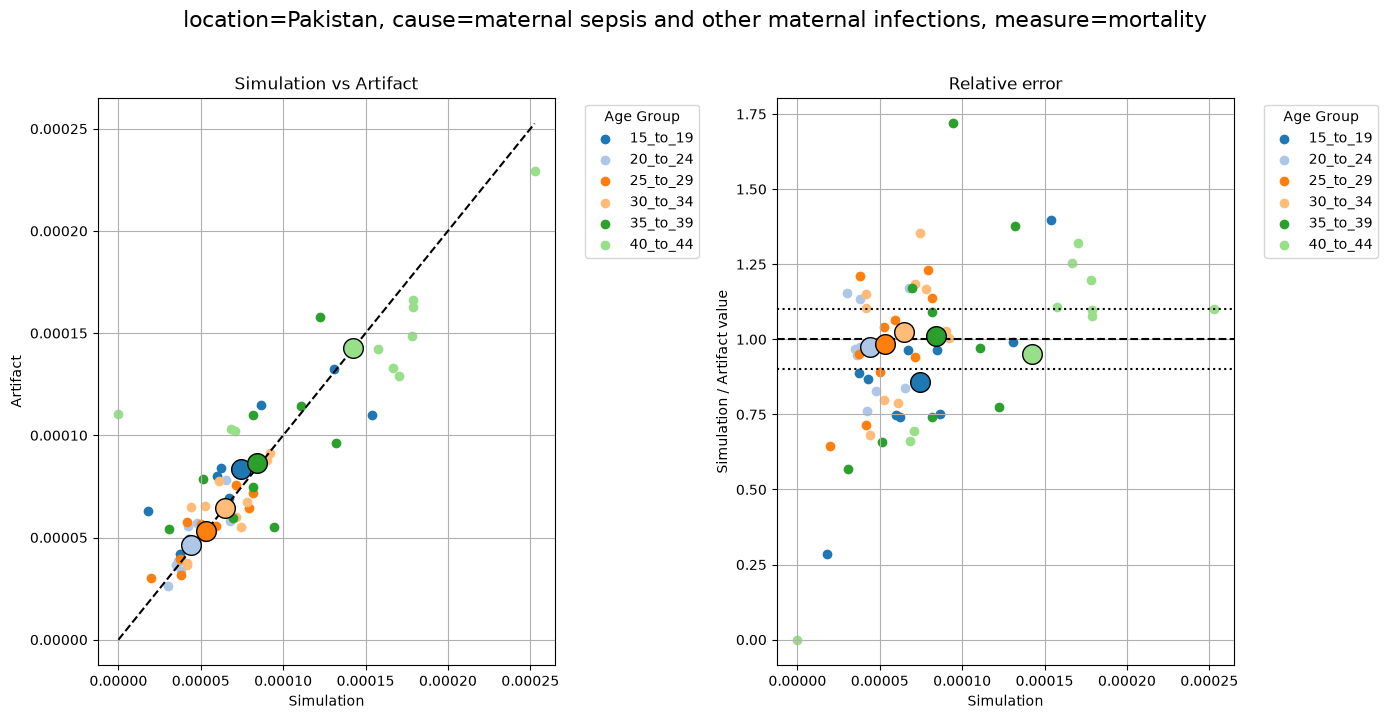

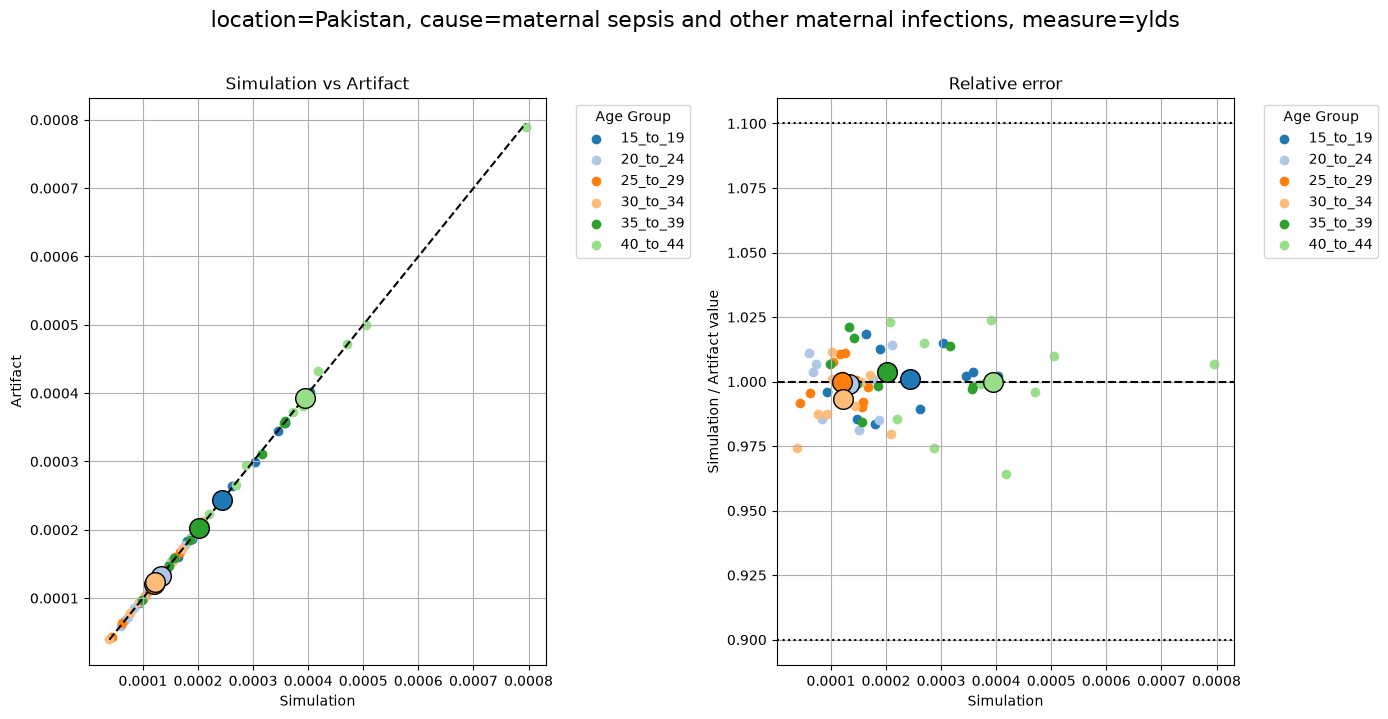

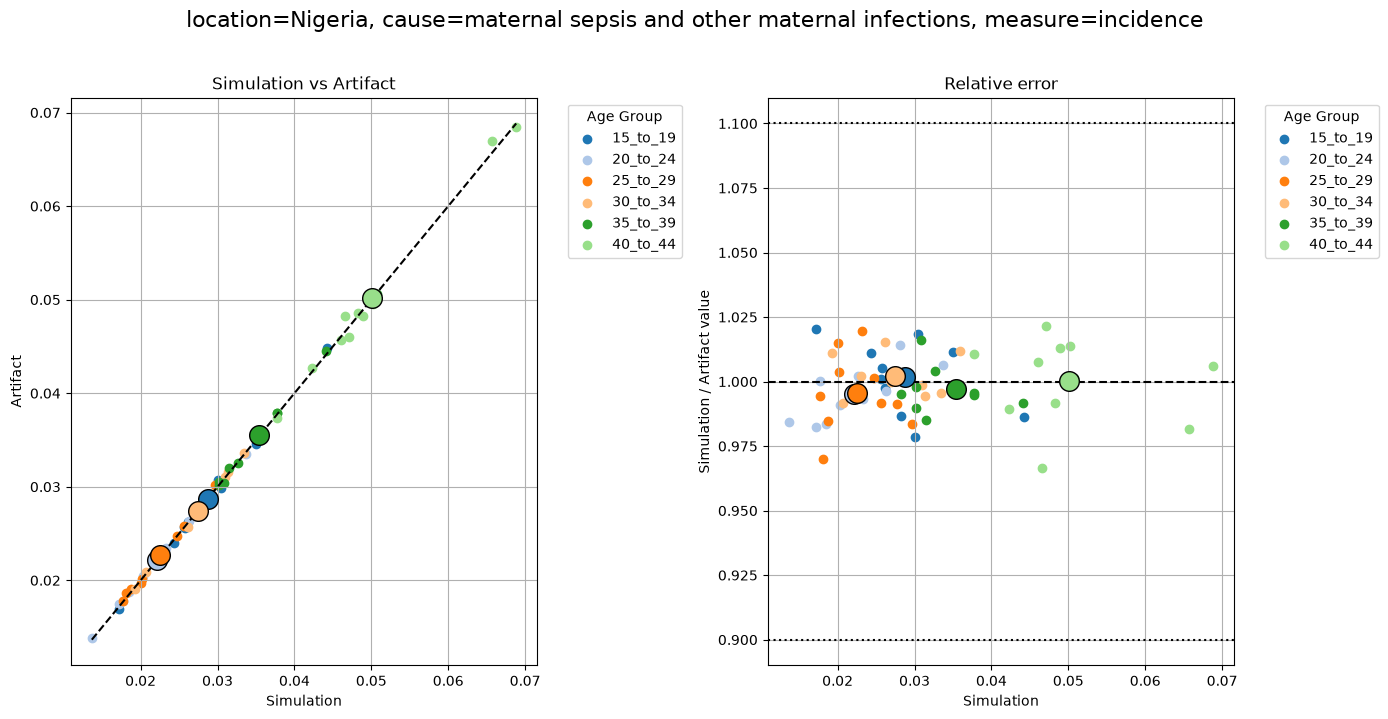

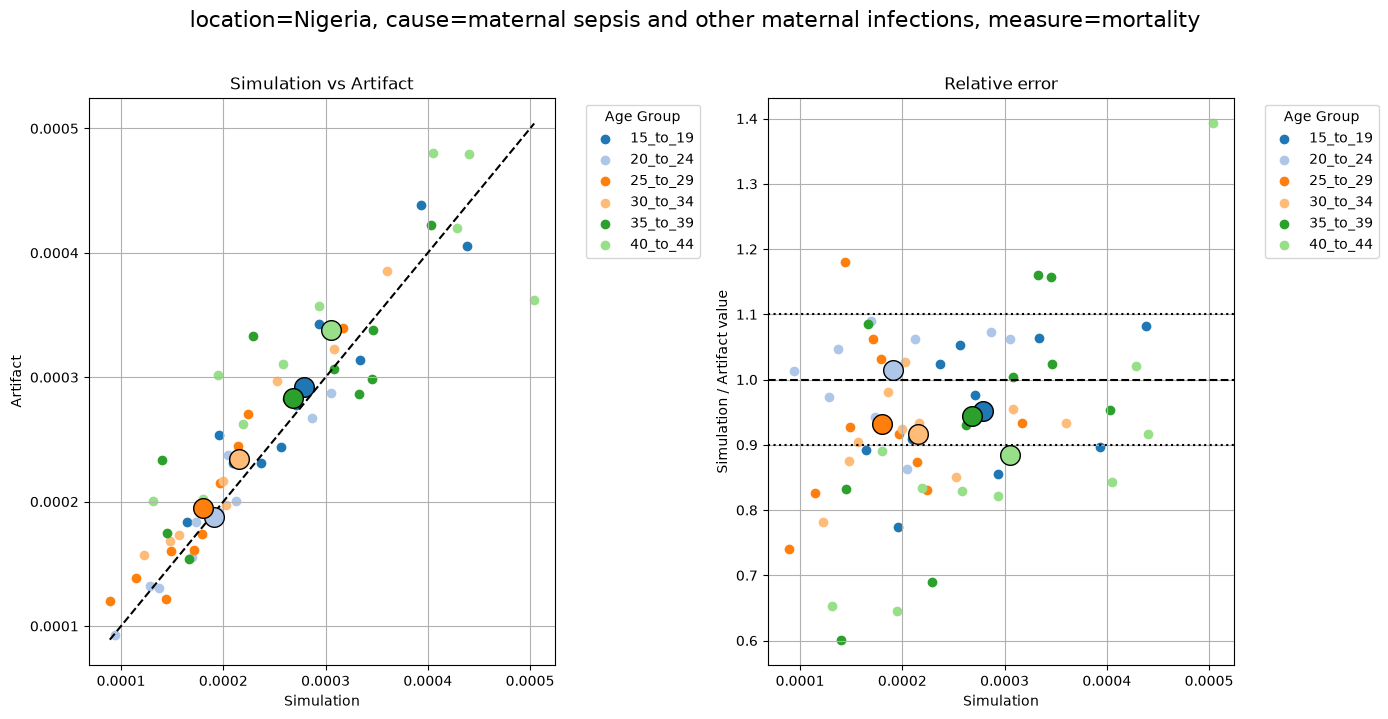

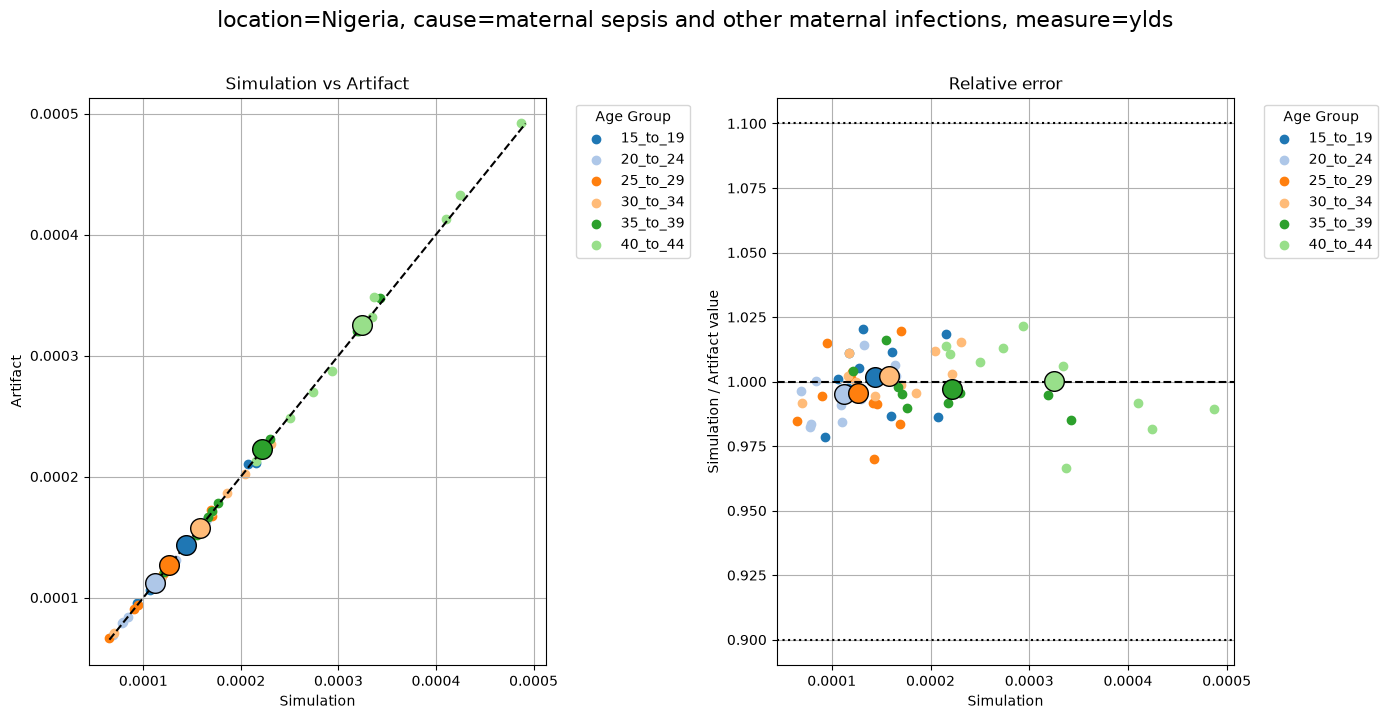

In [46]:
for location in locations:
    for measure in measures:    
        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'maternal_sepsis_and_other_maternal_infections',
            'measure': measure,
        })

# Similar issue to hemorrhage
# TODO: we should consider bumping up population size... there are several draws with zero death counts for given age groups

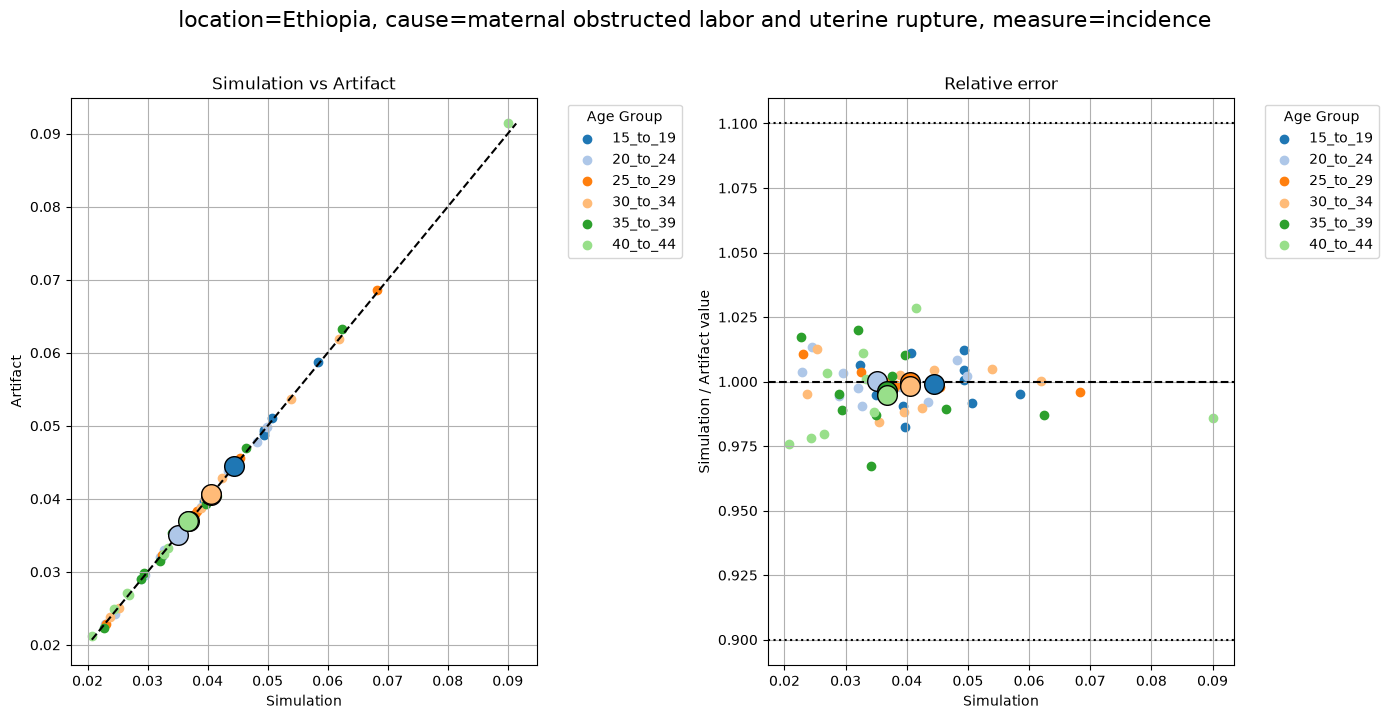

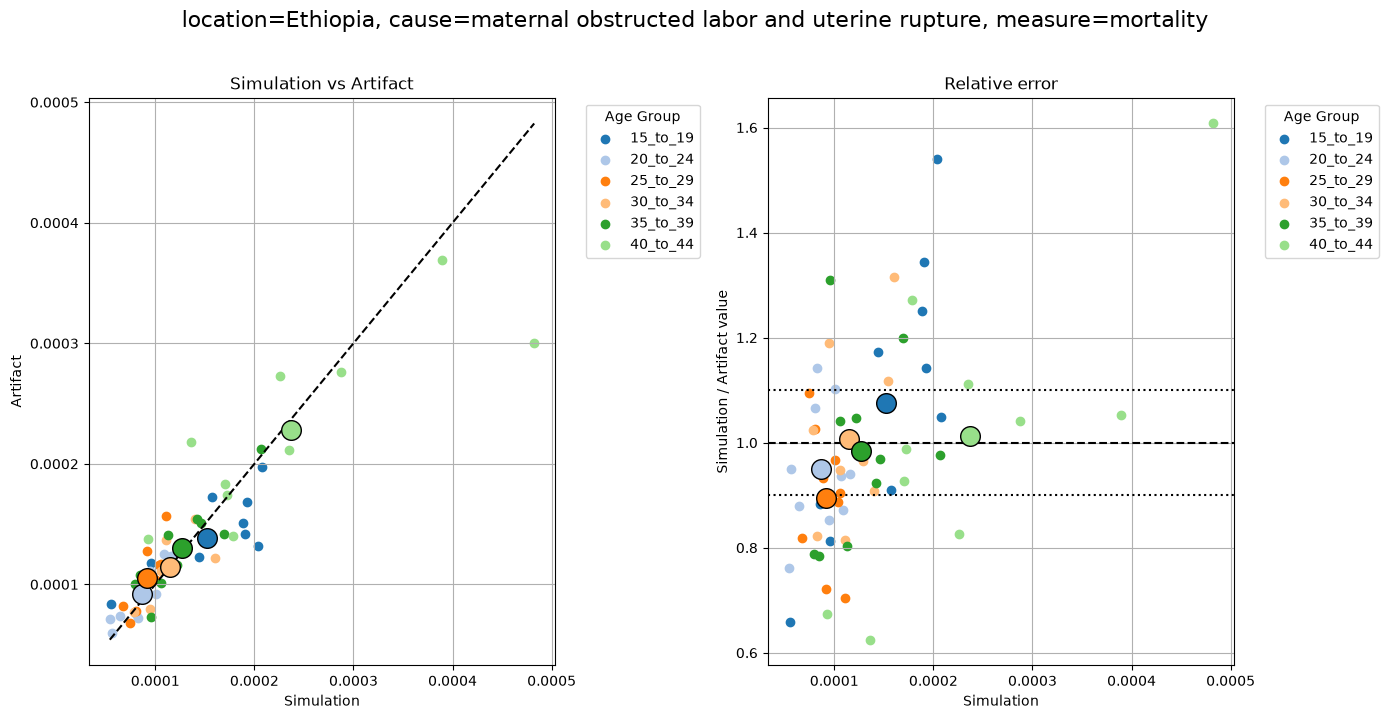

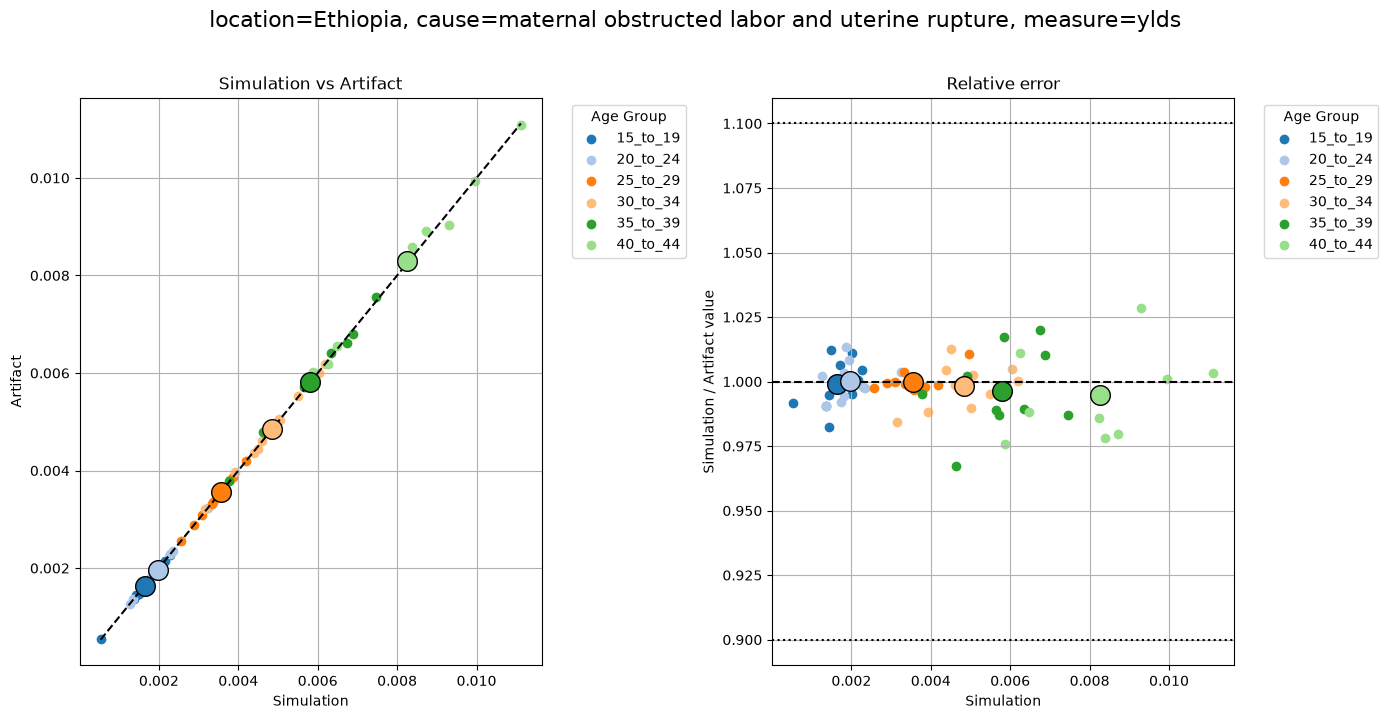

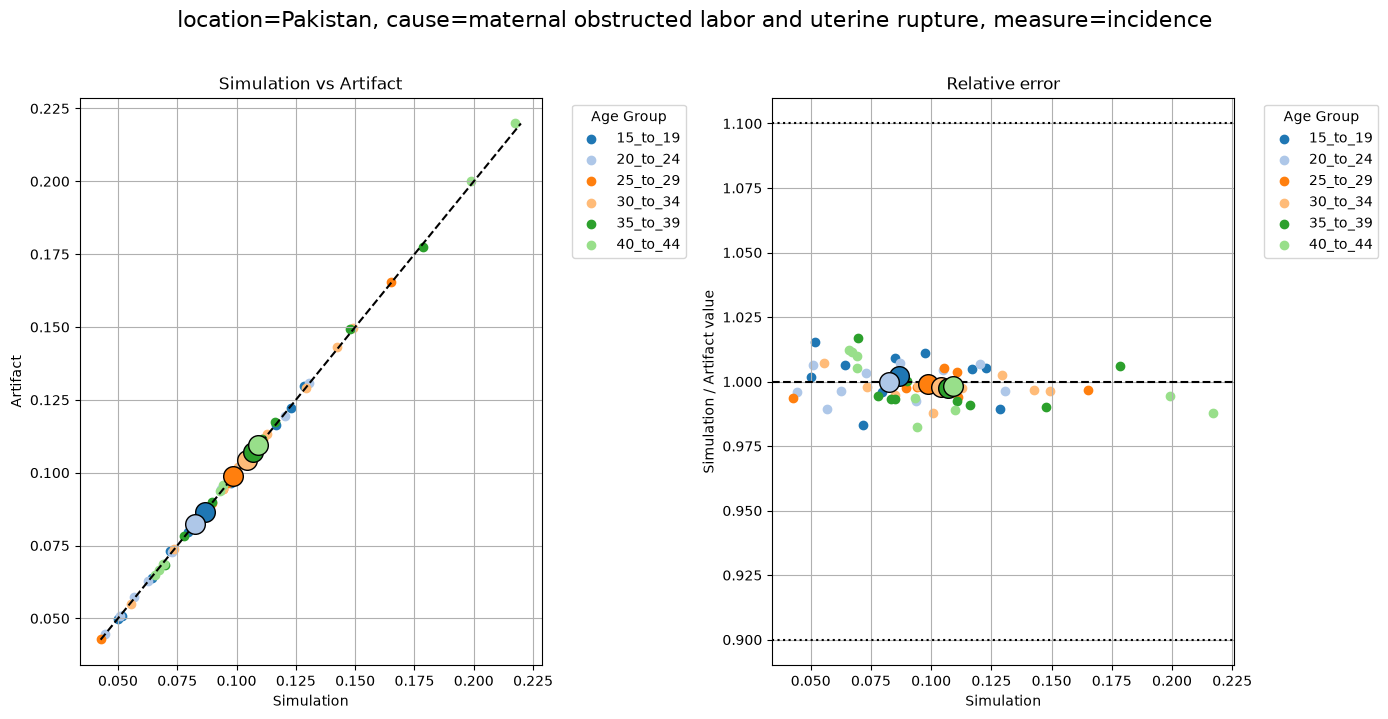

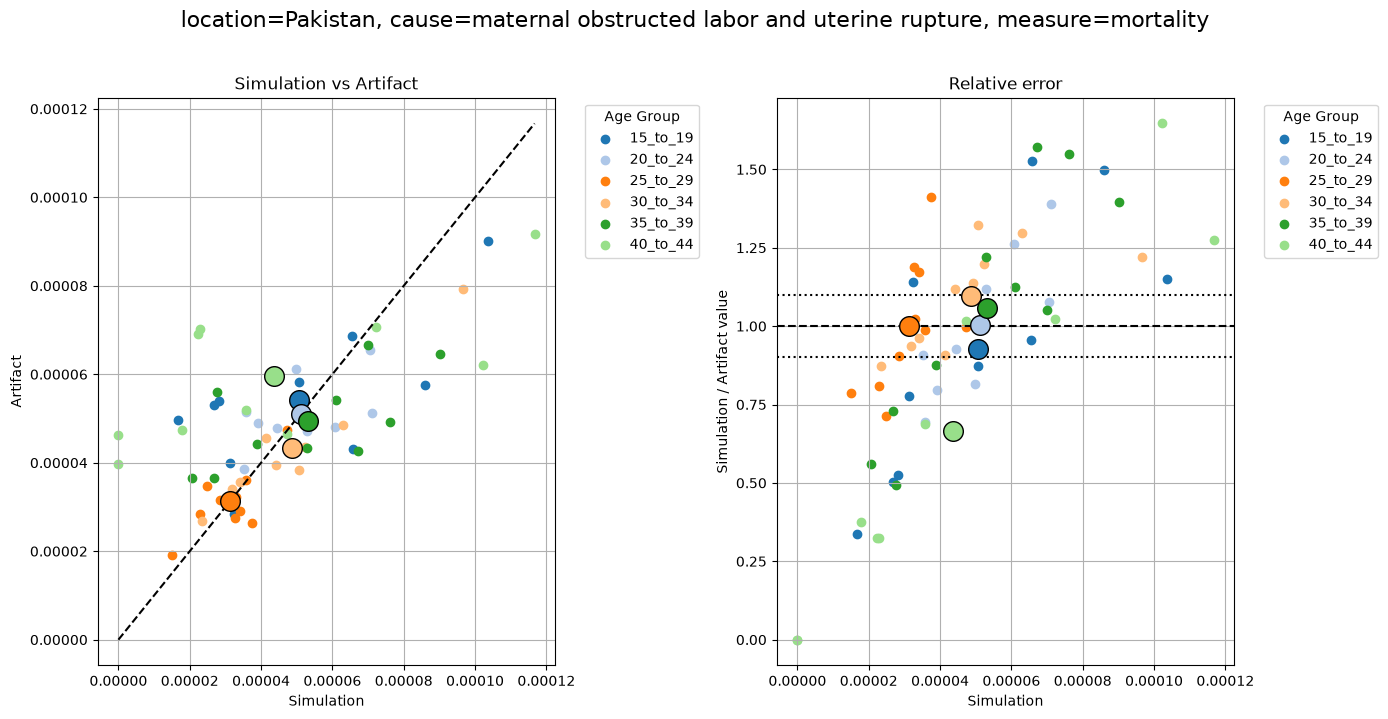

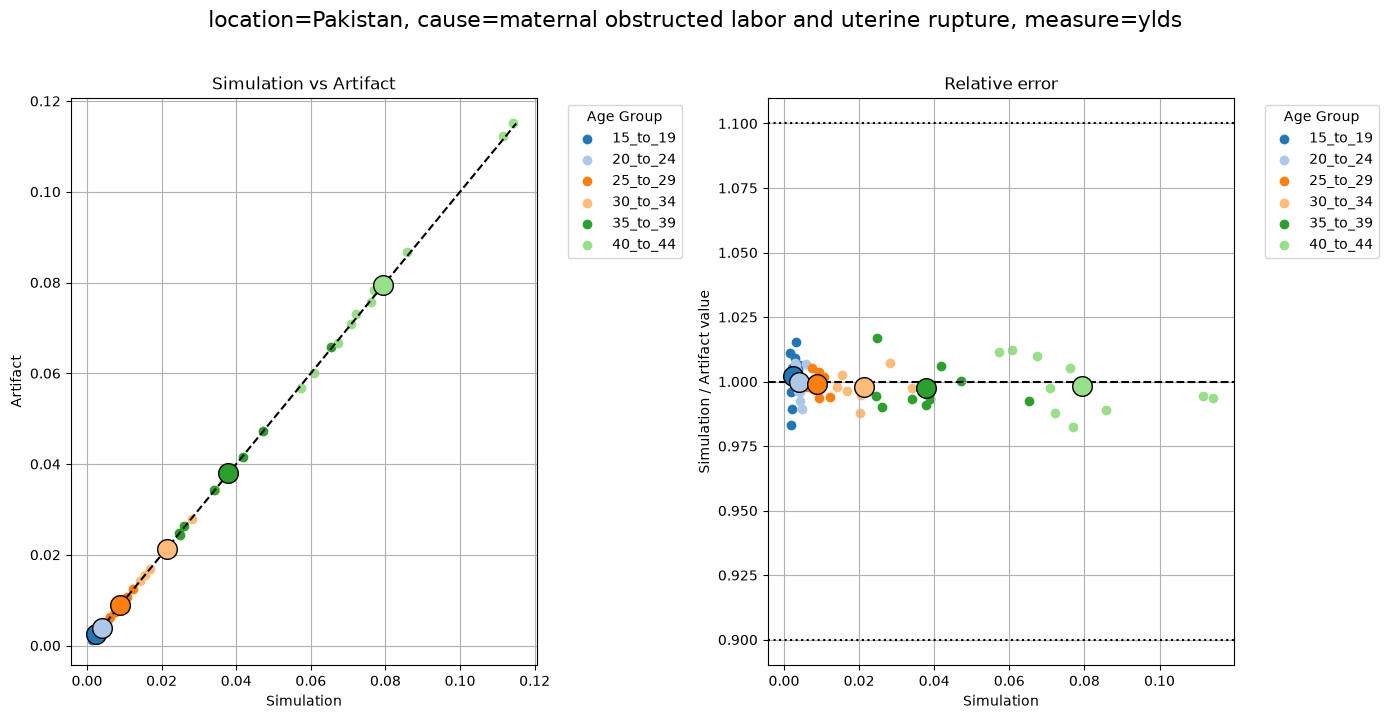

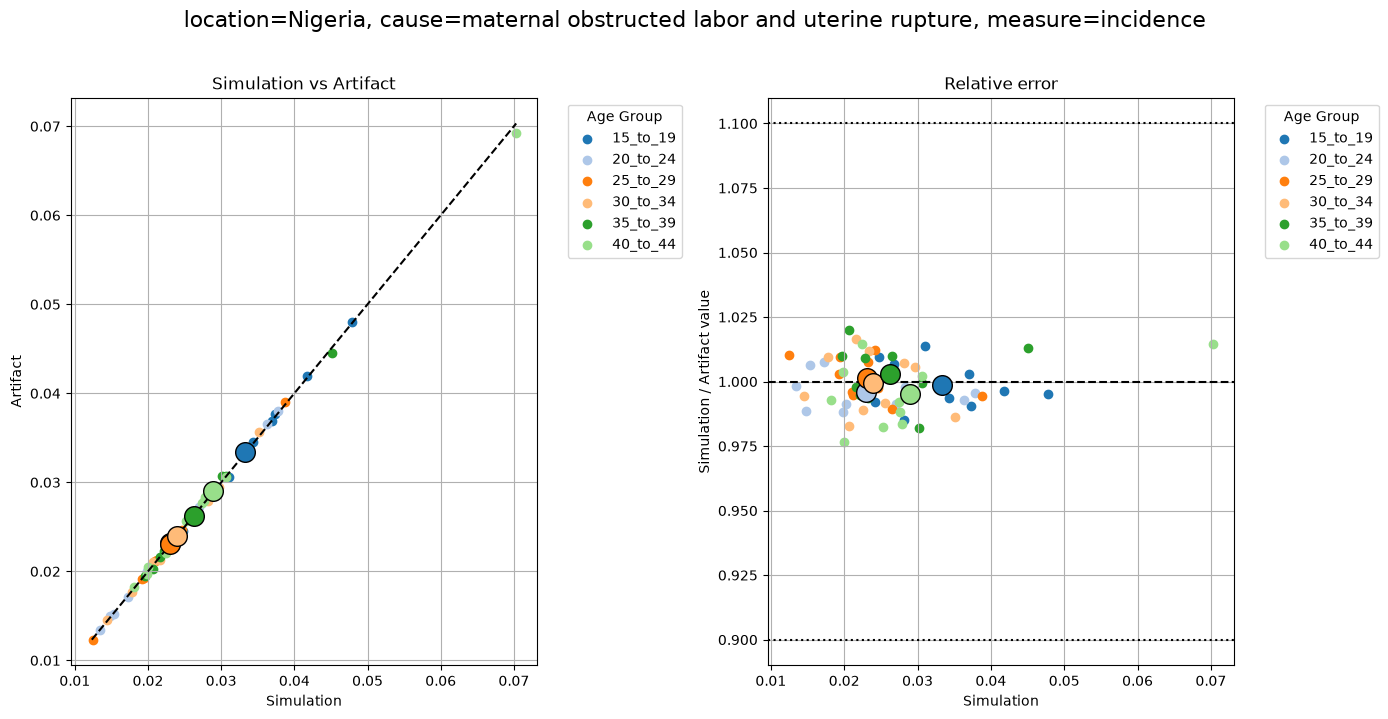

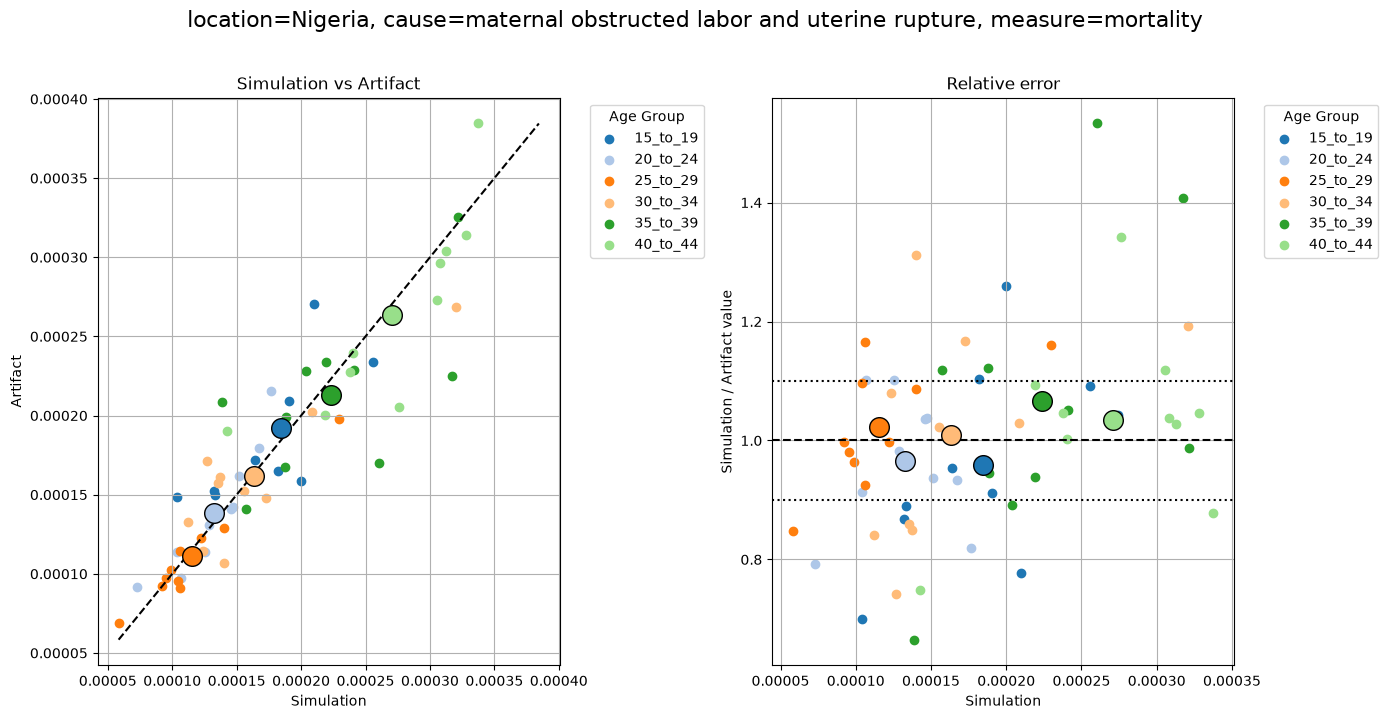

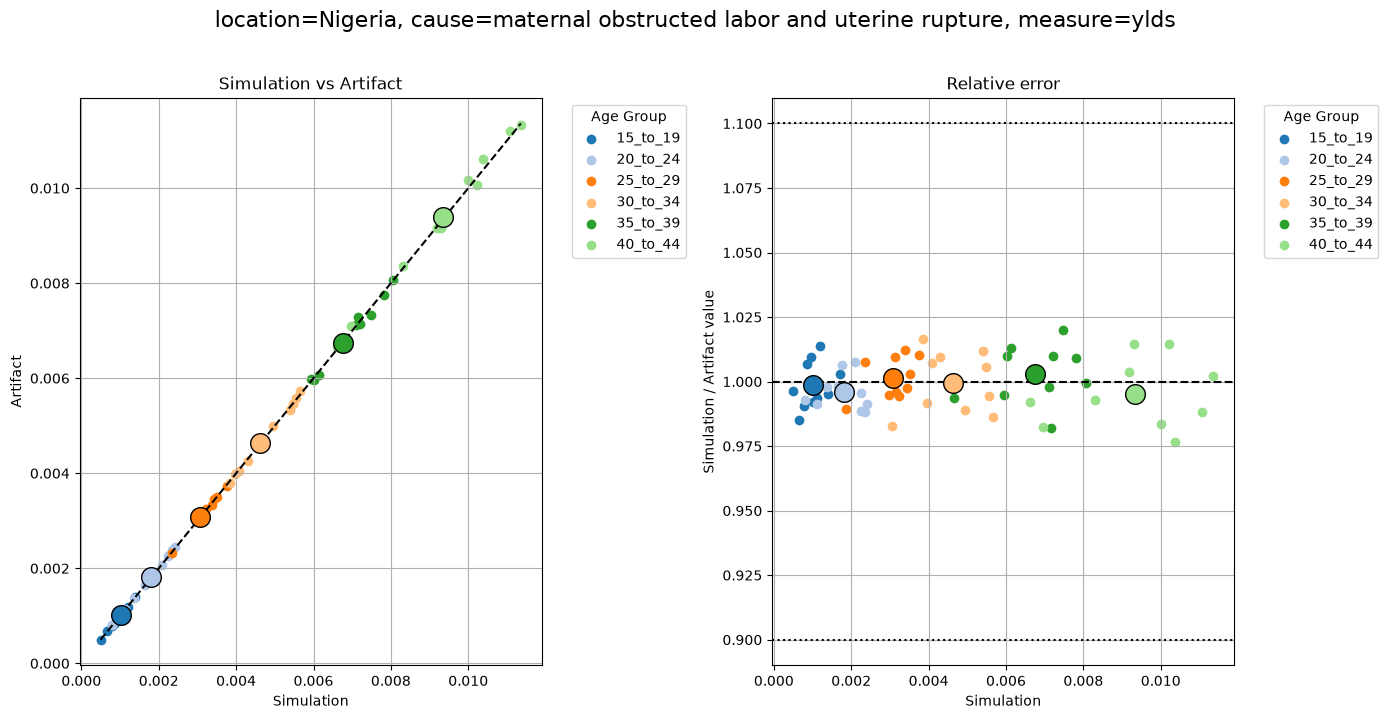

In [47]:
for location in locations:
    for measure in measures:
        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'maternal_obstructed_labor_and_uterine_rupture',
            'measure': measure,
        })

# Looks good, mortality sample size is very very small

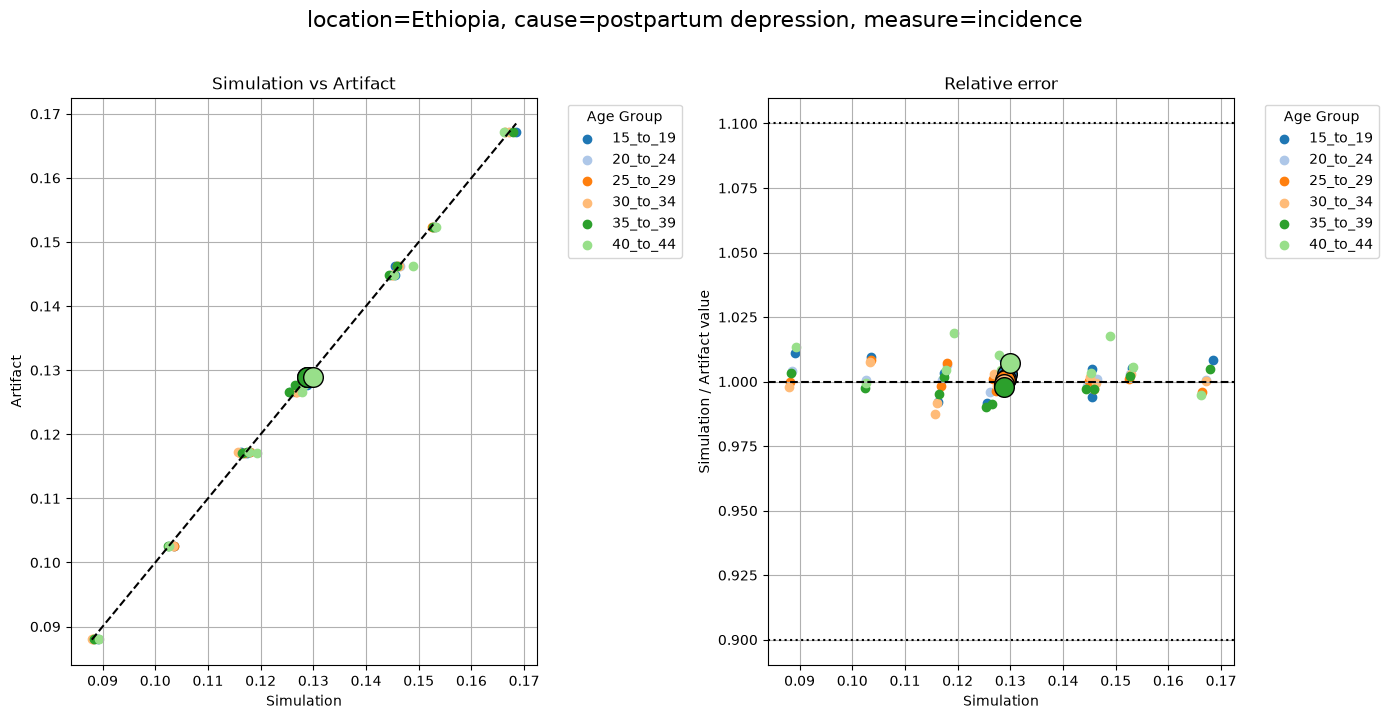

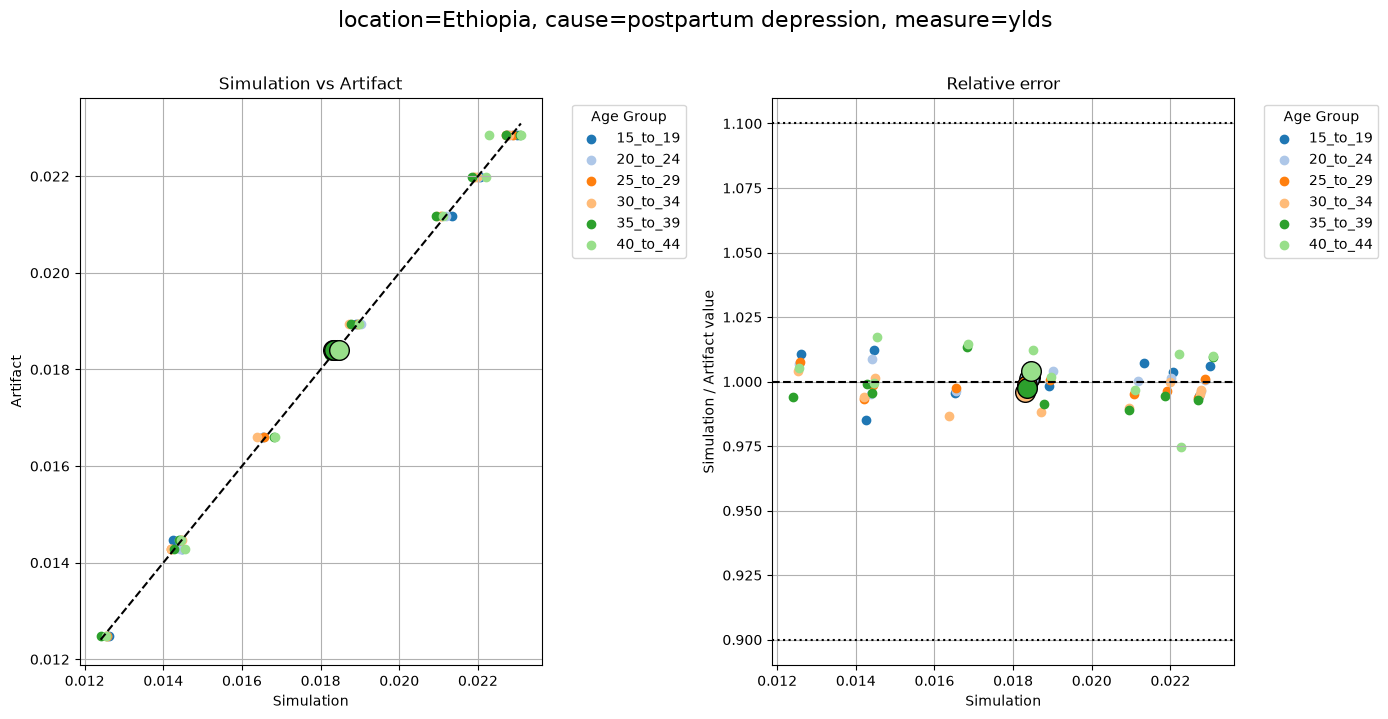

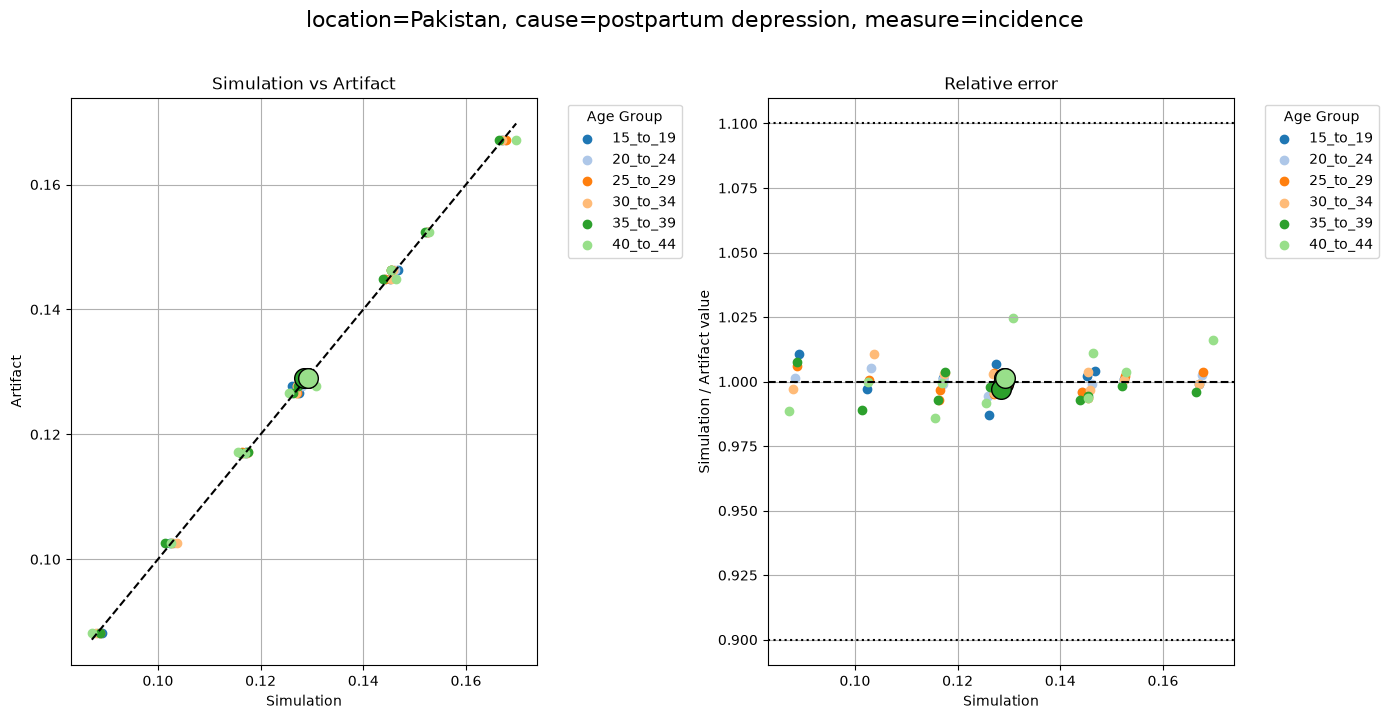

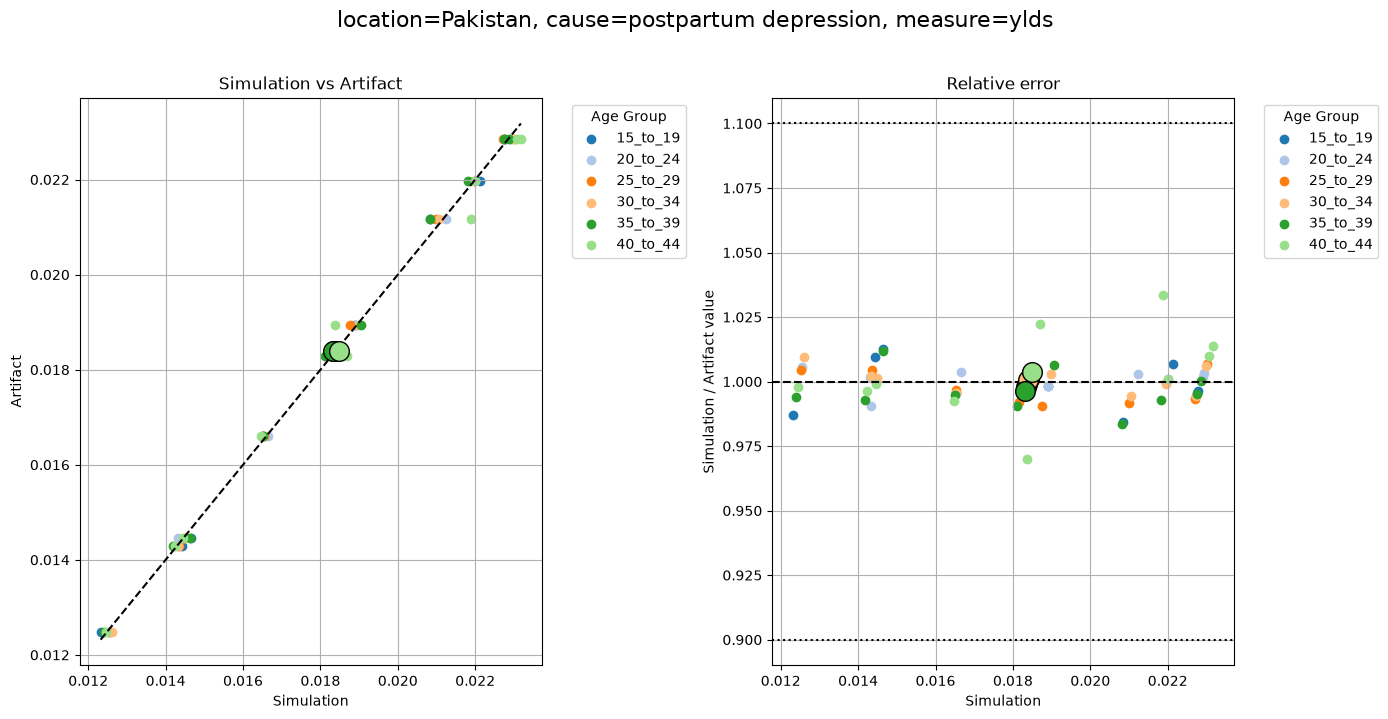

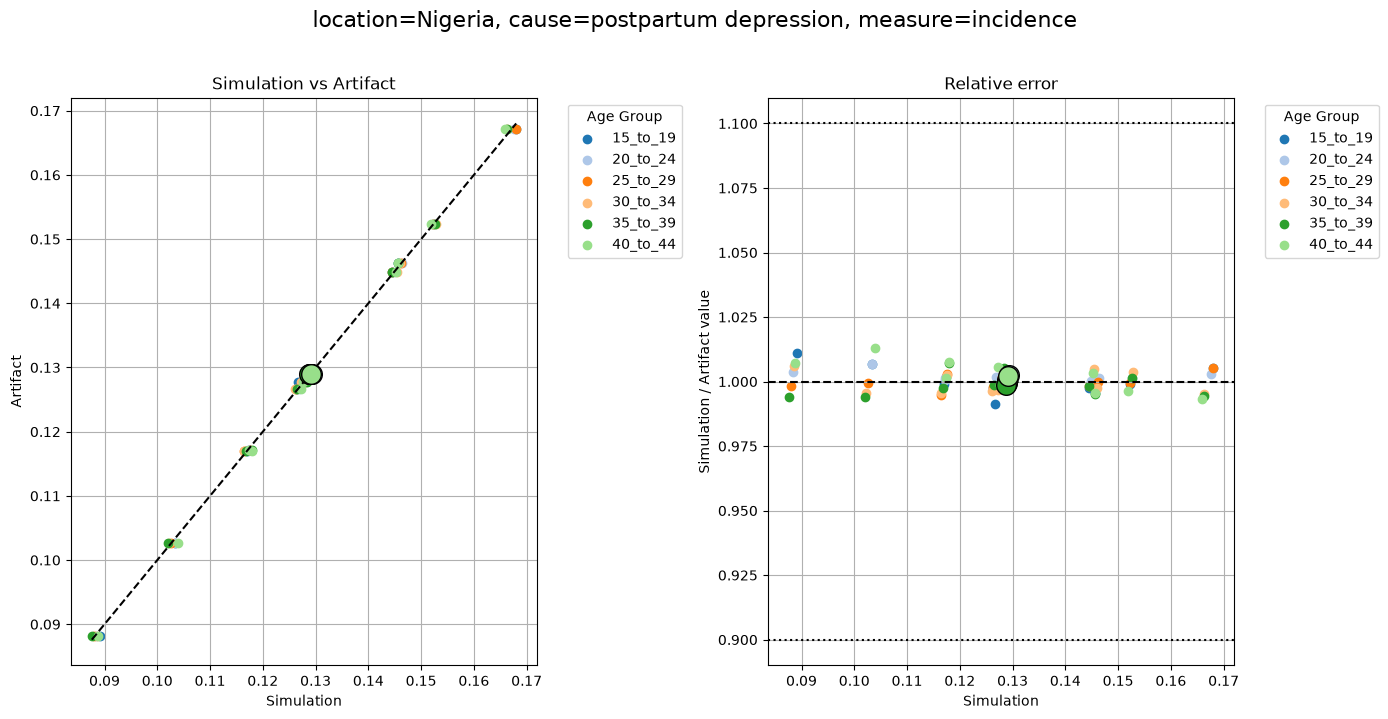

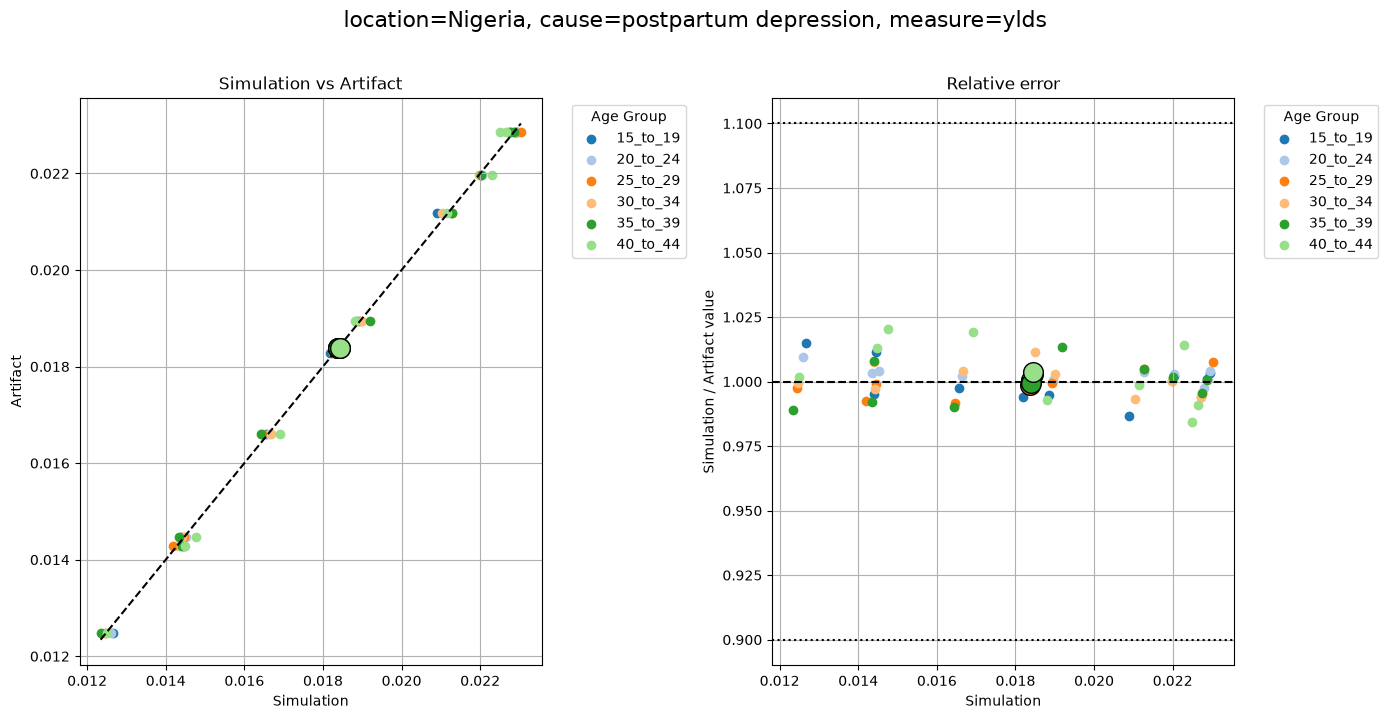

In [48]:
for location in locations:
    for measure in measures:
        if measure == 'mortality':
            continue

        plot_quantitative_comparison(rate_results, artifact_rates_prepped, filters={
            'location': location,
            'cause': 'postpartum_depression',
            'measure': measure,
        })

# Looks good.

## Verify pregnancy outcomes

In [49]:
outcome_fractions = (pregnancies.groupby(groupby_cols + ['pregnancy_outcome'])['value'].sum()
                    / pregnancies.groupby(groupby_cols)['value'].sum()).reset_index()
outcome_fractions = outcome_fractions.dropna().rename(columns={'pregnancy_outcome': 'outcome'})
outcome_fractions['age_start'] = outcome_fractions.age_group.str.split('_to_').str[0].astype(float)
outcome_fractions['age_end'] = outcome_fractions.age_group.str.split('_to_').str[1].astype(float) + 1
outcome_fractions

,location,input_draw,age_group,outcome,value,age_start,age_end
0,Ethiopia,22,10_to_14,stillbirth,0.008995,10.0,15.0
1,Ethiopia,22,10_to_14,live_birth,0.348426,10.0,15.0
2,Ethiopia,22,10_to_14,partial_term,0.642579,10.0,15.0
3,Ethiopia,22,10_to_14,full_term,0.000000,10.0,15.0
4,Ethiopia,22,15_to_19,stillbirth,0.012059,15.0,20.0
...,...,...,...,...,...,...,...
2119,Pakistan,244,45_to_49,full_term,0.000000,45.0,50.0
2120,Pakistan,244,50_to_54,stillbirth,0.022451,50.0,55.0
2121,Pakistan,244,50_to_54,live_birth,0.547330,50.0,55.0
2122,Pakistan,244,50_to_54,partial_term,0.430218,50.0,55.0


In [50]:
artifact_birth_outcomes.columns.name = 'input_draw'

In [51]:
artifact_birth_outcomes_prepped = artifact_birth_outcomes.stack().rename("value").reset_index()
artifact_birth_outcomes_prepped['input_draw'] = artifact_birth_outcomes_prepped.input_draw.str.replace('draw_', '').astype(int)
assert artifact_birth_outcomes_prepped.year_start.nunique() == artifact_birth_outcomes_prepped.year_end.nunique() == 1
assert artifact_birth_outcomes_prepped.sex.nunique() == 1
artifact_birth_outcomes_prepped = artifact_birth_outcomes_prepped.drop(columns=['year_start', 'year_end', 'sex'])
artifact_birth_outcomes_prepped['age_group'] = (
    artifact_birth_outcomes_prepped.age_start.astype(int).astype(str) + '_to_' + (artifact_birth_outcomes_prepped.age_end.astype(int) - 1).astype(str)
)

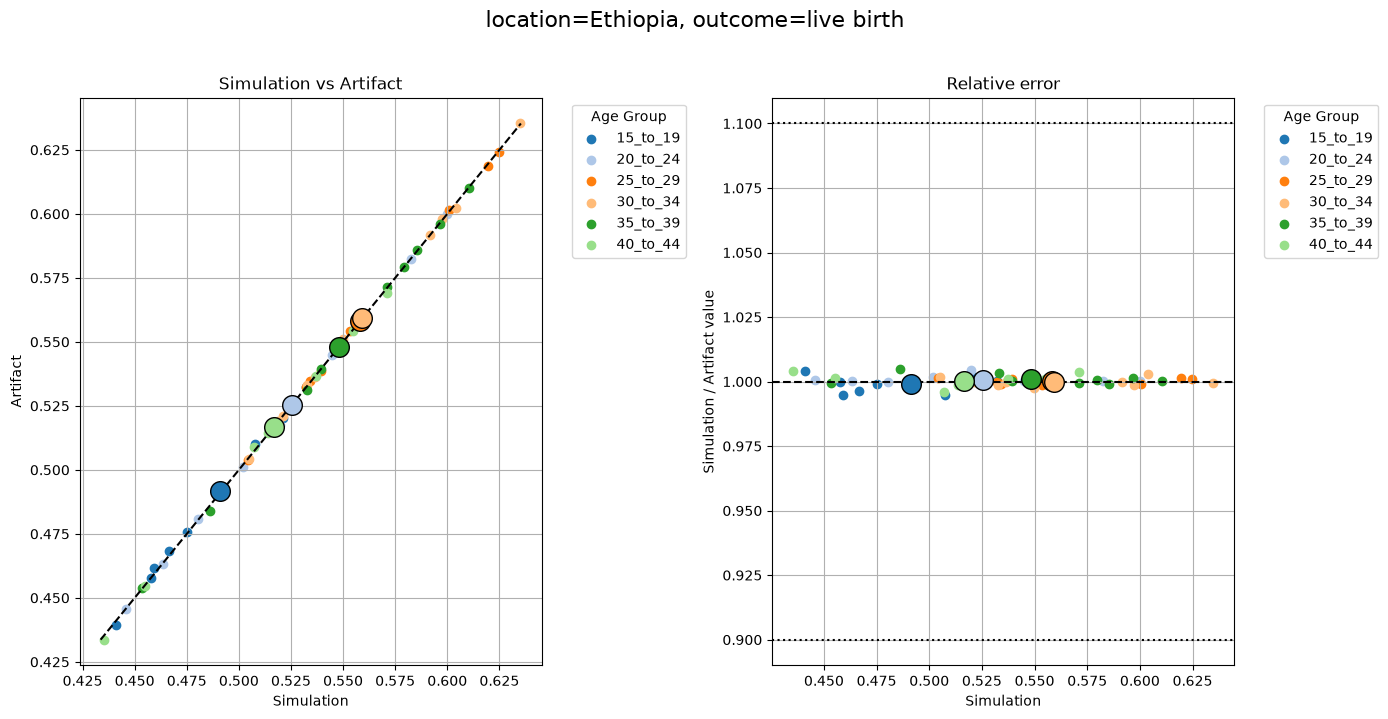

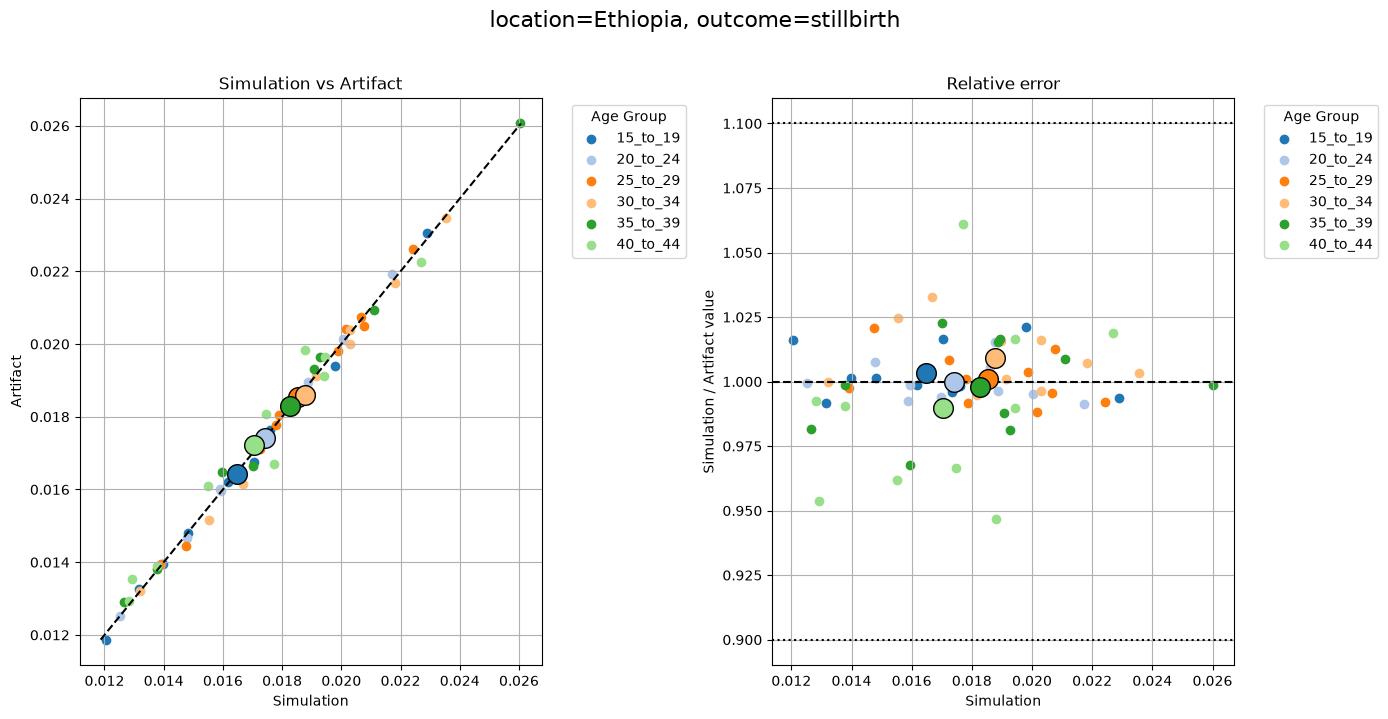

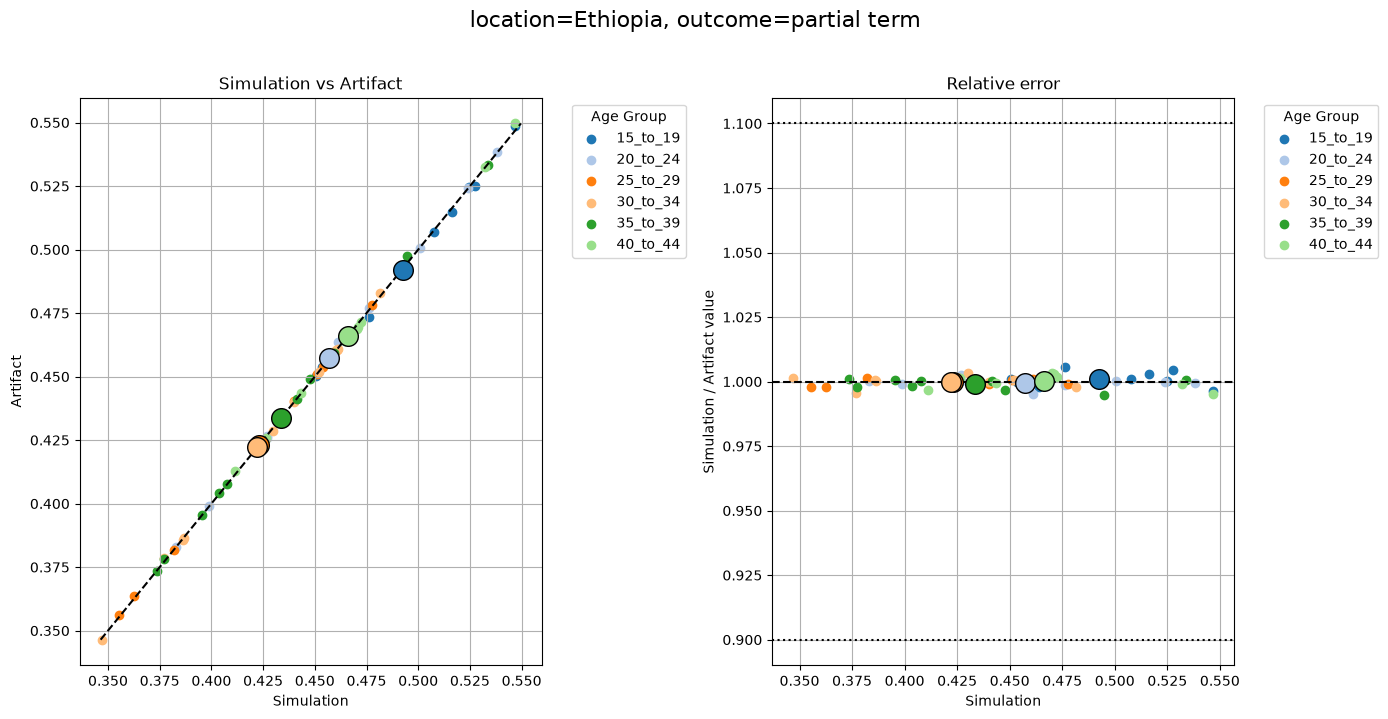

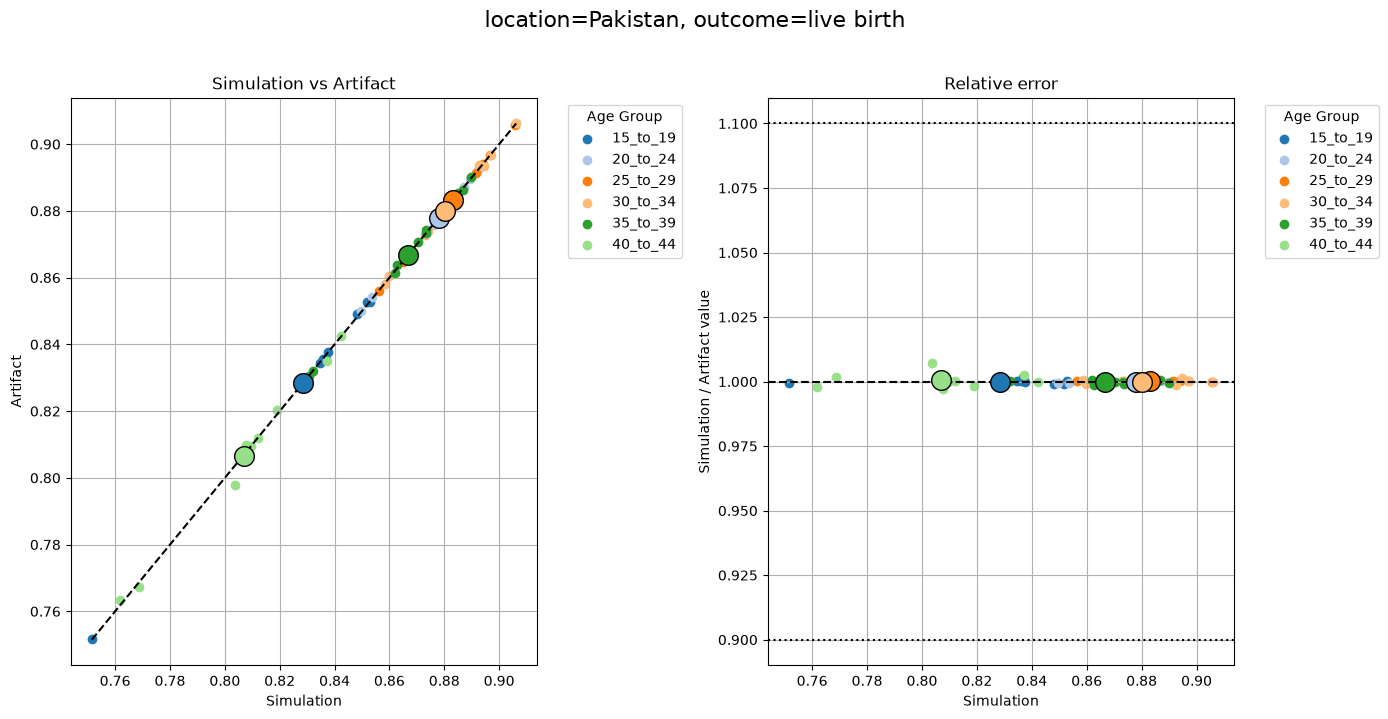

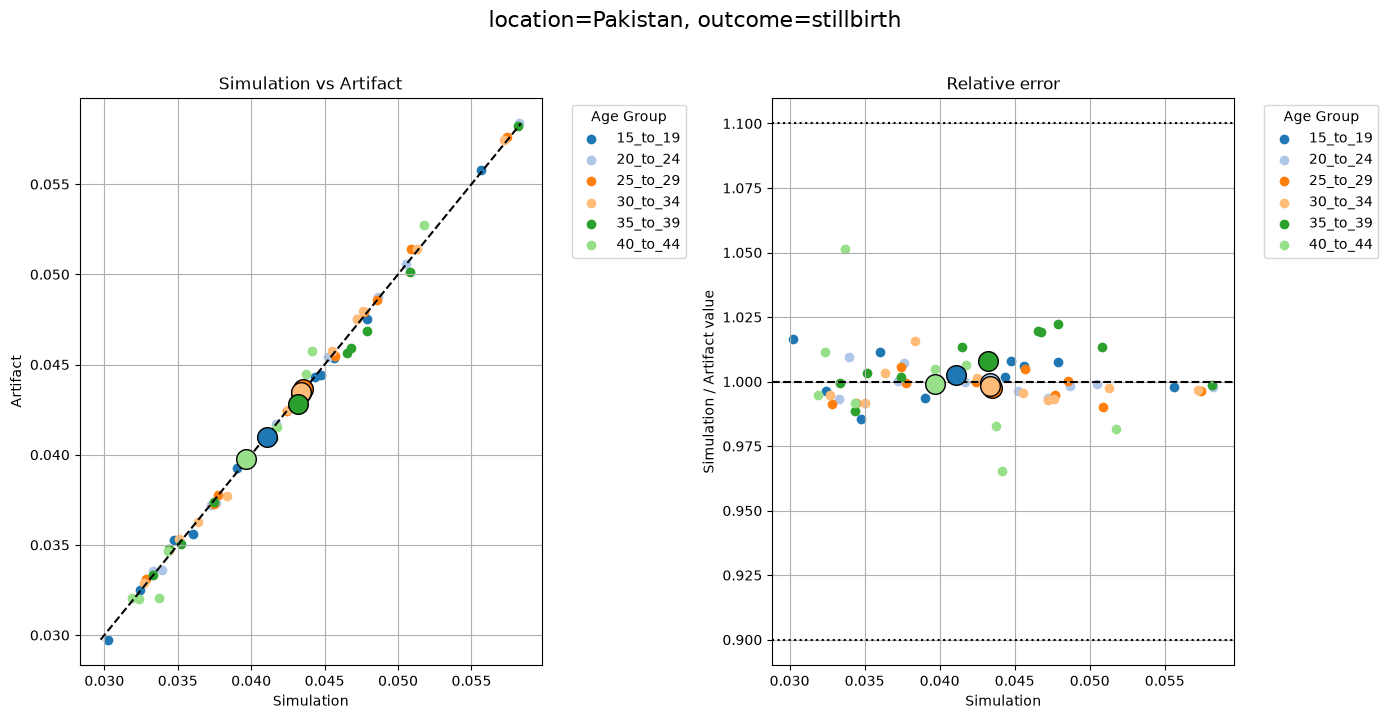

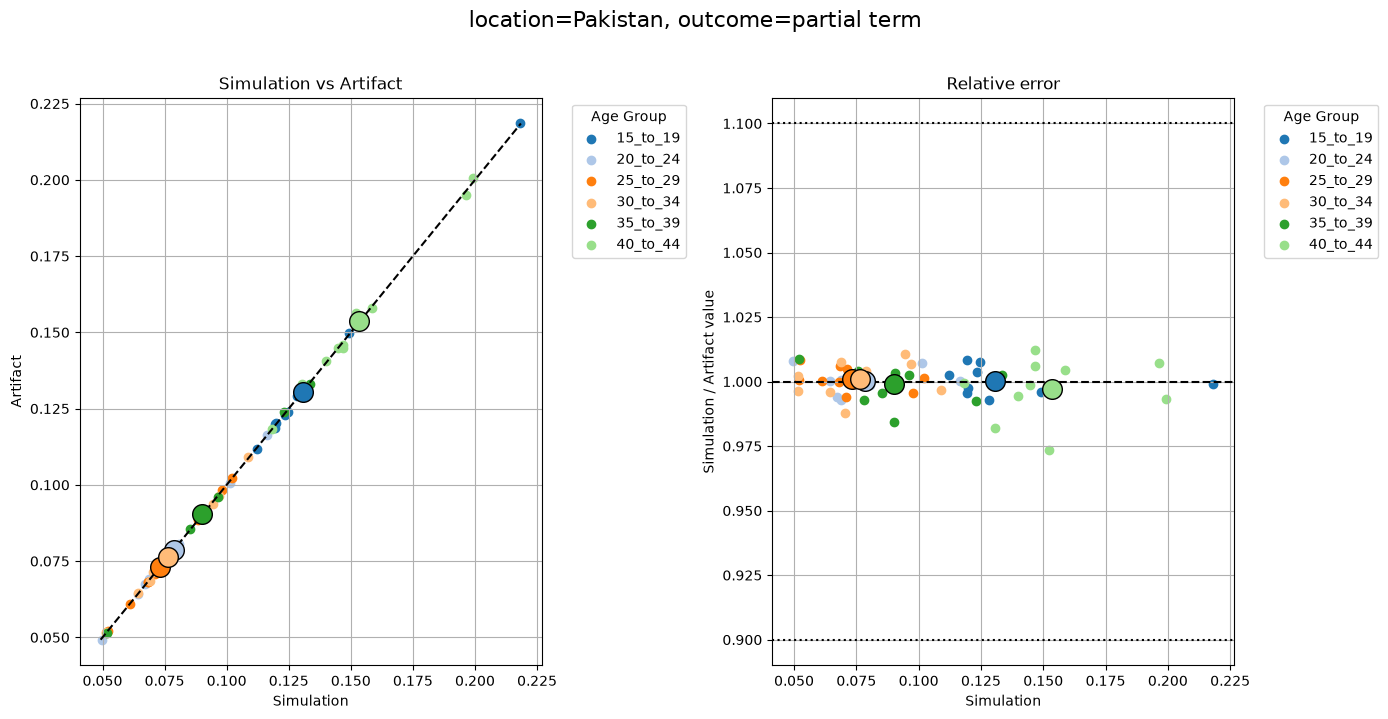

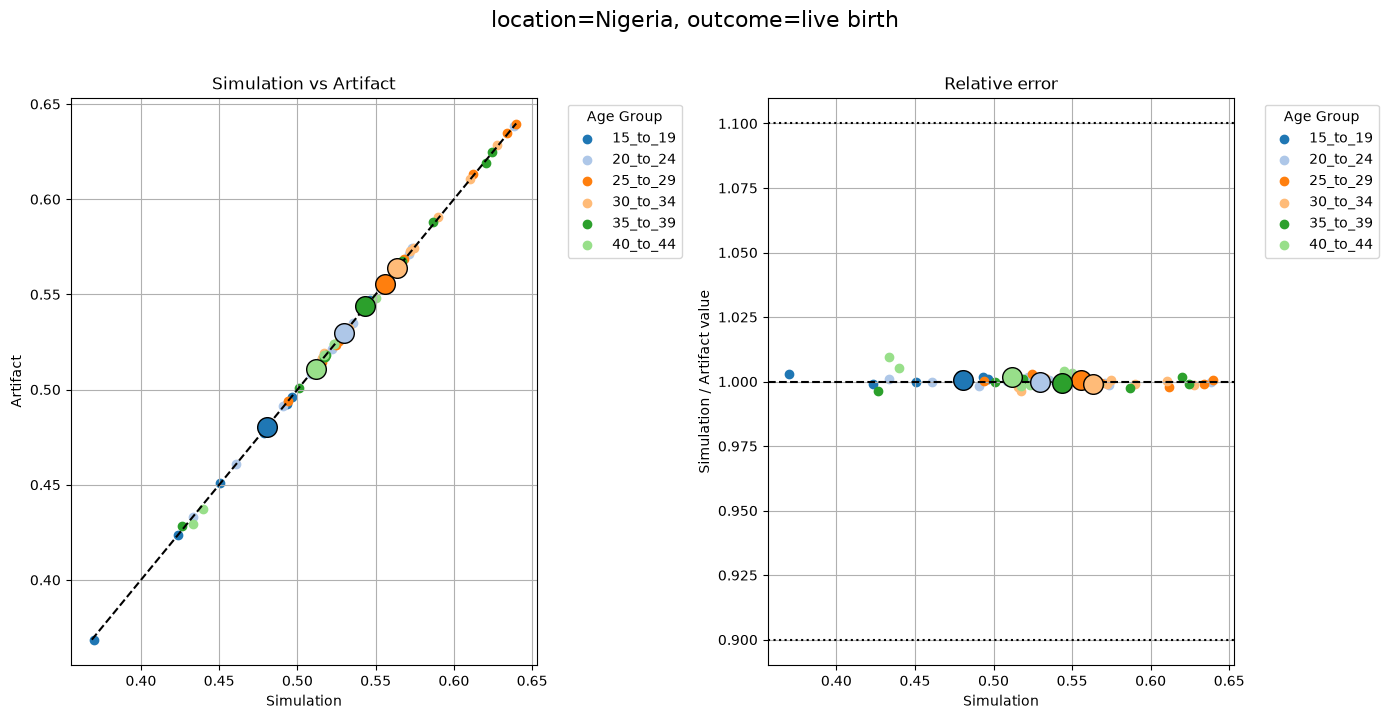

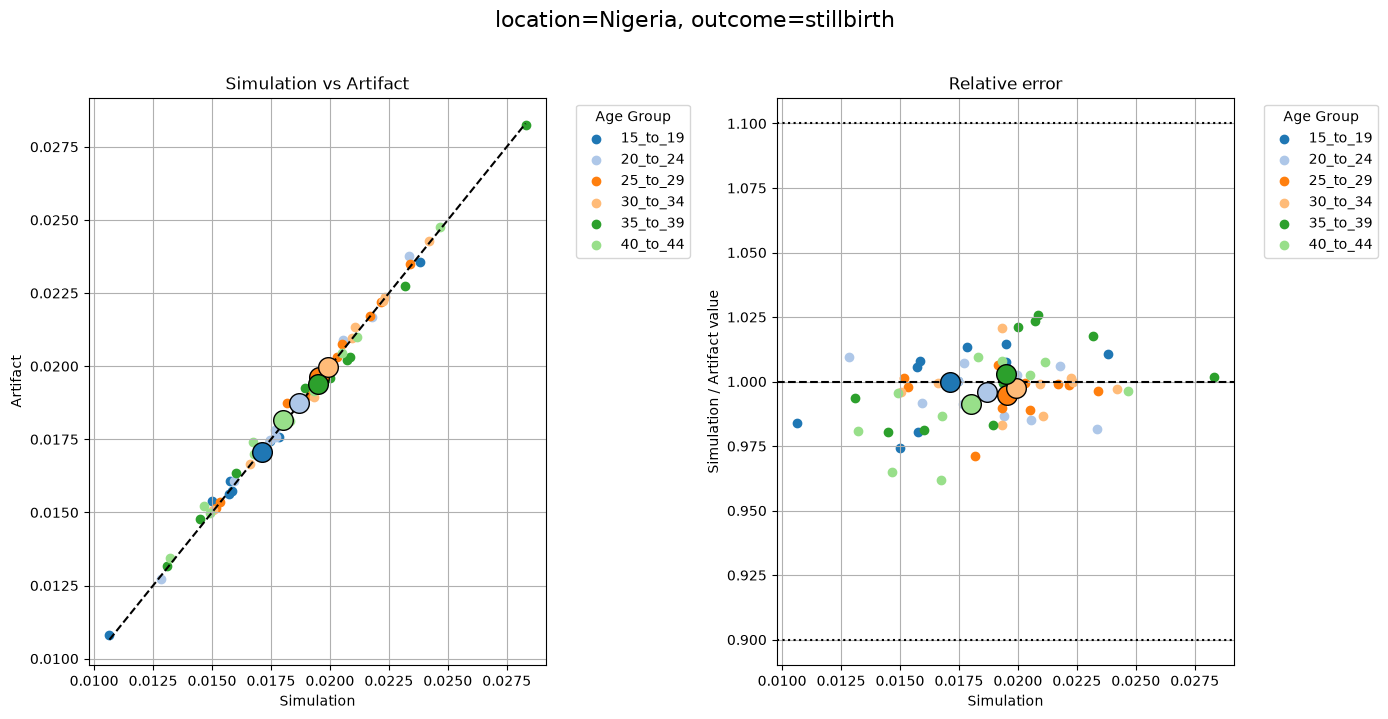

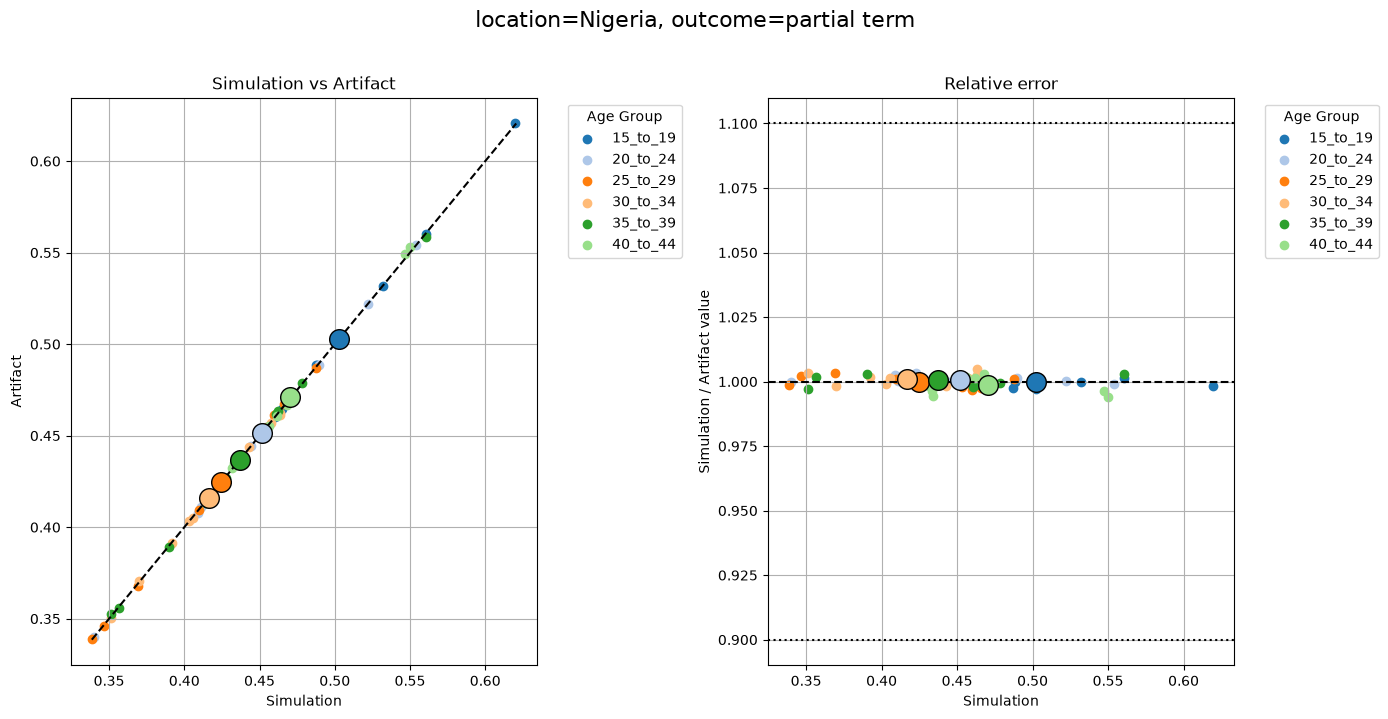

In [52]:
for location in locations:
    for outcome in ['live_birth', 'stillbirth', 'partial_term']:
        plot_quantitative_comparison(
            outcome_fractions,
            artifact_birth_outcomes_prepped,
            filters={
                'location': location,
                'outcome': outcome,
            }
        )
# Still look good

## Verify antenatal care (ANC) coverage vs artifact

In [53]:
# Not age-specific
pregnancies['partial_term'] = pregnancies.pregnancy_outcome == 'partial_term'

anc_groupby_cols = [c for c in groupby_cols if c != 'age_group'] + ['partial_term']
anc_coverage_simulation = (
       (
       pregnancies.groupby(anc_groupby_cols + ['anc_coverage'])['value'].sum()
              / pregnancies.groupby(anc_groupby_cols)['value'].sum()
       )
       #.unstack('input_draw')
       #.pipe(describe_rowwise)
       .reset_index()
)
anc_coverage_simulation

,location,input_draw,partial_term,anc_coverage,value
0,Ethiopia,22,False,none,0.278590
1,Ethiopia,22,False,later_pregnancy_only,0.282464
2,Ethiopia,22,False,first_trimester_only,0.045684
3,Ethiopia,22,False,first_trimester_and_later_pregnancy,0.393262
4,Ethiopia,22,True,none,0.561495
...,...,...,...,...,...
235,Pakistan,244,False,first_trimester_and_later_pregnancy,0.462718
236,Pakistan,244,True,none,0.344052
237,Pakistan,244,True,later_pregnancy_only,0.000000
238,Pakistan,244,True,first_trimester_only,0.655948


In [54]:
anc1_coverage_artifact = (
    read_artifact('covariate.antenatal_care_1_visit_coverage_proportion.estimate')
)
anc4_coverage_artifact = (
    read_artifact('covariate.antenatal_care_4_visits_coverage_proportion.estimate')
)
ancfirst_coverage_artifact = (
    read_artifact('covariate.antenatal_care_first_trimester_visit_coverage_proportion.estimate')
)
anc1_coverage_artifact

,,,draw_22,draw_60,draw_71,draw_79,draw_115,draw_118,draw_146,draw_167,draw_197,draw_244
location,year_start,year_end,,,,,,,,,,
Ethiopia,2023,2024,0.721476,0.752616,0.803045,0.847649,0.714653,0.816801,0.701419,0.775057,0.738209,0.751531
Pakistan,2023,2024,0.901525,0.914489,0.935477,0.954022,0.898684,0.941200,0.893175,0.923830,0.908491,0.914037
Nigeria,2023,2024,0.713920,0.729363,0.754373,0.776495,0.710536,0.761195,0.703973,0.740492,0.722218,0.728825


In [55]:
# so let's check partial term pregnancies first

In [56]:
# make sure no partial term pregnancies attend anc in later pregnancy
assert anc_coverage_simulation.loc[(anc_coverage_simulation.partial_term)
                                   &(anc_coverage_simulation.anc_coverage.isin(['first_trimester_and_later_pregnancy',
                                                                                'later_pregnancy_only']))].value.sum() == 0, "Partial term pregnancies are attending later pregnancy ANC visits"

In [57]:
# now let's check that the rate of ANC visit for first trimester only matches artifact value for ANCfirst
anc_coverage_simulation_partial_term = anc_coverage_simulation[(anc_coverage_simulation.partial_term)
                                                               &(anc_coverage_simulation.anc_coverage == 'first_trimester_only')
                                                               ]
anc_coverage_simulation_partial_term = anc_coverage_simulation_partial_term.groupby('location')['value'].describe(percentiles=[0.025,0.975])
anc_coverage_simulation_partial_term

,count,mean,std,min,2.5%,50%,97.5%,max
location,,,,,,,,
Ethiopia,10.0,0.434230,0.010598,0.408180,0.412137,0.438140,0.444917,0.446406
Nigeria,10.0,0.320759,0.014321,0.293516,0.297934,0.317033,0.343157,0.344791
Pakistan,10.0,0.652804,0.022716,0.622870,0.624177,0.646691,0.687924,0.689185


Text(0, 0.5, 'ANC Coverage')

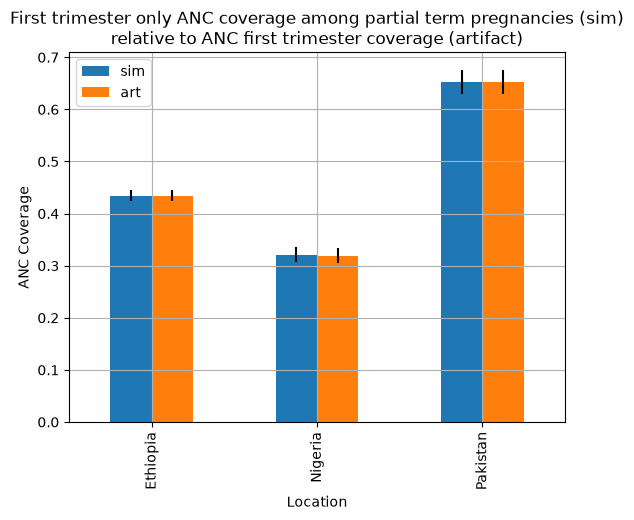

In [58]:
plot_data = anc_coverage_simulation_partial_term.merge(ancfirst_coverage_artifact.pipe(describe_rowwise), on='location', suffixes=('_sim', '_art'))

(
    plot_data[['mean_sim', 'mean_art']]
        .rename(columns=lambda c: c.replace('mean_', ''))
        .plot.bar(yerr=
            plot_data[['std_sim', 'std_art']]
                .rename(columns=lambda c: c.replace('std_', ''))
        )
)
plt.grid()
plt.title('First trimester only ANC coverage among partial term pregnancies (sim)\nrelative to ANC first trimester coverage (artifact)')
plt.xlabel('Location')
plt.ylabel('ANC Coverage')

# Looks good

In [59]:
# great, now let's move on to live and still birth outcomes
anc_coverage_simulation_births = anc_coverage_simulation[(anc_coverage_simulation.partial_term == False)]
anc_coverage_simulation_births = (anc_coverage_simulation_births.groupby([x for x in anc_coverage_simulation_births.columns 
                                                                          if x not in ['value', 'input_draw']])
                                                                          ['value'].describe(percentiles=[0.025,0.975]).reset_index())
anc_coverage_simulation_births

,location,partial_term,anc_coverage,count,mean,std,min,2.5%,50%,97.5%,max
0,Ethiopia,False,none,10.0,0.238100,0.047107,0.153356,0.160267,0.247944,0.295153,0.298150
1,Ethiopia,False,later_pregnancy_only,10.0,0.327467,0.049830,0.256262,0.260407,0.320367,0.400832,0.406840
2,Ethiopia,False,first_trimester_only,10.0,0.017418,0.028552,0.000000,0.000000,0.000000,0.066310,0.067998
3,Ethiopia,False,first_trimester_and_later_pregnancy,10.0,0.417015,0.028561,0.367792,0.369806,0.429712,0.444440,0.445589
4,Nigeria,False,none,10.0,0.265607,0.023507,0.223476,0.226940,0.270256,0.294233,0.295789
5,Nigeria,False,later_pregnancy_only,10.0,0.413557,0.034965,0.370221,0.370747,0.414591,0.465936,0.467363
6,Nigeria,False,first_trimester_only,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Nigeria,False,first_trimester_and_later_pregnancy,10.0,0.320836,0.014261,0.293768,0.298272,0.317205,0.342834,0.344073
8,Pakistan,False,none,10.0,0.081137,0.019509,0.045914,0.048873,0.085093,0.104852,0.106073
9,Pakistan,False,later_pregnancy_only,10.0,0.265695,0.018614,0.240310,0.242047,0.264523,0.298882,0.302345


In [60]:
first_trimester_and_later_pregnancy_target = np.minimum(anc4_coverage_artifact, ancfirst_coverage_artifact)
first_trimester_and_later_pregnancy_target['anc_coverage'] = 'first_trimester_and_later_pregnancy'
first_trimester_only_target = ancfirst_coverage_artifact - first_trimester_and_later_pregnancy_target
first_trimester_only_target['anc_coverage'] = 'first_trimester_only'
later_pregnancy_only_target = anc1_coverage_artifact - ancfirst_coverage_artifact
later_pregnancy_only_target['anc_coverage'] = 'later_pregnancy_only'
none_target = 1 - anc1_coverage_artifact
none_target['anc_coverage'] = 'none'
target_data = pd.concat([first_trimester_and_later_pregnancy_target,
                          first_trimester_only_target,
                          later_pregnancy_only_target,
                          none_target]).reset_index()
target_data = (target_data.set_index([x for x in target_data.columns if 'draw' not in x])
               .pipe(describe_rowwise)
               .reset_index())
target_data

,location,year_start,year_end,anc_coverage,count,mean,std,min,2.5%,50%,97.5%,max
0,Ethiopia,2023,2024,first_trimester_and_later_pregnancy,10.0,0.416892,0.028684,0.367275,0.369376,0.429638,0.444441,0.445711
1,Pakistan,2023,2024,first_trimester_and_later_pregnancy,10.0,0.512125,0.039216,0.455287,0.456545,0.517997,0.565642,0.570510
2,Nigeria,2023,2024,first_trimester_and_later_pregnancy,10.0,0.319203,0.014138,0.292091,0.296565,0.315482,0.340948,0.342361
3,Ethiopia,2023,2024,first_trimester_only,10.0,0.017468,0.028638,0.000000,0.000000,0.000000,0.066477,0.068102
4,Pakistan,2023,2024,first_trimester_only,10.0,0.140263,0.045718,0.089994,0.091152,0.131373,0.225366,0.234167
5,Nigeria,2023,2024,first_trimester_only,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Ethiopia,2023,2024,later_pregnancy_only,10.0,0.327885,0.050445,0.255709,0.259955,0.320240,0.402112,0.408119
7,Pakistan,2023,2024,later_pregnancy_only,10.0,0.266105,0.018895,0.240273,0.242019,0.264863,0.299747,0.303189
8,Nigeria,2023,2024,later_pregnancy_only,10.0,0.414935,0.034963,0.371559,0.372210,0.415812,0.467542,0.469104
9,Ethiopia,2023,2024,none,10.0,0.237754,0.047739,0.152351,0.159292,0.247926,0.295603,0.298581


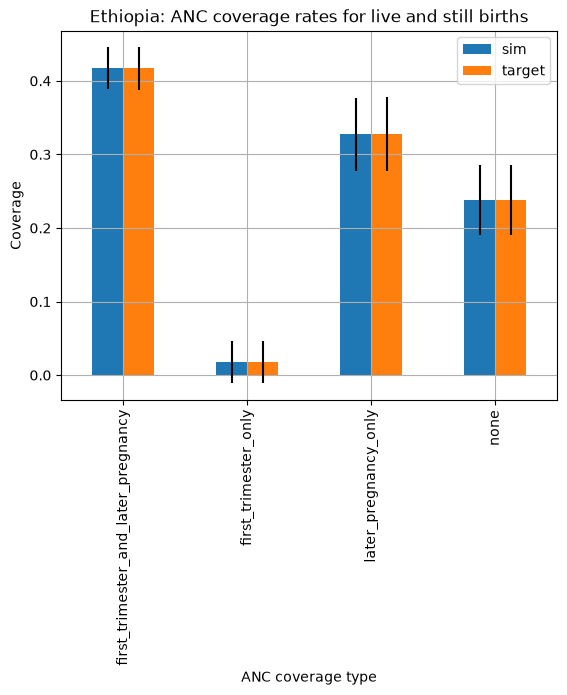

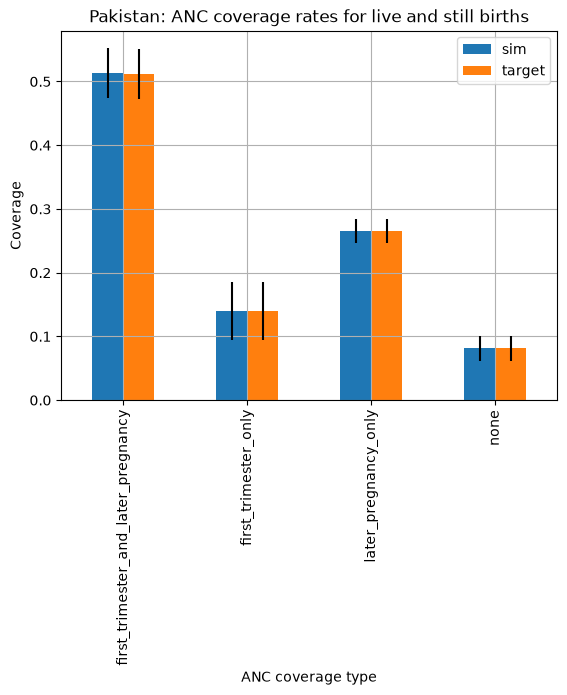

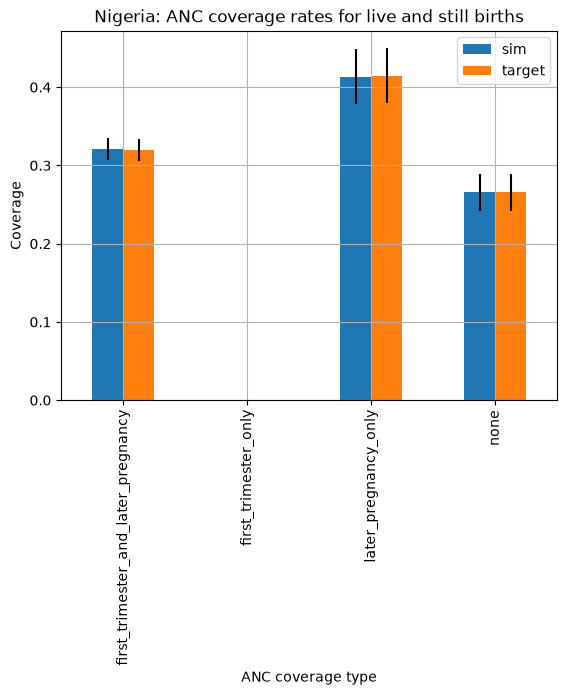

In [61]:
plot_data = target_data.merge(anc_coverage_simulation_births, on=['location','anc_coverage'], suffixes=('_target', '_sim')) 
plot_data = plot_data.set_index('anc_coverage')
for location in locations:
    (
        plot_data.loc[plot_data.location==location][['mean_sim', 'mean_target']]
            .rename(columns=lambda c: c.replace('mean_', ''))
            .plot.bar(yerr=
                plot_data.loc[plot_data.location==location][['std_sim', 'std_target']]
                    .rename(columns=lambda c: c.replace('std_', ''))
            )
    )
    plt.grid()
    plt.title(f'{location}: ANC coverage rates for live and still births')
    plt.xlabel('ANC coverage type')
    plt.ylabel('Coverage')

    # looks great!

## Verify ultrasound coverage vs docs

In [62]:
assert pregnancies[(pregnancies.anc_coverage == 'none') & (pregnancies.ultrasound_type != 'no_ultrasound')]['value'].sum() == 0, "There should be no ultrasound data for non-ANC births"

# Not age-specific
ultrasound_groupby_cols = [c for c in groupby_cols if c != 'age_group']
ultrasound_coverage_sim = (
    (
        pregnancies[pregnancies.anc_coverage != 'none'].groupby(ultrasound_groupby_cols + ['ultrasound_type'])['value'].sum() /
            pregnancies[pregnancies.anc_coverage != 'none'].groupby(ultrasound_groupby_cols)['value'].sum()
    )
        .unstack('input_draw')
        .pipe(describe_rowwise)
        .reset_index()
)
ultrasound_coverage_sim = ultrasound_coverage_sim[(ultrasound_coverage_sim.ultrasound_type != 'no_ultrasound')]
ultrasound_coverage_sim

# looks good
# https://vivarium-research.readthedocs.io/en/latest/models/concept_models/vivarium_mncnh_portfolio/ai_ultrasound_module/module_document.html#id6
# Ethiopia 60.7%, Nigeria 58.7%, Pakistan 66.7%

,location,ultrasound_type,count,mean,std,min,2.5%,50%,97.5%,max
0,Ethiopia,standard,10.0,0.606970,0.000505,0.606422,0.606466,0.606846,0.607919,0.607966
1,Ethiopia,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Nigeria,standard,10.0,0.586975,0.000198,0.586543,0.586591,0.587046,0.587147,0.587150
4,Nigeria,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Pakistan,standard,10.0,0.666917,0.000446,0.666133,0.666212,0.667032,0.667523,0.667545
7,Pakistan,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [63]:
# now let's make sure that that doesn't vary significantly by anc coverage type
    # (so far we are not modeling any differences here)
# Not age-specific
ultrasound_groupby_cols = [c for c in groupby_cols if c != 'age_group'] + ['anc_coverage']
ultrasound_coverage_sim = (
    (
        pregnancies[pregnancies.anc_coverage != 'none'].groupby(ultrasound_groupby_cols + ['ultrasound_type'])['value'].sum() /
            pregnancies[pregnancies.anc_coverage != 'none'].groupby(ultrasound_groupby_cols)['value'].sum()
    )
        .unstack('input_draw')
        .pipe(describe_rowwise)
        .reset_index()
)
ultrasound_coverage_sim = ultrasound_coverage_sim[(ultrasound_coverage_sim.ultrasound_type != 'no_ultrasound')]
ultrasound_coverage_sim
# looks great!

,location,anc_coverage,ultrasound_type,count,mean,std,min,2.5%,50%,97.5%,max
0,Ethiopia,first_trimester_and_later_pregnancy,standard,10.0,0.607124,0.000960,0.605266,0.605492,0.607149,0.608496,0.608531
1,Ethiopia,first_trimester_and_later_pregnancy,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,Ethiopia,first_trimester_only,standard,10.0,0.607007,0.000641,0.605896,0.605931,0.607059,0.607734,0.607779
4,Ethiopia,first_trimester_only,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Ethiopia,later_pregnancy_only,standard,10.0,0.606740,0.000815,0.605190,0.605262,0.606848,0.607610,0.607622
7,Ethiopia,later_pregnancy_only,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Ethiopia,none,standard,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,Ethiopia,none,AI_assisted,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,Nigeria,first_trimester_and_later_pregnancy,standard,10.0,0.587372,0.000758,0.586026,0.586153,0.587460,0.588593,0.588747
13,Nigeria,first_trimester_and_later_pregnancy,AI_assisted,10.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Verify azithromycin and misoprostol coverage vs artifact

In [64]:
assert pregnancies[(pregnancies.misoprostol_availability == True) & (pregnancies.anc_coverage == False)].value.sum() == 0, "Misoprostol coverage is non-zero for those without ANC"
assert pregnancies[(pregnancies.misoprostol_availability == True) & (pregnancies.delivery_facility_type != 'home')].value.sum() == 0, "Misoprostol coverage among non-home births"
assert pregnancies[(pregnancies.azithromycin_availability == True) & (pregnancies.delivery_facility_type.isin(['home', 'none']))].value.sum() == 0, "Azithromycin coverage among home births"

In [65]:
# Not age-specific, but is facility-type-specific
azithromycin_misoprostol_groupby_cols = [c for c in groupby_cols if c != 'age_group'] + ['delivery_facility_type']

azithromycin_misoprostol_coverage_simulation = []

for intervention in ['azithromycin', 'misoprostol']:
    intervention_coverage = (
        pregnancies[pregnancies[f'{intervention}_availability'] == True].groupby(azithromycin_misoprostol_groupby_cols)['value'].sum() /
        pregnancies.groupby(azithromycin_misoprostol_groupby_cols)['value'].sum()
    ).reset_index()
    intervention_coverage['intervention'] = intervention
    azithromycin_misoprostol_coverage_simulation.append(intervention_coverage)

azithromycin_misoprostol_coverage_simulation = pd.concat(azithromycin_misoprostol_coverage_simulation, ignore_index=True)
azithromycin_misoprostol_coverage_simulation

,location,input_draw,delivery_facility_type,value,intervention
0,Ethiopia,22,home,0.0,azithromycin
1,Ethiopia,22,BEmONC,0.0,azithromycin
2,Ethiopia,22,CEmONC,0.0,azithromycin
3,Ethiopia,22,none,0.0,azithromycin
4,Ethiopia,60,home,0.0,azithromycin
...,...,...,...,...,...
235,Pakistan,197,none,0.0,misoprostol
236,Pakistan,244,home,0.0,misoprostol
237,Pakistan,244,BEmONC,0.0,misoprostol
238,Pakistan,244,CEmONC,0.0,misoprostol


In [66]:
# Simulation results contain a 'none' delivery facility type, this should never have any coverage
# Redundant to checks above but it doesn't hurt
assert azithromycin_misoprostol_coverage_simulation[azithromycin_misoprostol_coverage_simulation.delivery_facility_type == 'none'].value.sum() == 0
azithromycin_misoprostol_coverage_simulation = azithromycin_misoprostol_coverage_simulation[azithromycin_misoprostol_coverage_simulation.delivery_facility_type != 'none']

In [67]:
azithromycin_misoprostol_coverage_simulation_summaries = (
    azithromycin_misoprostol_coverage_simulation
        .groupby([x for x in azithromycin_misoprostol_coverage_simulation.columns if x not in ['value', 'input_draw']])
        ['value'].describe(percentiles=[0.025, 0.975])
)
azithromycin_misoprostol_coverage_simulation_summaries

count      mean      std  \
location delivery_facility_type intervention                             
Ethiopia home                   azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         BEmONC                 azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         CEmONC                 azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
Nigeria  home                   azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         BEmONC                 azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         CEmONC                 azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
Pakistan home                   azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         BEmONC                 azithromycin   10.0  0.000000  0.00000   
                                misoprostol    10.0  0.000000  0.00000   
         CEmONC                 azithromycin   10.0  0.204659  0.03725   
                                misoprostol    10.0  0.000000  0.00000   

                                                   min      2.5%       50%  \
location delivery_facility_type intervention                                 
Ethiopia home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Nigeria  home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Pakistan home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.160868  0.161045  0.202671   
                                misoprostol   0.000000  0.000000  0.000000   

                                                 97.5%       max  
location delivery_facility_type intervention                      
Ethiopia home                   azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
         BEmONC                 azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
         CEmONC                 azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
Nigeria  home                   azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
         BEmONC                 azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
         CEmONC                 azithromycin  0.000000  0.000000  
                                misoprostol   0.000000  0.000000  
Pakistan home                   azithromycin  0.000000  0.000000  

In [68]:
# NOTE: Only baseline coverage is in artifact
azithromycin_misoprostol_baseline_coverage_artifact = pd.concat([
    read_artifact(f'intervention.no_{intervention}_risk.probability_{intervention}_{delivery_facility.lower()}', filter_terms=['child_age_start==0'])
        .assign(intervention=intervention, delivery_facility_type=delivery_facility)
        .set_index(['intervention', 'delivery_facility_type'], append=True)
        .reset_index()
    for delivery_facility in ['BEmONC', 'CEmONC', 'home']
    for intervention in ['azithromycin', 'misoprostol']
], ignore_index=True)
azithromycin_misoprostol_baseline_coverage_artifact['scenario'] = 'baseline'
azithromycin_misoprostol_baseline_coverage_artifact

,location,sex,age_start,age_end,year_start,year_end,intervention,delivery_facility_type,draw_22,draw_60,draw_71,draw_79,draw_115,draw_118,draw_146,draw_167,draw_197,draw_244,scenario
0,Ethiopia,Female,0.000000,0.019178,2023.0,2024.0,azithromycin,BEmONC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
1,Ethiopia,Female,0.019178,0.076712,2023.0,2024.0,azithromycin,BEmONC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
2,Ethiopia,Female,0.076712,0.500000,2023.0,2024.0,azithromycin,BEmONC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
3,Ethiopia,Female,0.500000,1.000000,2023.0,2024.0,azithromycin,BEmONC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
4,Ethiopia,Female,1.000000,2.000000,2023.0,2024.0,azithromycin,BEmONC,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,Nigeria,Male,90.000000,95.000000,2023.0,2024.0,azithromycin,home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
455,Nigeria,Male,95.000000,125.000000,2023.0,2024.0,azithromycin,home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
456,Ethiopia,NaN,NaN,NaN,NaN,NaN,misoprostol,home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline
457,Pakistan,NaN,NaN,NaN,NaN,NaN,misoprostol,home,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,baseline


In [69]:
assert (
    azithromycin_misoprostol_baseline_coverage_artifact
        .groupby([c for c in azithromycin_misoprostol_baseline_coverage_artifact.columns if c in azithromycin_misoprostol_groupby_cols] + ['intervention'])
        [[f'draw_{draw}' for draw in draws]]
        .nunique().max().max()
) == 1, "Varying azithromycin or misoprostol coverage rates (by age or sex or year)"

In [70]:
azithromycin_misoprostol_baseline_coverage_artifact = (
    azithromycin_misoprostol_baseline_coverage_artifact
        .groupby([c for c in azithromycin_misoprostol_baseline_coverage_artifact.columns if c in azithromycin_misoprostol_groupby_cols] + ['intervention'])
        [[f'draw_{draw}' for draw in draws]]
        .first()
)
azithromycin_misoprostol_baseline_coverage_artifact

draw_22   draw_60   draw_71  \
location delivery_facility_type intervention                                 
Ethiopia BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Nigeria  BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Pakistan BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.238745  0.246435  0.181109   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   

                                               draw_79  draw_115  draw_118  \
location delivery_facility_type intervention                                 
Ethiopia BEmONC                 azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
         CEmONC                 azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
         home                   azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
Nigeria  BEmONC                 azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
         CEmONC                 azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
         home                   azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
Pakistan BEmONC                 azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   
         CEmONC                 azithromycin  0.160041   0.25227  0.231346   
                                misoprostol   0.000000   0.00000  0.000000   
         home                   azithromycin  0.000000   0.00000  0.000000   
                                misoprostol   0.000000   0.00000  0.000000   

                                              draw_146  draw_167  draw_197  \
location delivery_facility_type intervention                                 
Ethiopia BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Nigeria  BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0

In [71]:
azithromycin_misoprostol_baseline_coverage_artifact_summaries = (
    azithromycin_misoprostol_baseline_coverage_artifact
        .pipe(describe_rowwise)
)
azithromycin_misoprostol_baseline_coverage_artifact_summaries

count      mean       std  \
location delivery_facility_type intervention                              
Ethiopia BEmONC                 azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
         CEmONC                 azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
         home                   azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
Nigeria  BEmONC                 azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
         CEmONC                 azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
         home                   azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
Pakistan BEmONC                 azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   
         CEmONC                 azithromycin   10.0  0.204461  0.037133   
                                misoprostol    10.0  0.000000  0.000000   
         home                   azithromycin   10.0  0.000000  0.000000   
                                misoprostol    10.0  0.000000  0.000000   

                                                   min      2.5%       50%  \
location delivery_facility_type intervention                                 
Ethiopia BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Nigeria  BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
Pakistan BEmONC                 azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   
         CEmONC                 azithromycin  0.160041  0.160465  0.202096   
                                misoprostol   0.000000  0.000000  0.000000   
         home                   azithromycin  0.000000  0.000000  0.000000   
                                misoprostol   0.000000  0.000000  0.000000   

                                                 97.5%      max  
location delivery_facility_type intervention                     
Ethiopia BEmONC                 azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
         CEmONC                 azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
         home                   azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
Nigeria  BEmONC                 azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
         CEmONC                 azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
         home                   azithromycin  0.000000  0.00000  
                                misoprostol   0.000000  0.00000  
Pakistan BEmONC                 azithromycin  0.000000  0.00

azithromycin coverage is 0 at BEmONC in Ethiopia
azithromycin coverage is 0 at CEmONC in Ethiopia
azithromycin coverage is 0 at home in Ethiopia
azithromycin coverage is 0 at BEmONC in Pakistan


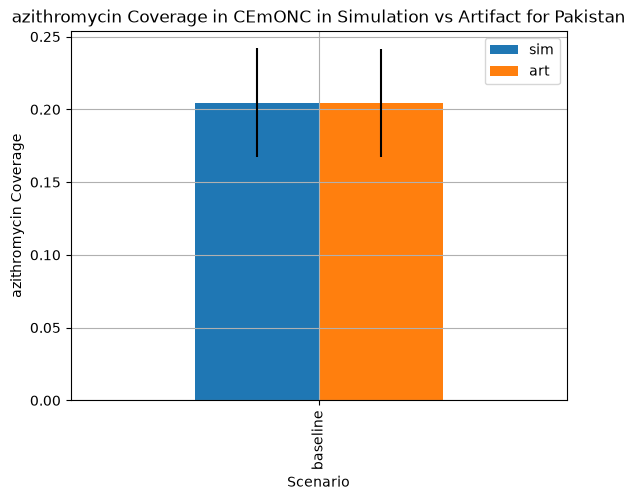

azithromycin coverage is 0 at home in Pakistan
azithromycin coverage is 0 at BEmONC in Nigeria
azithromycin coverage is 0 at CEmONC in Nigeria
azithromycin coverage is 0 at home in Nigeria
misoprostol coverage is 0 at BEmONC in Ethiopia
misoprostol coverage is 0 at CEmONC in Ethiopia
misoprostol coverage is 0 at home in Ethiopia
misoprostol coverage is 0 at BEmONC in Pakistan
misoprostol coverage is 0 at CEmONC in Pakistan
misoprostol coverage is 0 at home in Pakistan
misoprostol coverage is 0 at BEmONC in Nigeria
misoprostol coverage is 0 at CEmONC in Nigeria
misoprostol coverage is 0 at home in Nigeria


In [72]:
all_intervention_plot_data = (
    azithromycin_misoprostol_coverage_simulation_summaries.join(azithromycin_misoprostol_baseline_coverage_artifact_summaries, lsuffix='_sim', rsuffix='_art')
).reset_index()
assert len(all_intervention_plot_data) == len(azithromycin_misoprostol_coverage_simulation_summaries) == len(azithromycin_misoprostol_baseline_coverage_artifact_summaries)

for intervention in ['azithromycin', 'misoprostol']:
    for location in locations:
        for delivery_facility_type in ['BEmONC', 'CEmONC', 'home']:
            try:
                plot_data = all_intervention_plot_data[
                    (all_intervention_plot_data.location == location) &
                    (all_intervention_plot_data.delivery_facility_type == delivery_facility_type) &
                    (all_intervention_plot_data.intervention == intervention)
                ].drop(columns=["location", "delivery_facility_type", "intervention"]).assign(scenario='baseline').set_index('scenario')
            except KeyError:
                continue

            # If coverage should be zero, we can check that exactly (without a plot)
            if (plot_data['max_art'] == 0).all():
                assert (plot_data['max_sim'] == 0).all()
                print(f'{intervention} coverage is 0 at {delivery_facility_type} in {location}')
                continue

            (
                plot_data[['mean_sim', 'mean_art']]
                    .rename(columns=lambda c: c.replace('mean_', ''))
                    .plot.bar(yerr=
                        plot_data[['std_sim', 'std_art']]
                            .rename(columns=lambda c: c.replace('std_', ''))
                    )
            )
            plt.grid()
            plt.title(f'{intervention} Coverage in {delivery_facility_type} in Simulation vs Artifact for {location}')
            plt.xlabel('Scenario')
            plt.ylabel(f'{intervention} Coverage')
            plt.show()

# looks good

## Verify azithromycin and misoprostol coverage and RRs vs docs


In [73]:
births_all_scenarios = read_results('anc_other', baseline_only=False)
births_all_scenarios

,acs_availability,acs_eligibility,age_group,anc_coverage,azithromycin_availability,believed_preterm,delivery_facility_type,misoprostol_availability,pregnancy_outcome,preterm_birth,ultrasound_type,scenario,input_draw,location,value
0,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,anemia_screening_and_iv_iron_scaleup,22,Ethiopia,0.0
1,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,anemia_screening_and_iv_iron_scaleup,60,Ethiopia,0.0
2,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,anemia_screening_and_iv_iron_scaleup,71,Ethiopia,0.0
3,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,anemia_screening_and_iv_iron_scaleup,79,Ethiopia,0.0
4,False,False,10_to_14,none,False,False,home,False,stillbirth,False,standard,anemia_screening_and_iv_iron_scaleup,115,Ethiopia,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46448635,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,mms_total_scaleup,118,Nigeria,0.0
46448636,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,mms_total_scaleup,146,Nigeria,0.0
46448637,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,mms_total_scaleup,167,Nigeria,0.0
46448638,True,True,95_plus,first_trimester_and_later_pregnancy,True,True,none,True,full_term,True,no_ultrasound,mms_total_scaleup,197,Nigeria,0.0


In [74]:
scenarios_run = list(births_all_scenarios.scenario.unique())
scenarios_run

['anemia_screening_and_iv_iron_scaleup',
 'anemia_screening_vv',
 'azithromycin_scaleup',
 'azithromycin_vv',
 'baseline',
 'misoprostol_vv',
 'mms_total_scaleup']

In [75]:
incidence_all_scenarios = combine_count_results_by_cause('incidence', 'counts', baseline_only=False, supercause_only=False)
incidence_all_scenarios

,age_group,azithromycin_availability,delivery_facility_type,misoprostol_availability,pregnancy_outcome,scenario,input_draw,location,value,cause,measure
0,10_to_14,False,home,False,stillbirth,anemia_screening_and_iv_iron_scaleup,22,Ethiopia,11.0,maternal_sepsis_and_other_maternal_infections,incidence
1,10_to_14,False,home,False,stillbirth,anemia_screening_and_iv_iron_scaleup,60,Ethiopia,18.0,maternal_sepsis_and_other_maternal_infections,incidence
2,10_to_14,False,home,False,stillbirth,anemia_screening_and_iv_iron_scaleup,71,Ethiopia,8.0,maternal_sepsis_and_other_maternal_infections,incidence
3,10_to_14,False,home,False,stillbirth,anemia_screening_and_iv_iron_scaleup,79,Ethiopia,14.0,maternal_sepsis_and_other_maternal_infections,incidence
4,10_to_14,False,home,False,stillbirth,anemia_screening_and_iv_iron_scaleup,115,Ethiopia,12.0,maternal_sepsis_and_other_maternal_infections,incidence
...,...,...,...,...,...,...,...,...,...,...,...
1693435,95_plus,True,none,True,full_term,mms_total_scaleup,118,Nigeria,0.0,postpartum_depression,incidence
1693436,95_plus,True,none,True,full_term,mms_total_scaleup,146,Nigeria,0.0,postpartum_depression,incidence
1693437,95_plus,True,none,True,full_term,mms_total_scaleup,167,Nigeria,0.0,postpartum_depression,incidence
1693438,95_plus,True,none,True,full_term,mms_total_scaleup,197,Nigeria,0.0,postpartum_depression,incidence


In [76]:
deaths_all_scenarios = (
    read_results('maternal_disorders_burden_observer_disorder_deaths', baseline_only=False)
        .rename(columns={'maternal_disorders_burden_observer_cause_of_death':'cause'})
)
deaths_all_scenarios

,age_group,azithromycin_availability,delivery_facility_type,cause,misoprostol_availability,pregnancy_outcome,scenario,input_draw,location,value
0,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,anemia_screening_and_iv_iron_scaleup,22,Ethiopia,0.0
1,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,anemia_screening_and_iv_iron_scaleup,60,Ethiopia,0.0
2,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,anemia_screening_and_iv_iron_scaleup,71,Ethiopia,0.0
3,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,anemia_screening_and_iv_iron_scaleup,79,Ethiopia,0.0
4,10_to_14,False,home,maternal_obstructed_labor_and_uterine_rupture,False,stillbirth,anemia_screening_and_iv_iron_scaleup,115,Ethiopia,0.0
...,...,...,...,...,...,...,...,...,...,...
1451515,95_plus,True,none,residual_maternal_disorders,True,full_term,mms_total_scaleup,118,Nigeria,0.0
1451516,95_plus,True,none,residual_maternal_disorders,True,full_term,mms_total_scaleup,146,Nigeria,0.0
1451517,95_plus,True,none,residual_maternal_disorders,True,full_term,mms_total_scaleup,167,Nigeria,0.0
1451518,95_plus,True,none,residual_maternal_disorders,True,full_term,mms_total_scaleup,197,Nigeria,0.0


In [77]:
azithromycin_coverage = (
    births_all_scenarios[births_all_scenarios.azithromycin_availability].groupby(['delivery_facility_type', 'scenario', 'location'])['value'].sum() /
    births_all_scenarios.groupby(['delivery_facility_type', 'scenario', 'location'])['value'].sum()
).dropna()
azithromycin_coverage

delivery_facility_type  scenario                              location
home                    anemia_screening_and_iv_iron_scaleup  Ethiopia    0.0
                                                              Nigeria     0.0
                                                              Pakistan    0.0
                        anemia_screening_vv                   Ethiopia    0.0
                                                              Nigeria     0.0
                                                                         ... 
none                    misoprostol_vv                        Nigeria     0.0
                                                              Pakistan    0.0
                        mms_total_scaleup                     Ethiopia    0.0
                                                              Nigeria     0.0
                                                              Pakistan    0.0
Name: value, Length: 84, dtype: float64

In [78]:
# `.loc[slice('home', 'none')]` on this MultiIndex is a *label range* on the outermost
# (delivery_facility_type) level -- NOT a membership filter. It relies on the index being
# lexsorted and would silently sweep in any facility type sorting between 'home' and 'none'.
# Filter by level membership instead (same idiom as the get_level_values checks below).
non_ifd = azithromycin_coverage.index.get_level_values('delivery_facility_type').isin(['home', 'none'])
assert (azithromycin_coverage.loc[non_ifd] == 0).all(), "azithromycin coverage outside IFD"
azithromycin_coverage = azithromycin_coverage[
    azithromycin_coverage.index.get_level_values('delivery_facility_type').isin(['BEmONC', 'CEmONC'])
]

In [79]:
azithromycin_scaleup_scenarios = ['azithromycin_vv', 'azithromycin_scaleup', 'full_product_scaleup']

In [80]:
# https://vivarium-research.readthedocs.io/en/latest/models/intervention_models/intrapartum/azithromycin_intervention.html#baseline-coverage-data
assert (azithromycin_coverage[
    ~azithromycin_coverage.index.get_level_values('scenario').isin(azithromycin_scaleup_scenarios)
    & (azithromycin_coverage.index.get_level_values('delivery_facility_type') != 'CEmONC')
    & (azithromycin_coverage.index.get_level_values('location') != 'Pakistan')
] == 0).all(), "baseline coverage outside Pakistan CEmONC"

In [81]:
# https://vivarium-research.readthedocs.io/en/latest/models/intervention_models/intrapartum/azithromycin_intervention.html#baseline-coverage-data
# Not guaranteed to be exactly the same across scenarios because IFD (and therefore eligibility) can change
# But all scenarios should be close to target of 20.3, and they are
azithromycin_coverage[
    ~azithromycin_coverage.index.get_level_values('scenario').isin(azithromycin_scaleup_scenarios)
].loc[('CEmONC', slice(None), 'Pakistan')]

scenario
anemia_screening_and_iv_iron_scaleup    0.203567
anemia_screening_vv                     0.203567
baseline                                0.203567
misoprostol_vv                          0.203567
mms_total_scaleup                       0.203568
Name: value, dtype: float64

In [82]:
if 'azithromycin_scaleup' in scenarios_run:
    # https://vivarium-research.readthedocs.io/en/latest/models/concept_models/vivarium_mncnh_portfolio/concept_model.html#id17
    assert (azithromycin_coverage.loc[(slice(None), 'azithromycin_scaleup')] == 1).all(), "azithromycin not fully scaled up in scale up scenario"

In [83]:
if 'azithromycin_vv' in scenarios_run:
    # Target is 50%, this looks close
    display(azithromycin_coverage.loc[(slice(None), 'azithromycin_vv')])

delivery_facility_type  location
BEmONC                  Ethiopia    0.499792
                        Nigeria     0.499655
                        Pakistan    0.500063
CEmONC                  Ethiopia    0.499784
                        Nigeria     0.500050
                        Pakistan    0.500224
Name: value, dtype: float64

In [84]:
def calculate_incidence_and_deaths_rrs(intervention, confounders=(), baseline_coverage_confounders=()):
    print(intervention)
    for outcome, outcome_df in [('incidence', incidence_all_scenarios), ('deaths', deaths_all_scenarios)]:
        # TODO: Could compare these RRs at the draw level vs artifact
        print(outcome)

        if f'{intervention}_vv' in scenarios_run:
            print('Cross-simulant comparison: compare people with and without, in the V&V scenario')
            outcome_events_in_scenario = outcome_df.loc[
                (outcome_df.scenario == f'{intervention}_vv')
            ]
            births_in_scenario = births_all_scenarios.loc[
                (births_all_scenarios.scenario == f'{intervention}_vv') &
                (births_all_scenarios.pregnancy_outcome != 'partial_term')
            ]
            outcome_risk_by_intervention = (
                outcome_events_in_scenario.groupby([f'{intervention}_availability'] + list(confounders) + ['input_draw', 'location', 'cause'])['value'].sum()
                /
                births_in_scenario.groupby([f'{intervention}_availability'] + list(confounders) + ['input_draw', 'location'])['value'].sum()
            ).dropna()
            relative_risk = (outcome_risk_by_intervention.loc[(True,)] / outcome_risk_by_intervention.loc[(False,)]).replace(np.inf, np.nan).dropna()
            display(relative_risk.sort_values())
            display(relative_risk.groupby(['cause']).describe(percentiles=[0.025,0.975]))
        else:
            print(f'Cannot do cross-simulant comparison because {intervention} V&V scenario was not run')

        if f'{intervention}_scaleup' in scenarios_run:
            print('Cross-scenario comparison: compare those eligible, between baseline and scale-up scenario')
            outcome_events_by_scenario = outcome_df.loc[
                (outcome_df.scenario.isin(['baseline', f'{intervention}_scaleup']))
            ].groupby(['scenario'] + list(baseline_coverage_confounders) + ['input_draw', 'location', 'cause'])['value'].sum()
            births_by_scenario = births_all_scenarios.loc[
                (births_all_scenarios.scenario.isin(['baseline', f'{intervention}_scaleup'])) &
                (births_all_scenarios.pregnancy_outcome != 'partial_term')
            ].groupby(['scenario'] + list(baseline_coverage_confounders) + ['input_draw', 'location'])['value'].sum()
            assert (births_by_scenario.loc['baseline'] == births_by_scenario.loc[f'{intervention}_scaleup']).all(), "intervention scaleup changed number of births"
            births_for_coverage = births_all_scenarios.loc[
                (births_all_scenarios.scenario.isin(['baseline', f'{intervention}_scaleup'])) &
                (births_all_scenarios.pregnancy_outcome != 'partial_term')
            ]
            coverage_by_scenario = (
                births_for_coverage.loc[births_for_coverage[f'{intervention}_availability']]
                    .groupby(['scenario'] + list(baseline_coverage_confounders) + ['input_draw', 'location'])['value'].sum()
                /
                births_for_coverage
                    .groupby(['scenario'] + list(baseline_coverage_confounders) + ['input_draw', 'location'])['value'].sum()
            ).dropna()
            if (coverage_by_scenario.loc['baseline'] > 0).any():
                print('Scaled up from')
                display(coverage_by_scenario.loc['baseline'].sort_values())
                display(coverage_by_scenario.loc['baseline'].groupby(['location'] + list(baseline_coverage_confounders)).describe(percentiles=[0.025,0.975]))
            else:
                assert len(baseline_coverage_confounders) == 0

            assert (
                (coverage_by_scenario.loc[f'{intervention}_scaleup'] == coverage_by_scenario.loc['baseline']) |
                (coverage_by_scenario.loc[f'{intervention}_scaleup'] == 1)
            ).all()
            scaled_up_index = (coverage_by_scenario.loc[f'{intervention}_scaleup'] != coverage_by_scenario.loc['baseline']).pipe(lambda s: s.index[s])

            relative_risk = (
                outcome_events_by_scenario.loc[f'{intervention}_scaleup'].pipe(lambda s: s[s.index.droplevel('cause').isin(scaled_up_index)])
                /
                outcome_events_by_scenario.loc['baseline'].pipe(lambda s: s[s.index.droplevel('cause').isin(scaled_up_index)])
            ).replace(np.inf, np.nan).dropna()
            print('Observed RRs')
            display(relative_risk.sort_values())
            display(relative_risk.groupby(['cause'] + list(baseline_coverage_confounders)).describe(percentiles=[0.025,0.975]))
        else:
            print(f'Cannot do cross-scenario comparison because {intervention} scale-up scenario was not run')

In [85]:
# Target is 0.65 (95% CI 0.55-0.77) on maternal sepsis
# https://vivarium-research.readthedocs.io/en/latest/models/intervention_models/intrapartum/azithromycin_intervention.html#id13

# Confounded by delivery facility -- it affects azithromycin availability, but is also correlated
# with ANC which increases hemoglobin (through IFA)
# Unfortunately having this confounder means we don't have good sample size/power for deaths
calculate_incidence_and_deaths_rrs(
    'azithromycin',
    confounders=['delivery_facility_type'],
    # Baseline coverage in Pakistan is specific to CEmONC
    baseline_coverage_confounders=['delivery_facility_type'],
)

# It seems like we are slightly underestimating the impact, based on the incidence results
# but deaths look better?
# Maybe just stochastic noise

azithromycin
incidence
Cross-simulant comparison: compare people with and without, in the V&V scenario


delivery_facility_type  input_draw  location  cause                                        
CEmONC                  79          Ethiopia  maternal_sepsis_and_other_maternal_infections    0.614036
                        115         Pakistan  maternal_sepsis_and_other_maternal_infections    0.614975
BEmONC                  79          Pakistan  maternal_sepsis_and_other_maternal_infections    0.617916
CEmONC                  79          Pakistan  maternal_sepsis_and_other_maternal_infections    0.620610
BEmONC                  79          Ethiopia  maternal_sepsis_and_other_maternal_infections    0.621268
                                                                                                 ...   
                        244         Nigeria   antepartum_hemorrhage                            1.043732
                        22          Nigeria   postpartum_hemorrhage                            1.045517
CEmONC                  71          Pakistan  postpartum_hemorrhage         

,count,mean,std,min,2.5%,50%,97.5%,max
cause,,,,,,,,
antepartum_hemorrhage,60.0,1.001900,0.016589,0.972170,0.976561,0.999091,1.042489,1.048869
maternal_hemorrhage,60.0,1.000952,0.013953,0.965582,0.979400,0.999048,1.030266,1.043628
maternal_obstructed_labor_and_uterine_rupture,60.0,0.998370,0.012396,0.968862,0.974957,0.998942,1.022120,1.033515
maternal_sepsis_and_other_maternal_infections,60.0,0.694530,0.043116,0.614036,0.616372,0.700076,0.764585,0.784044
postpartum_depression,60.0,0.998543,0.009512,0.975813,0.979744,0.998430,1.017155,1.024677
postpartum_hemorrhage,60.0,1.000402,0.019140,0.953027,0.968389,0.999522,1.045525,1.051690


Cross-scenario comparison: compare those eligible, between baseline and scale-up scenario


Scaled up from


...

delivery_facility_type  input_draw  location
BEmONC                  146         Pakistan    0.000000
CEmONC                  22          Ethiopia    0.000000
BEmONC                  244         Pakistan    0.000000
                                    Nigeria     0.000000
                                    Ethiopia    0.000000
                                                  ...   
CEmONC                  197         Pakistan    0.223781
                        118         Pakistan    0.231846
                        22          Pakistan    0.238410
                        60          Pakistan    0.246894
                        115         Pakistan    0.252587
Name: value, Length: 90, dtype: float64

count      mean      std       min      2.5%  \
location delivery_facility_type                                                 
Ethiopia home                     10.0  0.000000  0.00000  0.000000  0.000000   
         BEmONC                   10.0  0.000000  0.00000  0.000000  0.000000   
         CEmONC                   10.0  0.000000  0.00000  0.000000  0.000000   
Nigeria  home                     10.0  0.000000  0.00000  0.000000  0.000000   
         BEmONC                   10.0  0.000000  0.00000  0.000000  0.000000   
         CEmONC                   10.0  0.000000  0.00000  0.000000  0.000000   
Pakistan home                     10.0  0.000000  0.00000  0.000000  0.000000   
         BEmONC                   10.0  0.000000  0.00000  0.000000  0.000000   
         CEmONC                   10.0  0.204659  0.03725  0.160868  0.161045   

                                      50%     97.5%       max  
location delivery_facility_type                                
Ethiopia home                    0.000000  0.000000  0.000000  
         BEmONC                  0.000000  0.000000  0.000000  
         CEmONC                  0.000000  0.000000  0.000000  
Nigeria  home                    0.000000  0.000000  0.000000  
         BEmONC                  0.000000  0.000000  0.000000  
         CEmONC                  0.000000  0.000000  0.000000  
Pakistan home                    0.000000  0.000000  0.000000  
         BEmONC                  0.000000  0.000000  0.000000  
         CEmONC                  0.202671  0.251306  0.252587

Observed RRs


delivery_facility_type  input_draw  location  cause                                        
CEmONC                  115         Ethiopia  maternal_sepsis_and_other_maternal_infections    0.528846
                        244         Pakistan  maternal_sepsis_and_other_maternal_infections    0.529412
BEmONC                  79          Nigeria   maternal_sepsis_and_other_maternal_infections    0.574074
                                    Pakistan  maternal_sepsis_and_other_maternal_infections    0.580247
                                    Ethiopia  maternal_sepsis_and_other_maternal_infections    0.580645
                                                                                                 ...   
CEmONC                  22          Ethiopia  maternal_obstructed_labor_and_uterine_rupture    1.042105
BEmONC                  60          Ethiopia  maternal_obstructed_labor_and_uterine_rupture    1.043478
                        71          Ethiopia  maternal_obstructed_labor_and_

count  \
cause                                         delivery_facility_type          
maternal_obstructed_labor_and_uterine_rupture BEmONC                   30.0   
                                              CEmONC                   30.0   
antepartum_hemorrhage                         BEmONC                   30.0   
                                              CEmONC                   30.0   
postpartum_hemorrhage                         BEmONC                   30.0   
                                              CEmONC                   30.0   
maternal_sepsis_and_other_maternal_infections BEmONC                   30.0   
                                              CEmONC                   30.0   
residual_maternal_disorders                   BEmONC                   30.0   
                                              CEmONC                   30.0   

                                                                          mean  \
cause                                         delivery_facility_type             
maternal_obstructed_labor_and_uterine_rupture BEmONC                  1.004215   
                                              CEmONC                  1.004842   
antepartum_hemorrhage                         BEmONC                  1.000000   
                                              CEmONC                  1.000000   
postpartum_hemorrhage                         BEmONC                  1.001154   
                                              CEmONC                  1.000031   
maternal_sepsis_and_other_maternal_infections BEmONC                  0.689352   
                                              CEmONC                  0.696078   
residual_maternal_disorders                   BEmONC                  0.998817   
                                              CEmONC                  1.001581   

                                                                           std  \
cause                                         delivery_facility_type             
maternal_obstructed_labor_and_uterine_rupture BEmONC                  0.015197   
                                              CEmONC                  0.018390   
antepartum_hemorrhage                         BEmONC                  0.000000   
                                              CEmONC                  0.000000   
postpartum_hemorrhage                         BEmONC                  0.014771   
                                              CEmONC                  0.003563   
maternal_sepsis_and_other_maternal_infections BEmONC                  0.067130   
                                              CEmONC                  0.089400   
residual_maternal_disorders                   BEmONC                  0.008157   
                                              CEmONC                  0.007457   

                                                                           min  \
cause                                         delivery_facility_type             
maternal_obstructed_labor_and_uterine_rupture BEmONC                  0.980769   
                                              CEmONC                  0.964912   
antepartum_hemorrhage                         BEmONC                  1.000000   
                                              CEmONC                  1.000000   
postpartum_hemorrhage                         BEmONC                  0.973684   
                                              CEmONC                  0.989848   
maternal_sepsis_and_other_maternal_infections BEmONC                  0.574074   
                                              CEmONC                  0.528846   
residual_maternal_disorders                   BEmONC                  0.982090   
                                              CEmONC                  0.989744   

                                                                          2.5%  \
cause                                         delivery_facility_type             
ma

In [86]:
# https://vivarium-research.readthedocs.io/en/latest/models/concept_models/vivarium_mncnh_portfolio/concept_model.html#id16
misoprostol_coverage = (
    births_all_scenarios[births_all_scenarios.misoprostol_availability].groupby(['scenario', 'delivery_facility_type', 'anc_coverage'])['value'].sum() /
    births_all_scenarios.groupby(['scenario', 'delivery_facility_type', 'anc_coverage'])['value'].sum()
).dropna()
assert (misoprostol_coverage[misoprostol_coverage.index.get_level_values('scenario') != 'misoprostol_vv'] == 0).all(), "misoprostol coverage outside of misoprostol scenario"
if 'misoprostol_vv' in scenarios_run:
    misoprostol_coverage = misoprostol_coverage.loc['misoprostol_vv']
    assert (misoprostol_coverage[misoprostol_coverage.index.get_level_values('delivery_facility_type') != 'home'] == 0).all(), "misoprostol coverage outside of home births"
    misoprostol_coverage = misoprostol_coverage.loc['home']
    assert (misoprostol_coverage[misoprostol_coverage.index.get_level_values('anc_coverage') == 'none'] == 0).all(), "misoprostol coverage among those not attending ANC"
    misoprostol_coverage = misoprostol_coverage[misoprostol_coverage.index.get_level_values('anc_coverage') != 'none']
    display(misoprostol_coverage)

# Should all be close to 50%, which they are

anc_coverage
later_pregnancy_only                   0.499696
first_trimester_only                   0.500693
first_trimester_and_later_pregnancy    0.499841
Name: value, dtype: float64

In [87]:
# Target is 0.61 (95% CI: 0.50 to 0.74) on postpartum hemorrhage
# https://vivarium-research.readthedocs.io/en/latest/models/concept_models/vivarium_mncnh_portfolio/concept_model.html#id17

# Confounded by delivery facility -- misoprostol only available at home, but that is
# correlated with no ANC which decreases hemoglobin (through IFA)
calculate_incidence_and_deaths_rrs(
    'misoprostol',
    confounders=['delivery_facility_type']
)

# Misoprostol only affects postpartum hemorrhage incidence;
# antepartum_hemorrhage RR should be ~1.0

misoprostol
incidence
Cross-simulant comparison: compare people with and without, in the V&V scenario


delivery_facility_type  input_draw  location  cause                                        
home                    244         Nigeria   postpartum_hemorrhage                            0.482278
                        79          Nigeria   postpartum_hemorrhage                            0.497946
                        244         Ethiopia  postpartum_hemorrhage                            0.503502
                        146         Nigeria   postpartum_hemorrhage                            0.517214
                        244         Pakistan  postpartum_hemorrhage                            0.517525
                                                                                                 ...   
                        146         Pakistan  maternal_obstructed_labor_and_uterine_rupture    1.014474
                        22          Pakistan  postpartum_depression                            1.015190
                        146         Ethiopia  maternal_obstructed_labor_and_

,count,mean,std,min,2.5%,50%,97.5%,max
cause,,,,,,,,
antepartum_hemorrhage,30.0,0.945872,0.042260,0.840779,0.847608,0.957367,0.998181,1.005087
maternal_hemorrhage,30.0,0.726035,0.033166,0.661248,0.671559,0.727268,0.777419,0.782749
maternal_obstructed_labor_and_uterine_rupture,30.0,0.998826,0.013340,0.975769,0.976072,1.001234,1.021043,1.022661
maternal_sepsis_and_other_maternal_infections,30.0,0.918252,0.041230,0.825223,0.834926,0.923901,0.968341,0.969493
postpartum_depression,30.0,1.000499,0.007029,0.986680,0.988448,1.000688,1.012663,1.015190
postpartum_hemorrhage,30.0,0.556003,0.035217,0.482278,0.493637,0.557989,0.613165,0.616456


Cannot do cross-scenario comparison because misoprostol scale-up scenario was not run
deaths
Cross-simulant comparison: compare people with and without, in the V&V scenario


delivery_facility_type  input_draw  location  cause                                        
home                    146         Pakistan  postpartum_hemorrhage                            0.151006
                        79          Ethiopia  postpartum_hemorrhage                            0.325713
                        146         Nigeria   postpartum_hemorrhage                            0.327657
                        167         Ethiopia  postpartum_hemorrhage                            0.344607
                        197         Pakistan  postpartum_hemorrhage                            0.349446
                                                                                                 ...   
                        115         Pakistan  maternal_sepsis_and_other_maternal_infections    1.569797
                        79          Pakistan  maternal_obstructed_labor_and_uterine_rupture    1.631711
                        197         Pakistan  maternal_obstructed_labor_and_

,count,mean,std,min,2.5%,50%,97.5%,max
cause,,,,,,,,
antepartum_hemorrhage,30.0,1.000482,0.224030,0.498340,0.607363,0.956971,1.492370,1.555217
maternal_obstructed_labor_and_uterine_rupture,30.0,1.036016,0.395479,0.360912,0.424485,0.997468,2.009777,2.272025
maternal_sepsis_and_other_maternal_infections,30.0,1.083757,0.527825,0.673703,0.699018,0.939251,2.123104,3.581821
postpartum_hemorrhage,30.0,0.503232,0.132937,0.151006,0.277668,0.510750,0.764854,0.815856
residual_maternal_disorders,30.0,1.020927,0.086643,0.821332,0.873256,1.042239,1.164347,1.220252


Cannot do cross-scenario comparison because misoprostol scale-up scenario was not run
